# Parte 1 - Data Exploration and Analysis

In [1]:
# Configuração do Ambiente no Microsoft Fabric

%matplotlib inline
%pip install seaborn shap
%pip install deltalake


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 113.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 113.2 MB/s  0:00:00m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 77.5 MB/s  0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1/5 [numpy]
      Successfully uninstalled numpy-1.26.4━━━━━━━━━━━━━━━━━━━━━━━ 1/5 [numpy]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [shap]4/5 [shap]]te]
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
# Manipulação e Visualização de Dados
from deltalake import DeltaTable
import pandas as pd #Manipulação de dados em tabelas (DataFrames)
import numpy as np #Operações matemáticas e numéricas
import matplotlib.pyplot as plt #Criação de gráficos básicos
import seaborn as sns #Visualizações estatísticas avançadas

# Estatística e Monitorização
import shap #Interpretabilidade do modelo (explicar as previsões)
import mlflow #Registo e acompanhamento de experiências e modelos.
from scipy.stats import chi2_contingency #Teste de Independência do Qui-Quadrado

# Pré-processamento e Pipelines
from sklearn.pipeline import Pipeline #Organização sequencial das etapas do modelo
from sklearn.compose import ColumnTransformer #Aplicação de transformações diferentes em colunas diferentes
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder #Normalização e codificação de variáveis
from sklearn.impute import SimpleImputer #Preenchimento básico de valores em falta
from sklearn.base import BaseEstimator, TransformerMixin #Criação de transformadores personalizados.

# Modelos de Regressão
from sklearn.linear_model import LinearRegression, Ridge #Modelos lineares (Linear e Ridge Regressor)
from sklearn.tree import DecisionTreeRegressor #Árvore de decisão para regressão
from sklearn.ensemble import RandomForestRegressor #Modelo de floresta para regressão
from xgboost import XGBRegressor #Modelo XGBRegressor

# Validação e Métricas
from sklearn.model_selection import train_test_split #divide o conjunto de dados em duas partes: treino e teste
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score #Métricas para avaliar Regressão
from itertools import product # Cria todas as combinações possíveis entre listas
from sklearn.model_selection import GridSearchCV, StratifiedKFold, KFold, RepeatedStratifiedKFold, RepeatedKFold, cross_val_score #Ferramentas para validação cruzada e otimização de parâmetros.
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score #métricas para avaliar Regressão

# Otimização do modelo
from sklearn.model_selection import RandomizedSearchCV
import shap



In [3]:
# Código para leitura do ficheiro

dt = DeltaTable("/lakehouse/default/Tables/ml/ML_Taxa_Reprovacao")
train_df = dt.to_pandas()

pd.set_option("display.max_columns", None)      # mostra todas as colunas
pd.set_option("display.max_colwidth", None)     # mostra texto completo nas células
pd.set_option("display.width", None)            # não limita largura
pd.set_option("display.expand_frame_repr", False)

train_df.head(10)

[2026-06-21T09:04:17Z WARN  delta_kernel::listed_log_files] Found file 00000000000000000000.parquet with unknown file type Unknown at version 0
[2026-06-21T09:04:17Z WARN  delta_kernel::listed_log_files] Found file 00000000000000000001.parquet with unknown file type Unknown at version 1
[2026-06-21T09:04:17Z WARN  delta_kernel::listed_log_files] Found file 00000000000000000002.parquet with unknown file type Unknown at version 2
[2026-06-21T09:04:17Z WARN  delta_kernel::listed_log_files] Found file 00000000000000000003.parquet with unknown file type Unknown at version 3
[2026-06-21T09:04:17Z WARN  delta_kernel::listed_log_files] Found file 00000000000000000004.parquet with unknown file type Unknown at version 4
[2026-06-21T09:04:17Z WARN  delta_kernel::listed_log_files] Found file 00000000000000000005.parquet with unknown file type Unknown at version 5
[2026-06-21T09:04:17Z WARN  delta_kernel::listed_log_files] Found file 00000000000000000006.parquet with unknown file type Unknown at ve

,data,ano,mes,semana,diasemana,marca,ncv,SK_Marca_Historico,SK_Geo_Exp,SK_Matadouro,SK_Geo_Mat,svl_matadouro,dsavr_matadouro,freguesia_exploracao,concelho_exploracao,distrito_exploracao,svl_exploracao,dsavr_exploracao,tipo_entidade,tipo_instalacao,estrutura_producao,sistema_exploracao,tipo_exploracao_codigo,tipo_exploracao_extenso,tipo_exploracao_ciclo,tipo_exploracao_dimensao,cabecas_normais,abatidos,reprovados,taxa_reprovacao,num_species_semana,tipo_matadouro_semana,preco_kg,valor_estimado_por_suino,valor_por_animais_abatidos,valor_por_animais_reprovados,meta_source_file,meta_source_file_date,audit_ml_refresh_timestamp
0,2022-05-11,2022,5,19,quarta,PT9A14V,A93,SK_PT9A14V_20220401,SK_GEO_ad85005345bcd6ee42e817225d29224a,SK_Mat_A 93,SK_GEO_MAT_9b4bcddad1ae83f032f5d90d24c88d1f,SDA Santa Maria,Açores,Almagreira,Vila do Porto,Ilha de Santa Maria,SDA Sta. Maria,Açores,Produtor,Exploração,Exploração,Extensivo,FC,Familiar - Ciclo Completo,Familiar,Ciclo Completo,26.74,16.0,0.0,0.0,5.0,multiespecie,NaN,NaN,NaN,NaN,Registo de pesquisa de Trichinella 2021-2024_2024_12_11.xlsx,2024-12-11,2026-06-03 17:05:28.127905+00:00
1,2022-06-29,2022,6,26,quarta,PT9A14V,A93,SK_PT9A14V_20220401,SK_GEO_ad85005345bcd6ee42e817225d29224a,SK_Mat_A 93,SK_GEO_MAT_9b4bcddad1ae83f032f5d90d24c88d1f,SDA Santa Maria,Açores,Almagreira,Vila do Porto,Ilha de Santa Maria,SDA Sta. Maria,Açores,Produtor,Exploração,Exploração,Extensivo,FC,Familiar - Ciclo Completo,Familiar,Ciclo Completo,26.74,5.0,0.0,0.0,4.0,multiespecie,NaN,NaN,NaN,NaN,Registo de pesquisa de Trichinella 2021-2024_2024_12_11.xlsx,2024-12-11,2026-06-03 17:05:28.127905+00:00
2,2022-07-12,2022,7,28,terça,PT9A14V,A93,SK_PT9A14V_20220401,SK_GEO_ad85005345bcd6ee42e817225d29224a,SK_Mat_A 93,SK_GEO_MAT_9b4bcddad1ae83f032f5d90d24c88d1f,SDA Santa Maria,Açores,Almagreira,Vila do Porto,Ilha de Santa Maria,SDA Sta. Maria,Açores,Produtor,Exploração,Exploração,Extensivo,FC,Familiar - Ciclo Completo,Familiar,Ciclo Completo,26.74,6.0,0.0,0.0,4.0,multiespecie,NaN,NaN,NaN,NaN,Registo de pesquisa de Trichinella 2021-2024_2024_12_11.xlsx,2024-12-11,2026-06-03 17:05:28.127905+00:00
3,2022-07-27,2022,7,30,quarta,PT9A14V,A93,SK_PT9A14V_20220401,SK_GEO_ad85005345bcd6ee42e817225d29224a,SK_Mat_A 93,SK_GEO_MAT_9b4bcddad1ae83f032f5d90d24c88d1f,SDA Santa Maria,Açores,Almagreira,Vila do Porto,Ilha de Santa Maria,SDA Sta. Maria,Açores,Produtor,Exploração,Exploração,Extensivo,FC,Familiar - Ciclo Completo,Familiar,Ciclo Completo,26.74,8.0,0.0,0.0,4.0,multiespecie,NaN,NaN,NaN,NaN,Registo de pesquisa de Trichinella 2021-2024_2024_12_11.xlsx,2024-12-11,2026-06-03 17:05:28.127905+00:00
4,2022-06-14,2022,6,24,terça,PT9A14V,A93,SK_PT9A14V_20220401,SK_GEO_ad85005345bcd6ee42e817225d29224a,SK_Mat_A 93,SK_GEO_MAT_9b4bcddad1ae83f032f5d90d24c88d1f,SDA Santa Maria,Açores,Almagreira,Vila do Porto,Ilha de Santa Maria,SDA Sta. Maria,Açores,Produtor,Exploração,Exploração,Extensivo,FC,Familiar - Ciclo Completo,Familiar,Ciclo Completo,26.74,6.0,0.0,0.0,6.0,multiespecie,NaN,NaN,NaN,NaN,Registo de pesquisa de Trichinella 2021-2024_2024_12_11.xlsx,2024-12-11,2026-06-03 17:05:28.127905+00:00
5,2022-07-06,2022,7,27,quarta,PT9A14V,A93,SK_PT9A14V_20220401,SK_GEO_ad85005345bcd6ee42e817225d29224a,SK_Mat_A 93,SK_GEO_MAT_9b4bcddad1ae83f032f5d90d24c88d1f,SDA Santa Maria,Açores,Almagreira,Vila do Porto,Ilha de Santa Maria,SDA Sta. Maria,Açores,Produtor,Exploração,Exploração,Extensivo,FC,Familiar - Ciclo Completo,Familiar,Ciclo Completo,26.74,8.0,0.0,0.0,4.0,multiespecie,NaN,NaN,NaN,NaN,Registo de pesquisa de Trichinella 2021-2024_2024_12_11.xlsx,2024-12-11,2026-06-03 17:05:28.127905+00:00
6,2022-07-20,2022,7,29,quarta,PT9A14V,A93,SK_PT9A14V_20220401,SK_GEO_ad85005345bcd6ee42e817225d29224a,SK_Mat_A 93,SK_GEO_MAT_9b4bcddad1ae83f032f5d90d24c88d1f,SDA Santa Maria,Açores,Almagreira,Vila do Porto,Ilha de Santa Maria,SDA Sta. Maria,Açores,Produtor,Exploração,Exploração,Extensivo,FC,Familiar - Ciclo Completo,Familiar,Ciclo Completo,26.74,10.0,0.0,0.0,6.0,multiespecie,NaN,Na

In [7]:
#Exploração inicial do dataset

train_df.info()
train_df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159632 entries, 0 to 159631
Data columns (total 39 columns):
 #   Column                        Non-Null Count   Dtype              
---  ------                        --------------   -----              
 0   data                          159632 non-null  object             
 1   ano                           159632 non-null  int32              
 2   mes                           159632 non-null  int32              
 3   semana                        159632 non-null  int32              
 4   diasemana                     159632 non-null  object             
 5   marca                         159632 non-null  object             
 6   ncv                           159632 non-null  object             
 7   SK_Marca_Historico            155696 non-null  object             
 8   SK_Geo_Exp                    155696 non-null  object             
 9   SK_Matadouro                  159361 non-null  object             
 10  SK_Geo_Mat          

(159632, 39)

<p style="font-size:17px; line-height:1.6em; color: #333;">
    O dataset <b>ML_Taxa_Reprovacao</b> contém <b>159632 observações</b> e <b>39 variáveis</b>, incluindo tanto variáveis numéricas como categóricas. A partir de uma análise inicial, é possível identificar a existência de valores em falta na maioria das variáveis, sendo particularmente superior o número de nulls nas variáveis: preço_kg, valor_estimado_por_suino, valor_por_animais_abatidos, valor_por_animais_reprovados e cabeças normais (estas variáveis apresentaram menos de 150000 registos não nulo)

In [8]:
train_df.describe() 

,ano,mes,semana,cabecas_normais,abatidos,reprovados,taxa_reprovacao,num_species_semana,preco_kg,valor_estimado_por_suino,valor_por_animais_abatidos,valor_por_animais_reprovados
count,159632.000000,159632.000000,159632.000000,149583.000000,159632.000000,159632.000000,159632.000000,159625.000000,147738.000000,147738.000000,147738.000000,147738.000000
mean,2021.888187,6.434731,26.298111,659.274844,100.905627,0.111682,0.001929,2.934659,2.041176,163.294118,17243.398217,19.003225
std,1.399831,3.454992,15.089753,950.890607,97.547190,0.506295,0.020087,1.989467,0.433449,34.675901,16326.955697,91.456521
min,2020.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.195000,95.600000,0.000000,0.000000
25%,2021.000000,3.000000,13.000000,145.500000,16.000000,0.000000,0.000000,1.000000,1.670000,133.600000,3192.000000,0.000000
50%,2022.000000,6.000000,26.000000,347.180000,77.000000,0.000000,0.000000,2.000000,2.103000,168.240000,13219.200000,0.000000
75%,2023.000000,9.000000,39.000000,867.000000,162.000000,0.000000,0.000000,5.000000,2.315000,185.200000,27120.000000,0.000000
max,2024.000000,12.000000,53.000000,9822.390000,948.000000,46.000000,1.000000,8.000000,3.329000,266.320000,181864.800000,9187.200000


<p style="font-size:17px; line-height:1.6em; color: #333;">
A análise estatística das variáveis mostra que o valor médio de animais abatidos numa linha do dataset (neste caso cada linha representa eventos de abate por matadouro por dia) corresponde a 101 e o valor máximo de abates num dia por matadouro corresponde a 948.<br> 
<p style="font-size:17px; line-height:1.6em; color: #333;">
Também verificamos que na maioria das semanas não houve reprovações, uma vez que pelo menos 75% das linhas têm taxa de reprovação igual a 0. No entanto existem valores extremos, pelo menos existe um caso em que a taxa de reprovação foi igual a 1 - corresponde ao valor máximo. <br>
<p style="font-size:17px; line-height:1.6em; color: #333;">
Em relação à variável num_species_semana, verifica-se que em média cada matadouro abate cerca de 3 espécies distintas de animais, correspondendo assim, a tipo de matadouro multiespécie. O maximo de espécies que um matadouro abate numa semana é 8 espécies diferentes. <br>
<p style="font-size:17px; line-height:1.6em; color: #333;">
Relativamente à variável do preço da carne em kg, verifica-se que o desvio padrão é baixo (0.43) o que indica pouca variabilidade dos dados. O preço médio da carne corresponde a 2 eur/kg e o preço máximo corresponde a 3 eur/kg.
</p>


## Target Variable

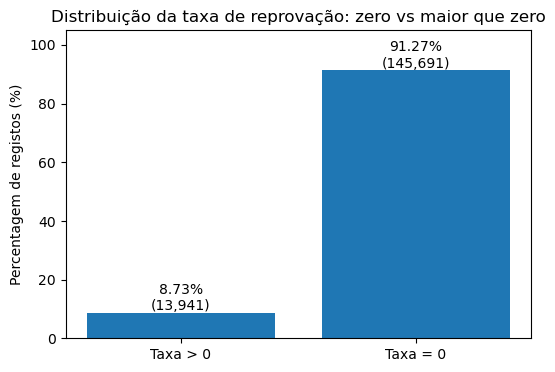

In [58]:
labels = ["Taxa > 0", "Taxa = 0"]
counts = [
    (train_df["taxa_reprovacao"] > 0).sum(),
    (train_df["taxa_reprovacao"] == 0).sum()
]

total = sum(counts)
percentages = [v / total * 100 for v in counts]

plt.figure(figsize=(6,4))
bars = plt.bar(labels, percentages)

plt.title("Distribuição da taxa de reprovação: zero vs maior que zero")
plt.ylabel("Percentagem de registos (%)")

for bar, count, pct in zip(bars, counts, percentages):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{pct:.2f}%\n({count:,})",
        ha="center",
        va="bottom"
    )

plt.ylim(0, max(percentages) * 1.15)
plt.show()

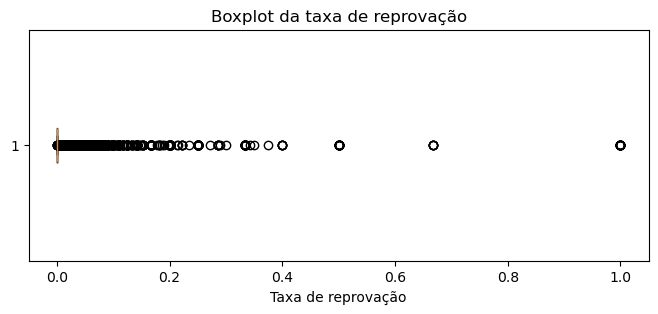

In [59]:
plt.figure(figsize=(8,3))
plt.boxplot(train_df["taxa_reprovacao"], vert=False)
plt.title("Boxplot da taxa de reprovação")
plt.xlabel("Taxa de reprovação")
plt.show()

<p style="font-size:17px; line-height:1.6em; color: #333;">
Da análise dos dois visuais, verifica-se que a variável target, taxa_reprovacao, apresenta uma distribuição fortemente concentrada em zero. Cerca de 91% dos registos têm taxa de reprovação igual a 0, enquanto apenas cerca de 9% apresentam uma taxa superior a 0. O boxplot confirma esta assimetria, mostrando vários valores atípicos, incluindo taxas elevadas próximas de 0.5, 0.65 e 1.0. Estes valores extremos podem corresponder a semanas com um número reduzido de animais abatidos, onde uma pequena quantidade de reprovações resulta numa taxa proporcionalmente elevada. <br>
<p style="font-size:17px; line-height:1.6em; color: #333;">
Dada a elevada concentração dos valores da variável-alvo em torno de zero, optou-se pela aplicação de estratégias alternativas, que serão apresentadas e exemplificadas no capítulo seguinte.


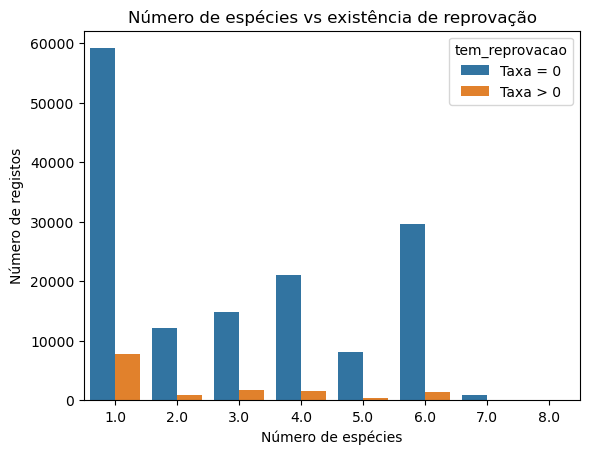

In [60]:
train_df["tem_reprovacao"] = train_df["taxa_reprovacao"].apply(
    lambda x: "Taxa > 0" if x > 0 else "Taxa = 0"
)

sns.countplot(
    data=train_df,
    x="num_species_semana",
    hue="tem_reprovacao"
)

plt.title("Número de espécies vs existência de reprovação")
plt.xlabel("Número de espécies")
plt.ylabel("Número de registos")
plt.show()

<p style="font-size:17px; line-height:1.6em; color: #333;">
A análise dos visuais evidencia um forte desequilíbrio entre registos com e sem reprovação, sendo os casos com taxa igual a zero claramente predominantes em praticamente todos os números de espécies. Observa-se também uma maior frequência de reprovações nos matadouros que abatem apenas uma espécie. Este resultado poderá estar associado a uma maior especialização e rigor no processo de inspeção, embora sejam necessárias análises adicionais para confirmar esta hipótese.

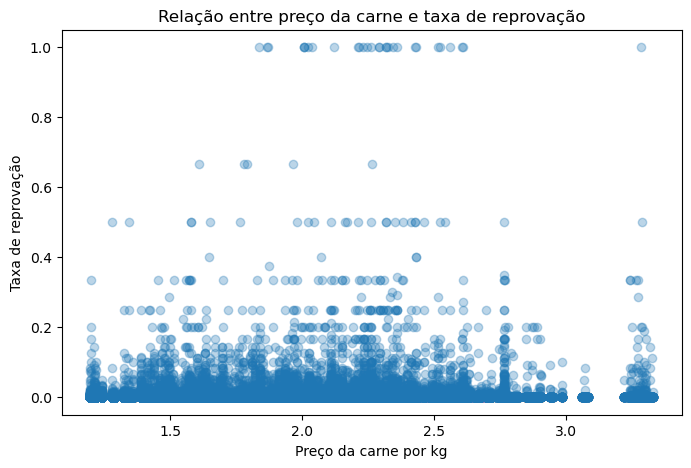

In [61]:
df_plot = train_df.dropna(subset=["preco_kg", "taxa_reprovacao"]).copy()

plt.figure(figsize=(8, 5))
plt.scatter(
    df_plot["preco_kg"],
    df_plot["taxa_reprovacao"],
    alpha=0.3
)

plt.title("Relação entre preço da carne e taxa de reprovação")
plt.xlabel("Preço da carne por kg")
plt.ylabel("Taxa de reprovação")
plt.show()

<p style="font-size:17px; line-height:1.6em; color: #333;">
Relativamente ao preço da carne, não se observa uma relação linear evidente com a taxa de reprovação, uma vez que os valores se encontram bastante dispersos e concentrados próximos de zero em diferentes níveis de preço. Ou seja, a variável preço poderá não ser usada como feature no modelo, uma vez que parece não ser relevante.

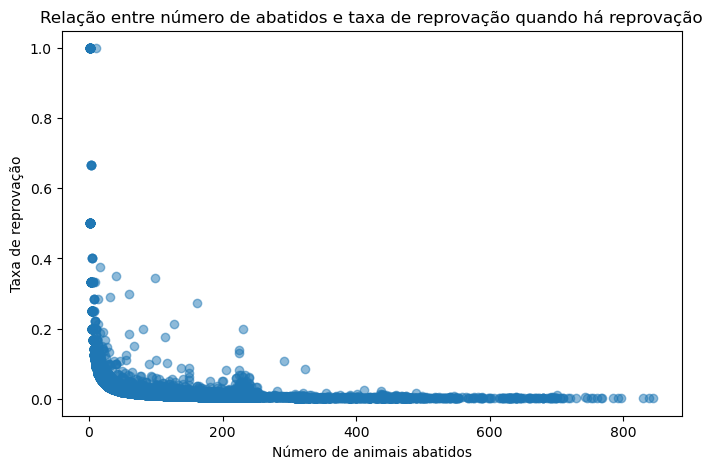

In [62]:
df_pos = df_plot[df_plot["taxa_reprovacao"] > 0].copy()

plt.figure(figsize=(8, 5))
plt.scatter(
    df_pos["abatidos"],
    df_pos["taxa_reprovacao"],
    alpha=0.5
)

plt.title("Relação entre número de abatidos e taxa de reprovação quando há reprovação")
plt.xlabel("Número de animais abatidos")
plt.ylabel("Taxa de reprovação")
plt.show()

<p style="font-size:17px; line-height:1.6em; color: #333;">
No caso do número de animais abatidos, verifica-se uma tendência inversa: taxas de reprovação mais elevadas surgem sobretudo quando o número de abatidos é reduzido, enquanto, à medida que o volume de abates aumenta, a taxa tende a aproximar-se de zero.

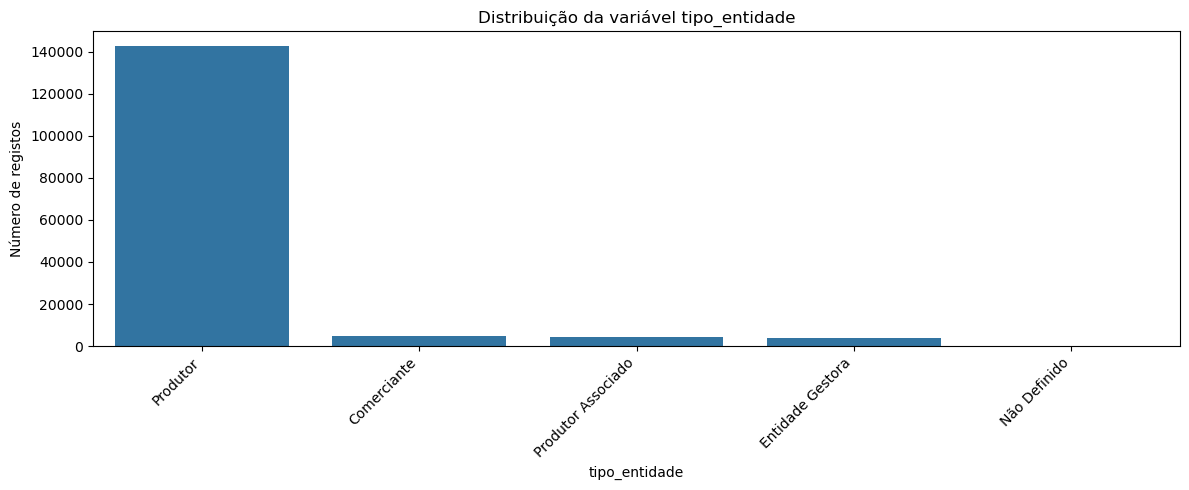

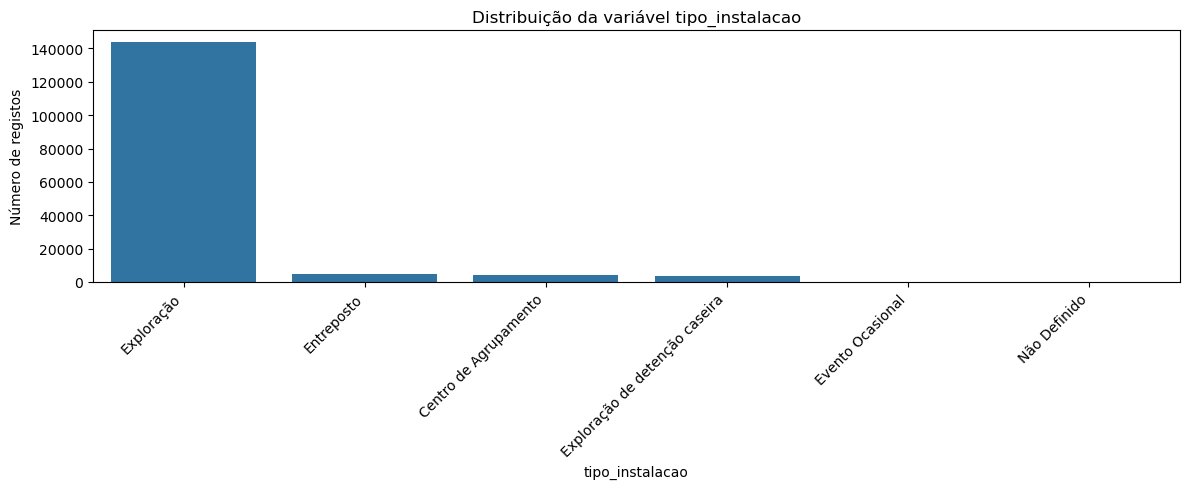

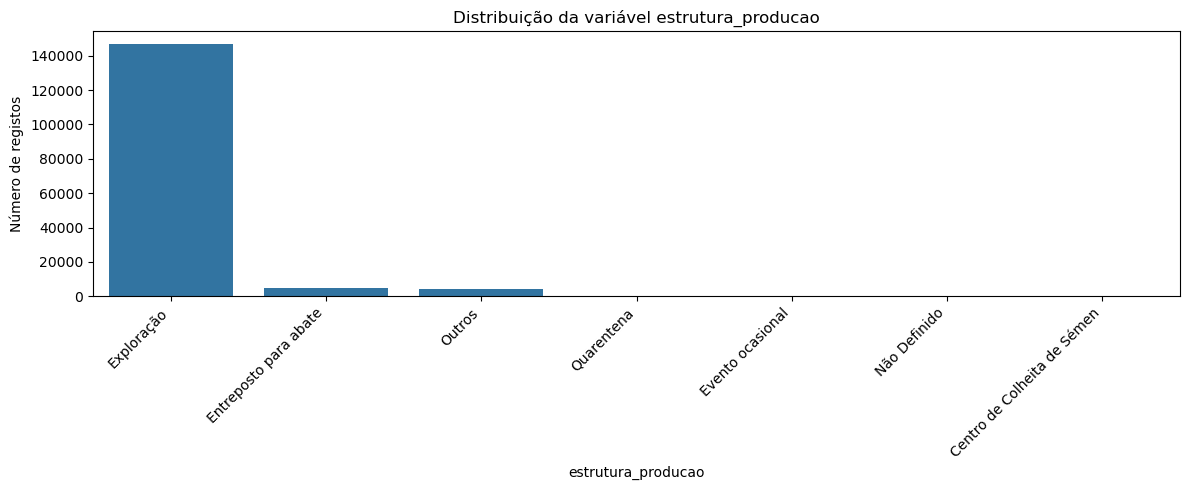

In [63]:
variaveis_cat = ["tipo_entidade", "tipo_instalacao", "estrutura_producao"]

for var in variaveis_cat:
    plt.figure(figsize=(12, 5))
    
    ordem = train_df[var].value_counts().index
    
    sns.countplot(
        data=train_df,
        x=var,
        order=ordem
    )
    
    plt.title(f"Distribuição da variável {var}")
    plt.xlabel(var)
    plt.ylabel("Número de registos")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

<p style="font-size:17px; line-height:1.6em; color: #333;">
Da análise dos três gráficos, conclui-se que as variáveis  <b>tipo de instalação, tipo de entidade e estrutura de produção </b> apresentam reduzida variabilidade, uma vez que os respetivos valores se concentram maioritariamente numa única categoria. Esta baixa dispersão poderá limitar a sua capacidade discriminativa e, consequentemente, indiciar uma menor relevância para o desempenho do modelo.

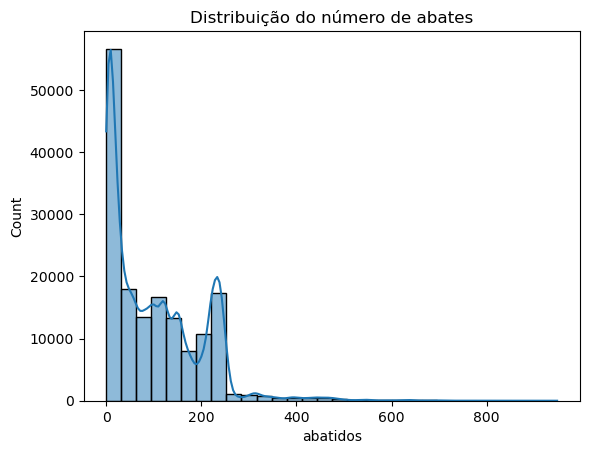

In [64]:
sns.histplot(train_df["abatidos"], bins=30, kde=True)
plt.title("Distribuição do número de abates")
plt.show()

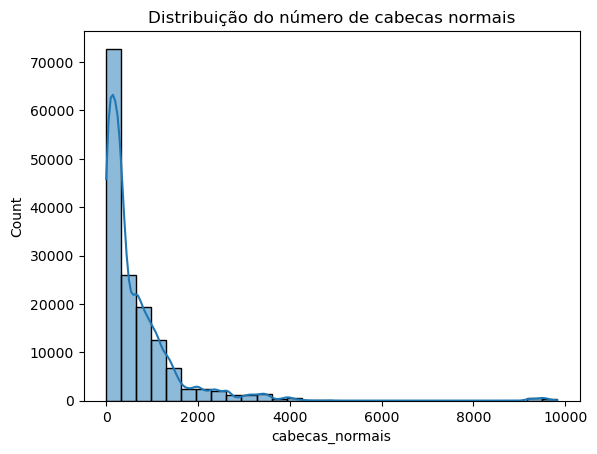

In [65]:
sns.histplot(train_df["cabecas_normais"], bins=30, kde=True)
plt.title("Distribuição do número de cabecas normais")
plt.show()

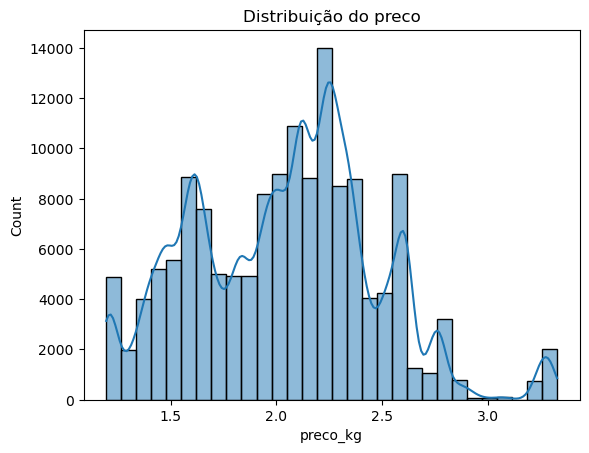

In [66]:
sns.histplot(train_df["preco_kg"], bins=30, kde=True)
plt.title("Distribuição do preco")
plt.show()

<p style="font-size:17px; line-height:1.6em; color: #333;">
A análise visual das distribuições das variáveis <b> abatidos e cabecas_normais </b> evidencia uma <b>forte assimetria à direita</b>, com grande concentração de observações em valores baixos e presença de alguns valores muito elevados. Esta distribuição indica a existência de outliers ou explorações/matadouros com dimensão significativamente superior à maioria dos registos. Assim, para reduzir o impacto destes valores extremos e tornar a distribuição mais estável para os modelos, será considerada a aplicação de uma transformação logarítmica, nomeadamente log(1 + x), às variáveis abatidos e cabecas_normais

# Parte 2 - Data Preprocessing

## 1. Handled Missing Values

In [9]:
# Identify Missing Values (apenas colunas com valores em falta)

missing_summary = pd.DataFrame({
    "n_nulls": train_df.isna().sum(),
    "pct_nulls": train_df.isna().mean() * 100
})

missing_summary = (
    missing_summary[missing_summary["n_nulls"] > 0]
    .sort_values("pct_nulls", ascending=False)
)

print(missing_summary)

                              n_nulls  pct_nulls
valor_por_animais_reprovados    11894   7.450887
valor_por_animais_abatidos      11894   7.450887
valor_estimado_por_suino        11894   7.450887
preco_kg                        11894   7.450887
cabecas_normais                 10049   6.295104
tipo_instalacao                  3936   2.465671
tipo_exploracao_dimensao         3936   2.465671
tipo_exploracao_ciclo            3936   2.465671
tipo_exploracao_extenso          3936   2.465671
tipo_exploracao_codigo           3936   2.465671
sistema_exploracao               3936   2.465671
SK_Geo_Exp                       3936   2.465671
SK_Marca_Historico               3936   2.465671
tipo_entidade                    3936   2.465671
dsavr_exploracao                 3936   2.465671
svl_exploracao                   3936   2.465671
distrito_exploracao              3936   2.465671
concelho_exploracao              3936   2.465671
freguesia_exploracao             3936   2.465671
estrutura_producao  

<p style="font-size:17px; line-height:1.6em; color: #333;">
Optou-se pela remoção dos registos com valores nulos nas chaves substitutas <b>SK_Marca_Historico e SK_Matadouro</b>. Estas chaves estabelecem a ligação entre a tabela de factos fact_controlo_sanitario e as dimensões de exploração e de matadouro, permitindo obter, respetivamente, as características da exploração onde o suíno foi criado e tratado e do matadouro onde foi abatido.
<p style="font-size:17px; line-height:1.6em; color: #333;">
Como estas variáveis dimensionais constituem informação relevante para o modelo de machine learning, a existência de valores nulos nestas chaves indica que não foi possível estabelecer correspondência entre o evento de abate e as respetivas dimensões. Assim, esses registos não permitem recuperar os atributos necessários e foram considerados pouco úteis para a construção do conjunto de dados final.


In [10]:
# Remover linhas com null em SK_Marca_Historico e SK_Matadouro

print("Antes:")
print("Linhas:", len(train_df))
print("Nulls SK_Marca_Historico:", train_df["SK_Marca_Historico"].isna().sum())
print("Nulls SK_Matadouro:", train_df["SK_Matadouro"].isna().sum())

train_df = train_df.dropna(
    subset=[
        "SK_Marca_Historico",
        "SK_Matadouro"
    ]
).copy()

print("\nDepois:")
print("Linhas:", len(train_df))
print("Nulls SK_Marca_Historico:", train_df["SK_Marca_Historico"].isna().sum())
print("Nulls SK_Matadouro:", train_df["SK_Matadouro"].isna().sum())

Antes:
Linhas: 159632
Nulls SK_Marca_Historico: 3936
Nulls SK_Matadouro: 271

Depois:
Linhas: 155427
Nulls SK_Marca_Historico: 0
Nulls SK_Matadouro: 0


<p style="font-size:17px; line-height:1.6em; color: #333;">
Relativamente ao preenchimento dos valores nulos das variáveis <b>preço por quilograma e cabeças normais</b>, este tratamento foi realizado apenas após a divisão dos dados em conjuntos de treino e teste, de modo a evitar a ocorrência de *data leakage*. A estratégia de imputação adotada será apresentada e detalhada numa secção posterior.

In [11]:
# Identify Missing Values (apenas colunas com valores em falta)

missing_summary = pd.DataFrame({
    "n_nulls": train_df.isna().sum(),
    "pct_nulls": train_df.isna().mean() * 100
})

missing_summary = (
    missing_summary[missing_summary["n_nulls"] > 0]
    .sort_values("pct_nulls", ascending=False)
)

print(missing_summary)

                              n_nulls  pct_nulls
preco_kg                         8130   5.230751
valor_estimado_por_suino         8130   5.230751
valor_por_animais_abatidos       8130   5.230751
valor_por_animais_reprovados     8130   5.230751
cabecas_normais                  6113   3.933036
num_species_semana                  7   0.004504
tipo_matadouro_semana               7   0.004504


In [12]:
display(train_df.head(10))

### 2. Handle Duplicates

In [13]:
# Verificar a existência de registos (linhas) duplicados no dataset

print(train_df.duplicated().any())
print(train_df.duplicated().sum())

False
0


### 3. Feature Engineering

<p style="font-size:17px; line-height:1.6em; color: #333;">
Na tabela em análise estão disponíveis duas variáveis geográficas relevantes: a região do matadouro, correspondente à zona onde o animal foi abatido, e a região da exploração, correspondente à zona onde foi produzido e criado. Considerou-se, por isso, pertinente criar uma nova variável que indique se o animal foi abatido na mesma região em que foi produzido. Esta feature poderá permitir ao modelo captar eventuais diferenças associadas à deslocação dos animais entre regiões, incluindo fatores logísticos, características dos circuitos de abate e possíveis especificidades regionais suscetíveis de influenciar a taxa de reprovação para consumo humano.

In [14]:
#Criação de feature relacionada com nível de proximidade entre zona da exploração animal e da zona onde o animal foi abatido

df_calculado = train_df.copy()

# mesma DSAVR
df_calculado["mesma_dsavr_matadouro_exploracao"] = np.where(
    df_calculado["dsavr_matadouro"].isna() | df_calculado["dsavr_exploracao"].isna(),
    np.nan,
    np.where(
        df_calculado["dsavr_matadouro"] == df_calculado["dsavr_exploracao"],
        1,
        0
    )
)

# mesmo SVL
df_calculado["mesmo_svl_matadouro_exploracao"] = np.where(
    df_calculado["svl_matadouro"].isna() | df_calculado["svl_exploracao"].isna(),
    np.nan,
    np.where(
        df_calculado["svl_matadouro"] == df_calculado["svl_exploracao"],
        1,
        0
    )
)

# nível de proximidade
df_calculado["nivel_proximidade_abate_exploracao"] = np.select(
    [
        df_calculado["dsavr_matadouro"].isna() | df_calculado["dsavr_exploracao"].isna(),
        df_calculado["svl_matadouro"] == df_calculado["svl_exploracao"],
        df_calculado["dsavr_matadouro"] == df_calculado["dsavr_exploracao"]
    ],
    [
        "desconhecido",
        "mesmo_svl",
        "mesma_dsavr"
    ],
    default="regiao_diferente"
)

# visualizar só as colunas relevantes
df_proximidade = df_calculado[
    [
        "dsavr_matadouro",
        "dsavr_exploracao",
        "svl_matadouro",
        "svl_exploracao",
        "mesma_dsavr_matadouro_exploracao",
        "mesmo_svl_matadouro_exploracao",
        "nivel_proximidade_abate_exploracao"
    ]
]

df_proximidade.head(20)

df_calculado = df_calculado.drop(columns=["tem_reprovacao"], errors="ignore")
train_df = df_calculado.copy()

In [15]:
train_df.head(10)

,data,ano,mes,semana,diasemana,marca,ncv,SK_Marca_Historico,SK_Geo_Exp,SK_Matadouro,SK_Geo_Mat,svl_matadouro,dsavr_matadouro,freguesia_exploracao,concelho_exploracao,distrito_exploracao,svl_exploracao,dsavr_exploracao,tipo_entidade,tipo_instalacao,estrutura_producao,sistema_exploracao,tipo_exploracao_codigo,tipo_exploracao_extenso,tipo_exploracao_ciclo,tipo_exploracao_dimensao,cabecas_normais,abatidos,reprovados,taxa_reprovacao,num_species_semana,tipo_matadouro_semana,preco_kg,valor_estimado_por_suino,valor_por_animais_abatidos,valor_por_animais_reprovados,meta_source_file,meta_source_file_date,audit_ml_refresh_timestamp,mesma_dsavr_matadouro_exploracao,mesmo_svl_matadouro_exploracao,nivel_proximidade_abate_exploracao
0,2022-05-11,2022,5,19,quarta,PT9A14V,A93,SK_PT9A14V_20220401,SK_GEO_ad85005345bcd6ee42e817225d29224a,SK_Mat_A 93,SK_GEO_MAT_9b4bcddad1ae83f032f5d90d24c88d1f,SDA Santa Maria,Açores,Almagreira,Vila do Porto,Ilha de Santa Maria,SDA Sta. Maria,Açores,Produtor,Exploração,Exploração,Extensivo,FC,Familiar - Ciclo Completo,Familiar,Ciclo Completo,26.74,16.0,0.0,0.0,5.0,multiespecie,NaN,NaN,NaN,NaN,Registo de pesquisa de Trichinella 2021-2024_2024_12_11.xlsx,2024-12-11,2026-06-03 17:05:28.127905+00:00,1.0,0.0,mesma_dsavr
1,2022-06-29,2022,6,26,quarta,PT9A14V,A93,SK_PT9A14V_20220401,SK_GEO_ad85005345bcd6ee42e817225d29224a,SK_Mat_A 93,SK_GEO_MAT_9b4bcddad1ae83f032f5d90d24c88d1f,SDA Santa Maria,Açores,Almagreira,Vila do Porto,Ilha de Santa Maria,SDA Sta. Maria,Açores,Produtor,Exploração,Exploração,Extensivo,FC,Familiar - Ciclo Completo,Familiar,Ciclo Completo,26.74,5.0,0.0,0.0,4.0,multiespecie,NaN,NaN,NaN,NaN,Registo de pesquisa de Trichinella 2021-2024_2024_12_11.xlsx,2024-12-11,2026-06-03 17:05:28.127905+00:00,1.0,0.0,mesma_dsavr
2,2022-07-12,2022,7,28,terça,PT9A14V,A93,SK_PT9A14V_20220401,SK_GEO_ad85005345bcd6ee42e817225d29224a,SK_Mat_A 93,SK_GEO_MAT_9b4bcddad1ae83f032f5d90d24c88d1f,SDA Santa Maria,Açores,Almagreira,Vila do Porto,Ilha de Santa Maria,SDA Sta. Maria,Açores,Produtor,Exploração,Exploração,Extensivo,FC,Familiar - Ciclo Completo,Familiar,Ciclo Completo,26.74,6.0,0.0,0.0,4.0,multiespecie,NaN,NaN,NaN,NaN,Registo de pesquisa de Trichinella 2021-2024_2024_12_11.xlsx,2024-12-11,2026-06-03 17:05:28.127905+00:00,1.0,0.0,mesma_dsavr
3,2022-07-27,2022,7,30,quarta,PT9A14V,A93,SK_PT9A14V_20220401,SK_GEO_ad85005345bcd6ee42e817225d29224a,SK_Mat_A 93,SK_GEO_MAT_9b4bcddad1ae83f032f5d90d24c88d1f,SDA Santa Maria,Açores,Almagreira,Vila do Porto,Ilha de Santa Maria,SDA Sta. Maria,Açores,Produtor,Exploração,Exploração,Extensivo,FC,Familiar - Ciclo Completo,Familiar,Ciclo Completo,26.74,8.0,0.0,0.0,4.0,multiespecie,NaN,NaN,NaN,NaN,Registo de pesquisa de Trichinella 2021-2024_2024_12_11.xlsx,2024-12-11,2026-06-03 17:05:28.127905+00:00,1.0,0.0,mesma_dsavr
4,2022-06-14,2022,6,24,terça,PT9A14V,A93,SK_PT9A14V_20220401,SK_GEO_ad85005345bcd6ee42e817225d29224a,SK_Mat_A 93,SK_GEO_MAT_9b4bcddad1ae83f032f5d90d24c88d1f,SDA Santa Maria,Açores,Almagreira,Vila do Porto,Ilha de Santa Maria,SDA Sta. Maria,Açores,Produtor,Exploração,Exploração,Extensivo,FC,Familiar - Ciclo Completo,Familiar,Ciclo Completo,26.74,6.0,0.0,0.0,6.0,multiespecie,NaN,NaN,NaN,NaN,Registo de pesquisa de Trichinella 2021-2024_2024_12_11.xlsx,2024-12-11,2026-06-03 17:05:28.127905+00:00,1.0,0.0,mesma_dsavr
5,2022-07-06,2022,7,27,quarta,PT9A14V,A93,SK_PT9A14V_20220401,SK_GEO_ad85005345bcd6ee42e817225d29224a,SK_Mat_A 93,SK_GEO_MAT_9b4bcddad1ae83f032f5d90d24c88d1f,SDA Santa Maria,Açores,Almagreira,Vila do Porto,Ilha de Santa Maria,SDA Sta. Maria,Açores,Produtor,Exploração,Exploração,Extensivo,FC,Familiar - Ciclo Completo,Familiar,Ciclo Completo,26.74,8.0,0.0,0.0,4.0,multiespecie,NaN,NaN,NaN,NaN,Registo de pesquisa de Trichinella 2021-2024_2024_12_11.xlsx,2024-12-11,2026-06-03 17:05:28.127905+00:00,1.0,0.0,mesma_dsavr
6,2022-07-20,2022,7,29,quarta,PT9A14V,A93,SK_PT9A14V_20220401,SK_GEO_ad85005345bcd6ee42e817225d29224a,SK_Mat_A 93,SK_GEO_MAT_9b4bcddad1ae83f032f5d90d24c88d1f,SDA San

### 4. Removal columns from dataset

<p style="font-size:17px; line-height:1.6em; color: #333;">
Na fase de análise exploratória do dataset, verificou-se que este era composto por 39 variáveis, sendo uma delas a variável-alvo do modelo, <b>taxa_reprovacao</b>. Esta variável representa o objetivo da previsão e deverá ser posteriormente definida como a <b>label</b>, ou seja, como y, no momento da divisão dos dados em treino e teste.
<p style="font-size:17px; line-height:1.6em; color: #333;">
No entanto, foram identificadas outras variáveis que dependem diretamente da variável-alvo ou que revelam informação posterior ao evento de reprovação. Por esse motivo, não devem ser consideradas features, uma vez que poderiam introduzir data leakage, fornecendo ao modelo informação direta sobre a existência de animais reprovados numa determinada semana. Estas variáveis incluem <b>reprovados e valor_por_animais_reprovados</b>. NOTA: Como num passo seguinte do trabalho tivemos de recalcular a taxa_reprovacao, devido a group by por outro intervalo temporal como semanal e mensal, esta variável foi removida num passo posterior.
<p style="font-size:17px; line-height:1.6em; color: #333;">
Adicionalmente, as colunas de auditoria meta_source_file, <b>meta_source_file_date e audit_ml_refresh_timestamp</b> foram consideradas irrelevantes para o processo de modelação, uma vez que apenas descrevem a origem e o momento de atualização dos dados, não contribuindo diretamente para a explicação da taxa de reprovação.
<p style="font-size:17px; line-height:1.6em; color: #333;">
Visto que algumas variáveis do dataset foram construídas a partir de outras, é necessário avaliar possíveis redundâncias antes da modelação. Neste caso, as variáveis tipo_exploracao_ciclo e tipo_exploracao_dimensao derivam da variável <b>tipo_exploracao_extenso</b>, pelo que esta última deixa de acrescentar informação adicional relevante ao modelo. Da mesma forma, a variável <b>tipo_exploracao_codigo</b> representa uma codificação da mesma informação de base, tornando-se também redundante. Assim, para reduzir repetição de informação e simplificar o conjunto de features, as colunas tipo_exploracao_extenso e tipo_exploracao_codigo serão eliminadas do dataset utilizado para Machine Learning.
<p style="font-size:17px; line-height:1.6em; color: #333;">
O mesmo acontece com as variáveis adicionadas anteriormente, ou seja, a variável nivel_proximidade_abate_exploracao deriva diretamente das variáveis <b>mesma_dsavr_matadouro_exploracao e mesmo_svl_matadouro_exploracao</b>. Visto que a primeira variavel mencionada apresenta mais valor para o modelo, as outras variáveis devem ser removidas.
<p style="font-size:17px; line-height:1.6em; color: #333;">       
As variáveis valor_estimado_por_suino<b> e valor_por_animais_abatidos</b> foram criadas com o objetivo de apoiar a análise descritiva no relatório e no dashboard do projeto, permitindo quantificar valores económicos associados aos animais abatidos. No entanto, para o modelo de Machine Learning, estas variáveis não são relevantes para o objetivo principal, que consiste em prever a taxa_reprovacao. Além disso, estas colunas representam informação derivada de outras variáveis, como o preco_kg e o número de animais abatidos, podendo introduzir redundância no conjunto de features. Por esse motivo, optou-se por removê-las do dataset utilizado para a modelação.
<p style="font-size:17px; line-height:1.6em; color: #333;">
Por fim, as variáveis correspondentes às surrogate keys, nomeadamente <b>SK_Marca_Historico, SK_Geo_Exp, SK_Matadouro e SK_Geo_Mat</b>, também serão excluídas. Estas chaves foram úteis na construção e integração da tabela, mas não representam informação explicativa relevante para o modelo de Machine Learning. Assim, após as transformações necessárias, estas variáveis serão removidas do dataset utilizado para treino e avaliação do modelo.


In [16]:
# Colunas a remover do dataset antes da modelação
cols_to_drop = [
    # "reprovados",
    "valor_por_animais_reprovados",

    "meta_source_file",
    "meta_source_file_date",
    "audit_ml_refresh_timestamp",

    "tipo_exploracao_codigo",
    "tipo_exploracao_extenso",

    "valor_estimado_por_suino",
    "valor_por_animais_abatidos",

    "SK_Marca_Historico",
    "SK_Geo_Exp",
    "SK_Matadouro",
    "SK_Geo_Mat",

    "mesma_dsavr_matadouro_exploracao",
    "mesmo_svl_matadouro_exploracao"

]

# Remover apenas as colunas que existem no dataframe
cols_to_drop_existing = [col for col in cols_to_drop if col in train_df.columns]

train_df = train_df.drop(columns=cols_to_drop_existing)


print("Colunas removidas:")
print(cols_to_drop_existing)

print("Shape original:", train_df.shape)
print("Shape após remoção:", train_df.shape)

Colunas removidas:
['valor_por_animais_reprovados', 'meta_source_file', 'meta_source_file_date', 'audit_ml_refresh_timestamp', 'tipo_exploracao_codigo', 'tipo_exploracao_extenso', 'valor_estimado_por_suino', 'valor_por_animais_abatidos', 'SK_Marca_Historico', 'SK_Geo_Exp', 'SK_Matadouro', 'SK_Geo_Mat', 'mesma_dsavr_matadouro_exploracao', 'mesmo_svl_matadouro_exploracao']
Shape original: (155427, 28)
Shape após remoção: (155427, 28)


### 5. Estratégias de Modelação para Variável-Alvo com Excesso de Zeros

<p style="font-size:17px; line-height:1.6em; color: #333;">
Apesar de o conjunto de dados conter cerca de 150 000 registos, a variável-alvo apresenta uma elevada concentração de valores iguais a zero quando analisada à granularidade diária. Neste contexto, considerou-se pertinente testar agregações semanais e mensais, com o objetivo de reduzir o ruído associado às flutuações diárias e obter uma taxa de reprovação mais estável, mantendo simultaneamente um volume de observações suficiente para o treino e a avaliação dos modelos.
<p style="font-size:17px; line-height:1.6em; color: #333;">
Para a construção dos conjuntos de dados agregados, serão aplicadas as seguintes regras:

* <b>Animais abatidos:</b> soma do número de animais abatidos no período;
* <b>Animais reprovados:</b> soma do número de animais reprovados no período;
* <b>Taxa de reprovação:</b> recálculo com base nos valores agregados, através da expressão
  soma dos reprovados / soma dos abatidos;
* <b>Número de espécies:</b> recalculou-se o valor por mês/semana
* <b>Tipo de matadouro:</b> classificação como multiespécie dependendo do número de especies no intervalo considerado
* <b>Preço por quilograma:</b> média do preço observada por região e período;
* <b>Cabeças normais:</b> mediana associada à exploração ou marca;
* <b>Dia da semana:</b> remoção da variável, uma vez que deixa de ser diretamente aplicável após a agregação semanal ou mensal.
<p style="font-size:17px; line-height:1.6em; color: #333;">
Estas transformações permitem preservar as principais características operacionais e económicas dos dados, ajustando-as à nova granularidade temporal.


In [17]:
#Agrupamento dos dados à semana 

df = train_df.copy()

# Garantir tipos numéricos

cols_num = [
    "abatidos",
    "taxa_reprovacao",
    "num_species",
    "preco_kg",
    "cabecas_normais",
    "reprovados"
]

for col in cols_num:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

if "reprovados" not in df.columns:
    df["reprovados"] = df["taxa_reprovacao"] * df["abatidos"]

df["reprovados"] = pd.to_numeric(df["reprovados"], errors="coerce")



# Funções auxiliares


def moda_sem_null(s):
    s = s.dropna()
    if s.empty:
        return np.nan
    return s.mode().iloc[0]


def agrega_tipo_matadouro(s):
    s = s.dropna().astype(str).str.lower()
    if s.empty:
        return np.nan
    if "multiespecie" in s.values:
        return "multiespecie"
    return "uniespecie"



# 1. Dataset base semanal
# nível: ano + semana + marca + ncv

cols_base = [
    "ano",
    "semana",
    "marca",
    "ncv"
]

agg_base = {
    "data": "min",

    # Factos
    "abatidos": "sum",
    "reprovados": "sum",

    # Matadouro já está ao nível semanal
    "num_species": "max",
    "tipo_matadouro": agrega_tipo_matadouro,

    # Região do matadouro para conseguir juntar preço regional
    "dsavr_matadouro": moda_sem_null,

    # Atributos que quiseres manter
    "svl_matadouro": moda_sem_null,
    "svl_exploracao": moda_sem_null,
    "dsavr_exploracao": moda_sem_null,
    "tipo_entidade": moda_sem_null,
    "tipo_instalacao": moda_sem_null,
    "estrutura_producao": moda_sem_null,
    "sistema_exploracao": moda_sem_null,
    "tipo_exploracao_ciclo": moda_sem_null,
    "tipo_exploracao_dimensao": moda_sem_null
}

agg_base = {
    col: func for col, func in agg_base.items()
    if col in df.columns
}

df_model_semanal = (
    df
    .groupby(cols_base, as_index=False)
    .agg(agg_base)
)

df_model_semanal["taxa_reprovacao"] = np.where(
    df_model_semanal["abatidos"] > 0,
    df_model_semanal["reprovados"] / df_model_semanal["abatidos"],
    0
)



# 2. Preço médio por região do matadouro à semana
# nível: ano + semana + dsavr_matadouro


df_preco_semana_regiao = (
    df
    .groupby(
        ["ano", "semana", "dsavr_matadouro"],
        as_index=False
    )
    .agg(
        preco_kg=("preco_kg", "mean")
    )
)

df_model_semanal = df_model_semanal.drop(
    columns=["preco_kg"],
    errors="ignore"
).merge(
    df_preco_semana_regiao,
    on=["ano", "semana", "dsavr_matadouro"],
    how="left"
)



# 3. Cabeças normais por exploração/marca à semana
# nível: ano + semana + marca


df_cabecas_semana_marca = (
    df
    .groupby(
        ["ano", "semana", "marca"],
        as_index=False
    )
    .agg(
        cabecas_normais=("cabecas_normais", "median")
    )
)

df_model_semanal = df_model_semanal.drop(
    columns=["cabecas_normais"],
    errors="ignore"
).merge(
    df_cabecas_semana_marca,
    on=["ano", "semana", "marca"],
    how="left"
)



# Resultado

df_model_semanal.head(10)

,ano,semana,marca,ncv,data,abatidos,reprovados,dsavr_matadouro,svl_matadouro,svl_exploracao,dsavr_exploracao,tipo_entidade,tipo_instalacao,estrutura_producao,sistema_exploracao,tipo_exploracao_ciclo,tipo_exploracao_dimensao,taxa_reprovacao,preco_kg,cabecas_normais
0,2020,1,PT90D1V,A88,2020-01-02,2.0,0.0,Açores,SDA S. Miguel,SDA S. Miguel,Açores,Produtor,Exploração,Exploração,Intensivo,Industrial,Ciclo Completo,0.000000,NaN,168.85
1,2020,1,PT9D01A,A88,2020-01-02,3.0,0.0,Açores,SDA S. Miguel,SDA S. Miguel,Açores,Produtor,Exploração,Exploração,Não Definido,Não Definido,Não Definido,0.000000,NaN,NaN
2,2020,1,PT9D16A,A88,2020-01-02,6.0,1.0,Açores,SDA S. Miguel,SDA S. Miguel,Açores,Produtor,Exploração,Exploração,Intensivo,Industrial,Ciclo Completo,0.166667,NaN,669.76
3,2020,1,PT9F06A,A88,2020-01-02,53.0,0.0,Açores,SDA S. Miguel,SDA S. Miguel,Açores,Produtor,Exploração,Exploração,Intensivo,Industrial,Ciclo Completo,0.000000,NaN,3931.38
4,2020,1,PT9F06A,A89,2020-01-02,40.0,0.0,Açores,SDA Terceira,SDA S. Miguel,Açores,Produtor,Exploração,Exploração,Intensivo,Industrial,Ciclo Completo,0.000000,NaN,3931.38
5,2020,1,PT9F60V,A88,2020-01-02,176.0,0.0,Açores,SDA S. Miguel,SDA S. Miguel,Açores,Produtor,Exploração,Exploração,Intensivo,Industrial,Recria e Acabamento,0.000000,NaN,1125.00
6,2020,1,PT9F61V,A88,2020-01-02,40.0,0.0,Açores,SDA S. Miguel,SDA S. Miguel,Açores,Produtor,Exploração,Exploração,Intensivo,Industrial,Ciclo Completo,0.000000,NaN,624.12
7,2020,1,PT9F61V,A89,2020-01-02,25.0,0.0,Açores,SDA Terceira,SDA S. Miguel,Açores,Produtor,Exploração,Exploração,Intensivo,Industrial,Ciclo Completo,0.000000,NaN,624.12
8,2020,1,PT9H02A,A89,2020-01-02,19.0,0.0,Açores,SDA Terceira,SDA Terceira,Açores,Produtor,Exploração,Exploração,Intensivo,Industrial,Ciclo Completo,0.000000,NaN,415.21
9,2020,1,PT9I02A,A89,2020-01-02,41.0,0.0,Açores,SDA Terceira,SDA Terceira,Açores,Produtor,Exploração,Exploração,Intensivo,Industrial,Ciclo Completo,0.000000,NaN,592.33


<p style="font-size:17px; line-height:1.6em; color: #333;">
De seguida analisou-se de novo a distribuição dos dados da variável alvo para verficar se houve melhoria

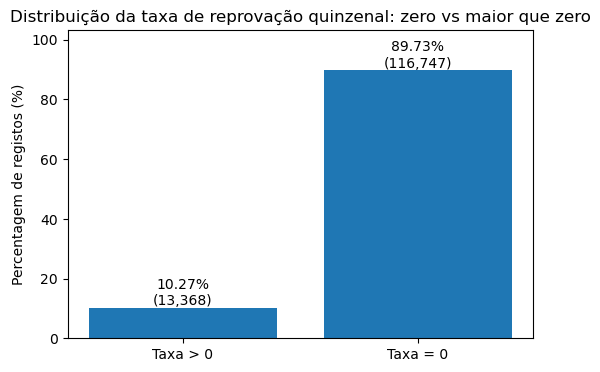

In [18]:
labels = ["Taxa > 0", "Taxa = 0"]
counts = [
    (df_model_semanal["taxa_reprovacao"] > 0).sum(),
    (df_model_semanal["taxa_reprovacao"] == 0).sum()
]

total = sum(counts)
percentages = [v / total * 100 for v in counts]

plt.figure(figsize=(6,4))
bars = plt.bar(labels, percentages)

plt.title("Distribuição da taxa de reprovação quinzenal: zero vs maior que zero")
plt.ylabel("Percentagem de registos (%)")

for bar, count, pct in zip(bars, counts, percentages):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{pct:.2f}%\n({count:,})",
        ha="center",
        va="bottom"
    )

plt.ylim(0, max(percentages) * 1.15)
plt.show()

<p style="font-size:17px; line-height:1.6em; color: #333;">
Ao comparar o conjunto de dados original com o conjunto agregado semanalmente, verificou-se que a proporção de registos com <b>taxa de reprovação</b> superior a zero aumentou de <b>8% para 10%</b>. Embora este resultado represente uma melhoria, o desequilíbrio da variável-alvo continua a ser elevado e poderá comprometer o desempenho do modelo. Numa fase seguinte, será testada uma agregação mensal, de forma a avaliar se esta abordagem permite aumentar a proporção de observações com taxa de reprovação superior a zero e reduzir o desequilíbrio face ao conjunto semanal.

In [19]:
# Contagem e percentagem de nulls por coluna no dataframe semanal

total_rows = len(df_model_semanal)

nulls_semanal = pd.DataFrame({
    "n_nulls": df_model_semanal.isna().sum(),
    "pct_nulls": (df_model_semanal.isna().sum() / total_rows * 100).round(2)
})

nulls_semanal = (
    nulls_semanal
    .sort_values("pct_nulls", ascending=False)
)

print("Número total de linhas do dataframe semanal:", total_rows)

nulls_semanal

Número total de linhas do dataframe semanal: 130115


,n_nulls,pct_nulls
preco_kg,5884,4.52
cabecas_normais,3476,2.67
semana,0,0.00
taxa_reprovacao,0,0.00
tipo_exploracao_dimensao,0,0.00
tipo_exploracao_ciclo,0,0.00
sistema_exploracao,0,0.00
estrutura_producao,0,0.00
tipo_instalacao,0,0.00
tipo_entidade,0,0.00


<p style="font-size:17px; line-height:1.6em; color: #333;">
Para adaptar a análise à granularidade mensal, foi necessário reconstruir a tabela de trabalho, passando a designá-la por Taxa_Reprovacao_ML. Esta nova tabela foi obtida através de um novo join com a tabela abatesdiarios_silver, que contém a informação descritiva dos matadouros.
<p style="font-size:17px; line-height:1.6em; color: #333;">
Ao contrário da abordagem semanal anteriormente utilizada, os atributos <b>num_species e tipo_matadouro</b> passaram a ser calculados com base no conjunto de abates ocorridos em cada mês. Assim, a classificação do matadouro e o número de espécies refletem agora a atividade mensal, e não apenas a atividade observada numa determinada semana. Para garantir esta correspondência temporal, o <b>join</b> foi novamente realizado ao nível do mês.
<p style="font-size:17px; line-height:1.6em; color: #333;">
Relativamente aos atributos da exploração e ao preço da carne, estes foram obtidos diretamente a partir da fact_controlo_sanitario. Como a tabela ML_Taxa_Reprovacao manteve a granularidade diária, foi possível efetuar posteriormente a respetiva agregação mensal através de um group by.


In [20]:
# Código para leitura do ficheiro

dt = DeltaTable("/lakehouse/default/Tables/ml/Taxa_Reprovacao_ML")
train_df2 = dt.to_pandas()

pd.set_option("display.max_columns", None)      # mostra todas as colunas
pd.set_option("display.max_colwidth", None)     # mostra texto completo nas células
pd.set_option("display.width", None)            # não limita largura
pd.set_option("display.expand_frame_repr", False)

train_df2.head(10)

[2026-06-20T09:32:25Z WARN  delta_kernel::listed_log_files] Found file 00000000000000000000.parquet with unknown file type Unknown at version 0
[2026-06-20T09:32:25Z WARN  delta_kernel::listed_log_files] Found file 00000000000000000001.parquet with unknown file type Unknown at version 1


,data,ano,mes,semana,diasemana,marca,ncv,SK_Marca_Historico,SK_Geo_Exp,SK_Matadouro,SK_Geo_Mat,svl_matadouro,dsavr_matadouro,freguesia_exploracao,concelho_exploracao,distrito_exploracao,svl_exploracao,dsavr_exploracao,tipo_entidade,tipo_instalacao,estrutura_producao,sistema_exploracao,tipo_exploracao_codigo,tipo_exploracao_extenso,tipo_exploracao_ciclo,tipo_exploracao_dimensao,cabecas_normais,abatidos,reprovados,taxa_reprovacao,num_species_mes,tipo_matadouro_mes,preco_kg,valor_estimado_por_suino,valor_por_animais_abatidos,valor_por_animais_reprovados,meta_source_file,meta_source_file_date,audit_ml_refresh_timestamp
0,2022-05-11,2022,5,19,quarta,PT9A14V,A93,SK_PT9A14V_20220401,SK_GEO_ad85005345bcd6ee42e817225d29224a,SK_Mat_A 93,SK_GEO_MAT_9b4bcddad1ae83f032f5d90d24c88d1f,SDA Santa Maria,Açores,Almagreira,Vila do Porto,Ilha de Santa Maria,SDA Sta. Maria,Açores,Produtor,Exploração,Exploração,Extensivo,FC,Familiar - Ciclo Completo,Familiar,Ciclo Completo,26.74,16.0,0.0,0.0,6.0,multiespecie,NaN,NaN,NaN,NaN,Registo de pesquisa de Trichinella 2021-2024_2024_12_11.xlsx,2024-12-11,2026-06-03 18:31:42.779214+00:00
1,2022-06-29,2022,6,26,quarta,PT9A14V,A93,SK_PT9A14V_20220401,SK_GEO_ad85005345bcd6ee42e817225d29224a,SK_Mat_A 93,SK_GEO_MAT_9b4bcddad1ae83f032f5d90d24c88d1f,SDA Santa Maria,Açores,Almagreira,Vila do Porto,Ilha de Santa Maria,SDA Sta. Maria,Açores,Produtor,Exploração,Exploração,Extensivo,FC,Familiar - Ciclo Completo,Familiar,Ciclo Completo,26.74,5.0,0.0,0.0,6.0,multiespecie,NaN,NaN,NaN,NaN,Registo de pesquisa de Trichinella 2021-2024_2024_12_11.xlsx,2024-12-11,2026-06-03 18:31:42.779214+00:00
2,2022-07-12,2022,7,28,terça,PT9A14V,A93,SK_PT9A14V_20220401,SK_GEO_ad85005345bcd6ee42e817225d29224a,SK_Mat_A 93,SK_GEO_MAT_9b4bcddad1ae83f032f5d90d24c88d1f,SDA Santa Maria,Açores,Almagreira,Vila do Porto,Ilha de Santa Maria,SDA Sta. Maria,Açores,Produtor,Exploração,Exploração,Extensivo,FC,Familiar - Ciclo Completo,Familiar,Ciclo Completo,26.74,6.0,0.0,0.0,6.0,multiespecie,NaN,NaN,NaN,NaN,Registo de pesquisa de Trichinella 2021-2024_2024_12_11.xlsx,2024-12-11,2026-06-03 18:31:42.779214+00:00
3,2022-07-27,2022,7,30,quarta,PT9A14V,A93,SK_PT9A14V_20220401,SK_GEO_ad85005345bcd6ee42e817225d29224a,SK_Mat_A 93,SK_GEO_MAT_9b4bcddad1ae83f032f5d90d24c88d1f,SDA Santa Maria,Açores,Almagreira,Vila do Porto,Ilha de Santa Maria,SDA Sta. Maria,Açores,Produtor,Exploração,Exploração,Extensivo,FC,Familiar - Ciclo Completo,Familiar,Ciclo Completo,26.74,8.0,0.0,0.0,6.0,multiespecie,NaN,NaN,NaN,NaN,Registo de pesquisa de Trichinella 2021-2024_2024_12_11.xlsx,2024-12-11,2026-06-03 18:31:42.779214+00:00
4,2022-06-14,2022,6,24,terça,PT9A14V,A93,SK_PT9A14V_20220401,SK_GEO_ad85005345bcd6ee42e817225d29224a,SK_Mat_A 93,SK_GEO_MAT_9b4bcddad1ae83f032f5d90d24c88d1f,SDA Santa Maria,Açores,Almagreira,Vila do Porto,Ilha de Santa Maria,SDA Sta. Maria,Açores,Produtor,Exploração,Exploração,Extensivo,FC,Familiar - Ciclo Completo,Familiar,Ciclo Completo,26.74,6.0,0.0,0.0,6.0,multiespecie,NaN,NaN,NaN,NaN,Registo de pesquisa de Trichinella 2021-2024_2024_12_11.xlsx,2024-12-11,2026-06-03 18:31:42.779214+00:00
5,2022-07-06,2022,7,27,quarta,PT9A14V,A93,SK_PT9A14V_20220401,SK_GEO_ad85005345bcd6ee42e817225d29224a,SK_Mat_A 93,SK_GEO_MAT_9b4bcddad1ae83f032f5d90d24c88d1f,SDA Santa Maria,Açores,Almagreira,Vila do Porto,Ilha de Santa Maria,SDA Sta. Maria,Açores,Produtor,Exploração,Exploração,Extensivo,FC,Familiar - Ciclo Completo,Familiar,Ciclo Completo,26.74,8.0,0.0,0.0,6.0,multiespecie,NaN,NaN,NaN,NaN,Registo de pesquisa de Trichinella 2021-2024_2024_12_11.xlsx,2024-12-11,2026-06-03 18:31:42.779214+00:00
6,2022-07-20,2022,7,29,quarta,PT9A14V,A93,SK_PT9A14V_20220401,SK_GEO_ad85005345bcd6ee42e817225d29224a,SK_Mat_A 93,SK_GEO_MAT_9b4bcddad1ae83f032f5d90d24c88d1f,SDA Santa Maria,Açores,Almagreira,Vila do Porto,Ilha de Santa Maria,SDA Sta. Maria,Açores,Produtor,Exploração,Exploração,Extensivo,FC,Familiar - Ciclo Completo,Familiar,Ciclo Completo,26.74,10.0,0.0,0.0,6.0,multiespecie,NaN,NaN,NaN,

<p style="font-size:17px; line-height:1.6em; color: #333;">
De seguida fez-se as alterações à nova tabela iguais às que foram feitas à tabela original. Removeram-se os nulls das SK_Marca_Historico e SK_Matadouro; criou-se novas features relativas ao nivel de proximidade entre o local da exploração do animal e o local de abate; removeram-se colunas que não são úteis para o treino do modelo.

In [21]:

# PREPARAÇÃO DO DATASET DE TREINO PARA MODELAÇÃO
# 1. Remover nulls em SK_Marca_Historico e SK_Matadouro
# 2. Criar features de proximidade exploração-matadouro
# 3. Remover colunas não usadas no treino


train_df2 = train_df2.copy()

print("ANTES DA REMOÇÃO DE NULLS")
print("Linhas:", len(train_df2))
print("Nulls SK_Marca_Historico:", train_df2["SK_Marca_Historico"].isna().sum())
print("Nulls SK_Matadouro:", train_df2["SK_Matadouro"].isna().sum())



# 1. REMOVER LINHAS COM NULL NAS SKs PRINCIPAIS

train_df2 = train_df2.dropna(
    subset=[
        "SK_Marca_Historico",
        "SK_Matadouro"
    ]
).copy()

print("\nDEPOIS DA REMOÇÃO DE NULLS")
print("Linhas:", len(train_df2))
print("Nulls SK_Marca_Historico:", train_df2["SK_Marca_Historico"].isna().sum())
print("Nulls SK_Matadouro:", train_df2["SK_Matadouro"].isna().sum())



# 2. CRIAR FEATURES DE PROXIMIDADE ENTRE EXPLORAÇÃO E MATADOURO

train_df2["mesma_dsavr_matadouro_exploracao"] = np.where(
    train_df2["dsavr_matadouro"].isna() | train_df2["dsavr_exploracao"].isna(),
    np.nan,
    np.where(
        train_df2["dsavr_matadouro"] == train_df2["dsavr_exploracao"],
        1,
        0
    )
)

train_df2["mesmo_svl_matadouro_exploracao"] = np.where(
    train_df2["svl_matadouro"].isna() | train_df2["svl_exploracao"].isna(),
    np.nan,
    np.where(
        train_df2["svl_matadouro"] == train_df2["svl_exploracao"],
        1,
        0
    )
)

train_df2["nivel_proximidade_abate_exploracao"] = np.select(
    [
        train_df2["dsavr_matadouro"].isna() | train_df2["dsavr_exploracao"].isna(),
        train_df2["svl_matadouro"] == train_df2["svl_exploracao"],
        train_df2["dsavr_matadouro"] == train_df2["dsavr_exploracao"]
    ],
    [
        "desconhecido",
        "mesmo_svl",
        "mesma_dsavr"
    ],
    default="regiao_diferente"
)



# 3. REMOVER COLUNA TEMPORÁRIA, SE EXISTIR

train_df2 = train_df2.drop(
    columns=["tem_reprovacao"],
    errors="ignore"
)



# 4. VISUALIZAR FEATURES CRIADAS

cols_proximidade = [
    "dsavr_matadouro",
    "dsavr_exploracao",
    "svl_matadouro",
    "svl_exploracao",
    "mesma_dsavr_matadouro_exploracao",
    "mesmo_svl_matadouro_exploracao",
    "nivel_proximidade_abate_exploracao"
]

display(train_df2[cols_proximidade].head(20))



# 5. REMOVER COLUNAS QUE NÃO SÃO RELEVANTES PARA O TREINO

cols_to_drop = [
    # "reprovados",  # manter comentado por agora

    "valor_por_animais_reprovados",

    "meta_source_file",
    "meta_source_file_date",
    "audit_ml_refresh_timestamp",

    "tipo_exploracao_codigo",
    "tipo_exploracao_extenso",

    "valor_estimado_por_suino",
    "valor_por_animais_abatidos",

    "SK_Marca_Historico",
    "SK_Geo_Exp",
    "SK_Matadouro",
    "SK_Geo_Mat",

    "mesma_dsavr_matadouro_exploracao",
    "mesmo_svl_matadouro_exploracao"
]

cols_to_drop_existing = [
    col for col in cols_to_drop
    if col in train_df2.columns
]

shape_antes_drop = train_df2.shape

train_df2 = train_df2.drop(
    columns=cols_to_drop_existing
).copy()

print("\nCOLUNAS REMOVIDAS")
print(cols_to_drop_existing)

print("\nSHAPE")
print("Shape antes da remoção de colunas:", shape_antes_drop)
print("Shape após remoção de colunas:", train_df2.shape)



# 6. CONFIRMAR COLUNAS FINAIS

print("\nColunas finais:")
print(train_df2.columns.tolist())

ANTES DA REMOÇÃO DE NULLS
Linhas: 159632
Nulls SK_Marca_Historico: 3936
Nulls SK_Matadouro: 271

DEPOIS DA REMOÇÃO DE NULLS
Linhas: 155427
Nulls SK_Marca_Historico: 0
Nulls SK_Matadouro: 0



COLUNAS REMOVIDAS
['valor_por_animais_reprovados', 'meta_source_file', 'meta_source_file_date', 'audit_ml_refresh_timestamp', 'tipo_exploracao_codigo', 'tipo_exploracao_extenso', 'valor_estimado_por_suino', 'valor_por_animais_abatidos', 'SK_Marca_Historico', 'SK_Geo_Exp', 'SK_Matadouro', 'SK_Geo_Mat', 'mesma_dsavr_matadouro_exploracao', 'mesmo_svl_matadouro_exploracao']

SHAPE
Shape antes da remoção de colunas: (155427, 42)
Shape após remoção de colunas: (155427, 28)

Colunas finais:
['data', 'ano', 'mes', 'semana', 'diasemana', 'marca', 'ncv', 'svl_matadouro', 'dsavr_matadouro', 'freguesia_exploracao', 'concelho_exploracao', 'distrito_exploracao', 'svl_exploracao', 'dsavr_exploracao', 'tipo_entidade', 'tipo_instalacao', 'estrutura_producao', 'sistema_exploracao', 'tipo_exploracao_ciclo', 'tipo_exploracao_dimensao', 'cabecas_normais', 'abatidos', 'reprovados', 'taxa_reprovacao', 'num_species_mes', 'tipo_matadouro_mes', 'preco_kg', 'nivel_proximidade_abate_exploracao']


In [22]:
train_df2.head(10)

,data,ano,mes,semana,diasemana,marca,ncv,svl_matadouro,dsavr_matadouro,freguesia_exploracao,concelho_exploracao,distrito_exploracao,svl_exploracao,dsavr_exploracao,tipo_entidade,tipo_instalacao,estrutura_producao,sistema_exploracao,tipo_exploracao_ciclo,tipo_exploracao_dimensao,cabecas_normais,abatidos,reprovados,taxa_reprovacao,num_species_mes,tipo_matadouro_mes,preco_kg,nivel_proximidade_abate_exploracao
0,2022-05-11,2022,5,19,quarta,PT9A14V,A93,SDA Santa Maria,Açores,Almagreira,Vila do Porto,Ilha de Santa Maria,SDA Sta. Maria,Açores,Produtor,Exploração,Exploração,Extensivo,Familiar,Ciclo Completo,26.74,16.0,0.0,0.0,6.0,multiespecie,NaN,mesma_dsavr
1,2022-06-29,2022,6,26,quarta,PT9A14V,A93,SDA Santa Maria,Açores,Almagreira,Vila do Porto,Ilha de Santa Maria,SDA Sta. Maria,Açores,Produtor,Exploração,Exploração,Extensivo,Familiar,Ciclo Completo,26.74,5.0,0.0,0.0,6.0,multiespecie,NaN,mesma_dsavr
2,2022-07-12,2022,7,28,terça,PT9A14V,A93,SDA Santa Maria,Açores,Almagreira,Vila do Porto,Ilha de Santa Maria,SDA Sta. Maria,Açores,Produtor,Exploração,Exploração,Extensivo,Familiar,Ciclo Completo,26.74,6.0,0.0,0.0,6.0,multiespecie,NaN,mesma_dsavr
3,2022-07-27,2022,7,30,quarta,PT9A14V,A93,SDA Santa Maria,Açores,Almagreira,Vila do Porto,Ilha de Santa Maria,SDA Sta. Maria,Açores,Produtor,Exploração,Exploração,Extensivo,Familiar,Ciclo Completo,26.74,8.0,0.0,0.0,6.0,multiespecie,NaN,mesma_dsavr
4,2022-06-14,2022,6,24,terça,PT9A14V,A93,SDA Santa Maria,Açores,Almagreira,Vila do Porto,Ilha de Santa Maria,SDA Sta. Maria,Açores,Produtor,Exploração,Exploração,Extensivo,Familiar,Ciclo Completo,26.74,6.0,0.0,0.0,6.0,multiespecie,NaN,mesma_dsavr
5,2022-07-06,2022,7,27,quarta,PT9A14V,A93,SDA Santa Maria,Açores,Almagreira,Vila do Porto,Ilha de Santa Maria,SDA Sta. Maria,Açores,Produtor,Exploração,Exploração,Extensivo,Familiar,Ciclo Completo,26.74,8.0,0.0,0.0,6.0,multiespecie,NaN,mesma_dsavr
6,2022-07-20,2022,7,29,quarta,PT9A14V,A93,SDA Santa Maria,Açores,Almagreira,Vila do Porto,Ilha de Santa Maria,SDA Sta. Maria,Açores,Produtor,Exploração,Exploração,Extensivo,Familiar,Ciclo Completo,26.74,10.0,0.0,0.0,6.0,multiespecie,NaN,mesma_dsavr
7,2022-06-01,2022,6,22,quarta,PT9A14V,A93,SDA Santa Maria,Açores,Almagreira,Vila do Porto,Ilha de Santa Maria,SDA Sta. Maria,Açores,Produtor,Exploração,Exploração,Extensivo,Familiar,Ciclo Completo,26.74,17.0,0.0,0.0,6.0,multiespecie,NaN,mesma_dsavr
8,2022-06-21,2022,6,25,terça,PT9A14V,A93,SDA Santa Maria,Açores,Almagreira,Vila do Porto,Ilha de Santa Maria,SDA Sta. Maria,Açores,Produtor,Exploração,Exploração,Extensivo,Familiar,Ciclo Completo,26.74,5.0,0.0,0.0,6.0,multiespecie,NaN,mesma_dsavr
9,2022-06-08,2022,6,23,quarta,PT9A14V,A93,SDA Santa Maria,Açores,Almagreira,Vila do Porto,Ilha de Santa Maria,SDA Sta. Maria,Açores,Produtor,Exploração,Exploração,Extensivo,Familiar,Ciclo Completo,26.74,15.0,0.0,0.0,6.0,multiespecie,NaN,mesma_dsavr


In [23]:
# Identify Missing Values (apenas colunas com valores em falta)

missing_summary = pd.DataFrame({
    "n_nulls": train_df2.isna().sum(),
    "pct_nulls": train_df2.isna().mean() * 100
})

missing_summary = (
    missing_summary[missing_summary["n_nulls"] > 0]
    .sort_values("pct_nulls", ascending=False)
)

print(missing_summary)

                    n_nulls  pct_nulls
preco_kg               8130   5.230751
cabecas_normais        6113   3.933036
num_species_mes           1   0.000643
tipo_matadouro_mes        1   0.000643


In [24]:

# AGRUPAMENTO DOS DADOS AO MÊS
# Fonte: train_df2
# Resultado: df_model_mensal

df_2 = train_df2.copy()


# Garantir tipos numéricos

cols_num = [
    "abatidos",
    "taxa_reprovacao",
    "num_species_mes",
    "preco_kg",
    "cabecas_normais",
    "reprovados"
]

for col in cols_num:
    if col in df_2.columns:
        df_2[col] = pd.to_numeric(df_2[col], errors="coerce")

if "reprovados" not in df_2.columns:
    df_2["reprovados"] = df_2["taxa_reprovacao"] * df_2["abatidos"]

df_2["reprovados"] = pd.to_numeric(df_2["reprovados"], errors="coerce")



# Funções auxiliares

def moda_sem_null(s):
    s = s.dropna()
    if s.empty:
        return np.nan
    return s.mode().iloc[0]


def agrega_tipo_matadouro(s):
    s = s.dropna().astype(str).str.lower()
    if s.empty:
        return np.nan
    if "multiespecie" in s.values:
        return "multiespecie"
    return "uniespecie"



# 1. Dataset base mensal
# nível: ano + mes + marca + ncv
cols_base = [
    "ano",
    "mes",
    "marca",
    "ncv"
]

agg_base = {
    "data": "min",

    # Factos
    "abatidos": "sum",
    "reprovados": "sum",

    # Matadouro já está ao nível mensal
    "num_species_mes": "max",
    "tipo_matadouro_mes": agrega_tipo_matadouro,

    # Região do matadouro para conseguir juntar preço regional
    "dsavr_matadouro": moda_sem_null,

    # Atributos que vêm ao dia e serão representados pela moda
    "svl_matadouro": moda_sem_null,
    "svl_exploracao": moda_sem_null,
    "dsavr_exploracao": moda_sem_null,
    "freguesia_exploracao": moda_sem_null,
    "concelho_exploracao": moda_sem_null,
    "distrito_exploracao": moda_sem_null,
    "tipo_entidade": moda_sem_null,
    "tipo_instalacao": moda_sem_null,
    "estrutura_producao": moda_sem_null,
    "sistema_exploracao": moda_sem_null,
    "tipo_exploracao_ciclo": moda_sem_null,
    "tipo_exploracao_dimensao": moda_sem_null,
    "nivel_proximidade_abate_exploracao": moda_sem_null
}

agg_base = {
    col: func for col, func in agg_base.items()
    if col in df_2.columns
}

df_model_mensal = (
    df_2
    .groupby(cols_base, as_index=False)
    .agg(agg_base)
)

# Recalcular taxa de reprovação corretamente após agregação
df_model_mensal["taxa_reprovacao"] = np.where(
    df_model_mensal["abatidos"] > 0,
    df_model_mensal["reprovados"] / df_model_mensal["abatidos"],
    0
)



# 2. Preço médio por região do matadouro ao mês
# nível: ano + mes + dsavr_matadouro

df_preco_mes_regiao = (
    df_2
    .groupby(
        ["ano", "mes", "dsavr_matadouro"],
        as_index=False
    )
    .agg(
        preco_kg=("preco_kg", "mean")
    )
)

df_model_mensal = df_model_mensal.drop(
    columns=["preco_kg"],
    errors="ignore"
).merge(
    df_preco_mes_regiao,
    on=["ano", "mes", "dsavr_matadouro"],
    how="left"
)



# 3. Cabeças normais por exploração/marca ao mês
# nível: ano + mes + marca

df_cabecas_mes_marca = (
    df_2
    .groupby(
        ["ano", "mes", "marca"],
        as_index=False
    )
    .agg(
        cabecas_normais=("cabecas_normais", "median")
    )
)

df_model_mensal = df_model_mensal.drop(
    columns=["cabecas_normais"],
    errors="ignore"
).merge(
    df_cabecas_mes_marca,
    on=["ano", "mes", "marca"],
    how="left"
)



# 4. Garantir que a coluna semana não fica no dataset mensal
df_model_mensal = df_model_mensal.drop(
    columns=["semana"],
    errors="ignore"
)



# Resultado

df_model_mensal.head(10)

,ano,mes,marca,ncv,data,abatidos,reprovados,num_species_mes,tipo_matadouro_mes,dsavr_matadouro,svl_matadouro,svl_exploracao,dsavr_exploracao,freguesia_exploracao,concelho_exploracao,distrito_exploracao,tipo_entidade,tipo_instalacao,estrutura_producao,sistema_exploracao,tipo_exploracao_ciclo,tipo_exploracao_dimensao,nivel_proximidade_abate_exploracao,taxa_reprovacao,preco_kg,cabecas_normais
0,2020,1,PT90D1V,A88,2020-01-02,4.0,0.0,7.0,multiespecie,Açores,SDA S. Miguel,SDA S. Miguel,Açores,Fajã de Baixo,Ponta Delgada,Ilha de São Miguel,Produtor,Exploração,Exploração,Intensivo,Industrial,Ciclo Completo,mesmo_svl,0.000000,NaN,168.85
1,2020,1,PT9B26V,A92,2020-01-16,75.0,1.0,5.0,multiespecie,Açores,SDA Faial,SDA S. Miguel,Açores,Cabouco,Lagoa,Ilha de São Miguel,Produtor,Exploração,Exploração,Intensivo,Industrial,Recria e Acabamento,mesma_dsavr,0.013333,NaN,360.35
2,2020,1,PT9B26V,A94,2020-01-10,25.0,0.0,3.0,multiespecie,Açores,SDA Pico,SDA S. Miguel,Açores,Cabouco,Lagoa,Ilha de São Miguel,Produtor,Exploração,Exploração,Intensivo,Industrial,Recria e Acabamento,mesma_dsavr,0.000000,NaN,360.35
3,2020,1,PT9D01A,A88,2020-01-02,73.0,0.0,7.0,multiespecie,Açores,SDA S. Miguel,SDA S. Miguel,Açores,Capelas,Ponta Delgada,Ilha de São Miguel,Produtor,Exploração,Exploração,Não Definido,Não Definido,Não Definido,mesmo_svl,0.000000,NaN,NaN
4,2020,1,PT9D16A,A88,2020-01-02,324.0,3.0,7.0,multiespecie,Açores,SDA S. Miguel,SDA S. Miguel,Açores,Rosto do Cão (São Roque),Ponta Delgada,Ilha de São Miguel,Produtor,Exploração,Exploração,Intensivo,Industrial,Ciclo Completo,mesmo_svl,0.009259,NaN,669.76
5,2020,1,PT9D16A,A93,2020-01-08,18.0,0.0,6.0,multiespecie,Açores,SDA Santa Maria,SDA S. Miguel,Açores,Rosto do Cão (São Roque),Ponta Delgada,Ilha de São Miguel,Produtor,Exploração,Exploração,Intensivo,Industrial,Ciclo Completo,mesma_dsavr,0.000000,NaN,669.76
6,2020,1,PT9F06A,A88,2020-01-02,458.0,0.0,7.0,multiespecie,Açores,SDA S. Miguel,SDA S. Miguel,Açores,Santa Bárbara,Ribeira Grande,Ilha de São Miguel,Produtor,Exploração,Exploração,Intensivo,Industrial,Ciclo Completo,mesmo_svl,0.000000,NaN,3931.38
7,2020,1,PT9F06A,A89,2020-01-02,200.0,1.0,6.0,multiespecie,Açores,SDA Terceira,SDA S. Miguel,Açores,Santa Bárbara,Ribeira Grande,Ilha de São Miguel,Produtor,Exploração,Exploração,Intensivo,Industrial,Ciclo Completo,mesma_dsavr,0.005000,NaN,3931.38
8,2020,1,PT9F06A,A94,2020-01-10,60.0,0.0,3.0,multiespecie,Açores,SDA Pico,SDA S. Miguel,Açores,Santa Bárbara,Ribeira Grande,Ilha de São Miguel,Produtor,Exploração,Exploração,Intensivo,Industrial,Ciclo Completo,mesma_dsavr,0.000000,NaN,3931.38
9,2020,1,PT9F34V,A88,2020-01-09,15.0,0.0,7.0,multiespecie,Açores,SDA S. Miguel,SDA S. Miguel,Açores,Ribeira Seca,Ribeira Grande,Ilha de São Miguel,Produtor,Exploração,Exploração,Extensivo,Familiar,Recria e Acabamento,mesmo_svl,0.000000,NaN,15.00


In [25]:
# Contagem e percentagem de nulls por coluna no dataframe mensal

total_rows = len(df_model_mensal)

nulls_mensal = pd.DataFrame({
    "n_nulls": df_model_mensal.isna().sum(),
    "pct_nulls": (df_model_mensal.isna().sum() / total_rows * 100).round(2)
})

nulls_mensal = (
    nulls_mensal
    .sort_values("pct_nulls", ascending=False)
)

print("Número total de linhas do dataframe mensal:", total_rows)

nulls_mensal

Número total de linhas do dataframe mensal: 71372


,n_nulls,pct_nulls
preco_kg,2181,3.06
cabecas_normais,1026,1.44
mes,0,0.00
taxa_reprovacao,0,0.00
nivel_proximidade_abate_exploracao,0,0.00
tipo_exploracao_dimensao,0,0.00
tipo_exploracao_ciclo,0,0.00
sistema_exploracao,0,0.00
estrutura_producao,0,0.00
tipo_instalacao,0,0.00


<p style="font-size:17px; line-height:1.6em; color: #333;">
De seguida procedeu-se à análise da distribuição dos dados da variável-alvo.

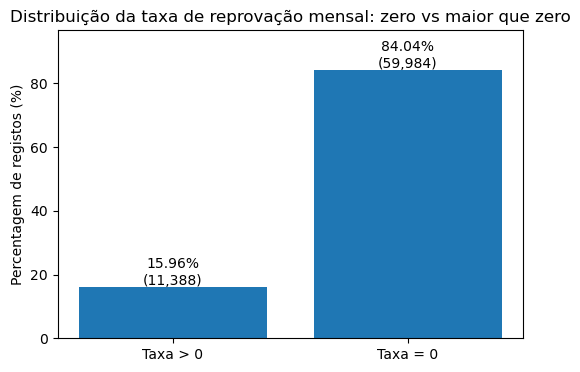

In [26]:
labels = ["Taxa > 0", "Taxa = 0"]
counts = [
    (df_model_mensal["taxa_reprovacao"] > 0).sum(),
    (df_model_mensal["taxa_reprovacao"] == 0).sum()
]

total = sum(counts)
percentages = [v / total * 100 for v in counts]

plt.figure(figsize=(6,4))
bars = plt.bar(labels, percentages)

plt.title("Distribuição da taxa de reprovação mensal: zero vs maior que zero")
plt.ylabel("Percentagem de registos (%)")

for bar, count, pct in zip(bars, counts, percentages):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{pct:.2f}%\n({count:,})",
        ha="center",
        va="bottom"
    )

plt.ylim(0, max(percentages) * 1.15)
plt.show()

<p style="font-size:17px; line-height:1.6em; color: #333;">
A comparação entre os gráficos de barras dos conjuntos de dados semanal e mensal evidencia uma melhoria ligeira no desequilíbrio da variável-alvo. A proporção de registos com taxa de reprovação superior a zero <b>aumentou de 11% para 16%</b>, mantendo-se, ainda assim, um volume de dados elevado, com cerca de 71 300 observações. Embora a agregação mensal implique uma redução do nível de detalhe, esta diminuição não é considerada crítica, dado que o número de registos continua a ser suficiente para o treino e a avaliação do modelo.
<p style="font-size:17px; line-height:1.6em; color: #333;">
Apesar da melhoria observada, o desequilíbrio da variável-alvo permanece relevante. Numa fase posterior, será considerada a aplicação de técnicas de <b>oversampling</b> para aumentar a representação dos casos com taxa de reprovação superior a zero. Este procedimento será realizado apenas após a divisão dos dados em conjuntos de treino e teste, de modo a evitar data leakage. A metodologia adotada será detalhada numa secção posterior.
<p style="font-size:17px; line-height:1.6em; color: #333;">
Deste modo, a estratégia definida para as etapas seguintes consiste na utilização do conjunto de dados agregado mensalmente.


### 6. Handle Outliers

In [25]:
#CÓDIGO PARA DETETAR OUTLIERS


# 1. Função para detectar outliers (IQR)

def detect_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 3 * IQR
    upper = Q3 + 3 * IQR

    mask = (df[col] < lower) | (df[col] > upper)
    outliers = df[mask]

    return outliers, lower, upper


# 2. Aplicar às variáveis

vars_num = ["taxa_reprovacao", "num_species_mes", "abatidos", "preco_kg", "cabecas_normais"]

for col in vars_num:
    outliers, lower, upper = detect_outliers(df_model_mensal, col)
    
    print(f"\n🔹 {col}")
    print(f"Lower bound: {lower:.2f} | Upper bound: {upper:.2f}")
    print(f"Nº de outliers: {len(outliers)}")


🔹 taxa_reprovacao
Lower bound: 0.00 | Upper bound: 0.00
Nº de outliers: 11388

🔹 num_species_mes
Lower bound: -11.00 | Upper bound: 17.00
Nº de outliers: 0

🔹 abatidos
Lower bound: -748.00 | Upper bound: 1044.00
Nº de outliers: 1610

🔹 preco_kg
Lower bound: -0.23 | Upper bound: 4.26
Nº de outliers: 0

🔹 cabecas_normais
Lower bound: -1851.09 | Upper bound: 2722.22
Nº de outliers: 1563


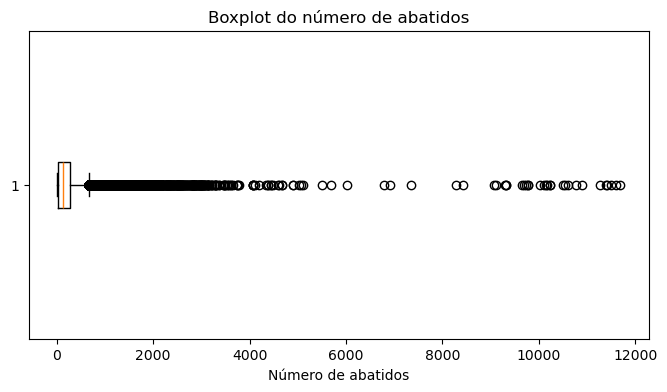

In [26]:
plt.figure(figsize=(8, 4))
plt.boxplot(df_model_mensal["abatidos"].dropna(), vert=False)
plt.title("Boxplot do número de abatidos")
plt.xlabel("Número de abatidos")
plt.show()

In [27]:
df_model_mensal["abatidos"].describe()

df_model_mensal["abatidos"].quantile([
    0, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99, 1
])

0.00        0.0
0.25       20.0
0.50      130.0
0.75      276.0
0.90      551.0
0.95      755.0
0.99     1379.0
1.00    11693.0
Name: abatidos, dtype: float64

<p style="font-size:17px; line-height:1.6em; color: #333;">
O boxplot da variável <b>abatidos</b> mostra uma distribuição assimétrica à direita, com a maioria dos registos concentrada em valores mais baixos e vários pontos com valores bastante superiores. Estes pontos são identificados pelo boxplot como potenciais outliers, mas não devem ser considerados erros, uma vez que podem corresponder a matadouros com maior volume mensal de abate. Assim, estes valores devem ser mantidos, não desem ser removidos.

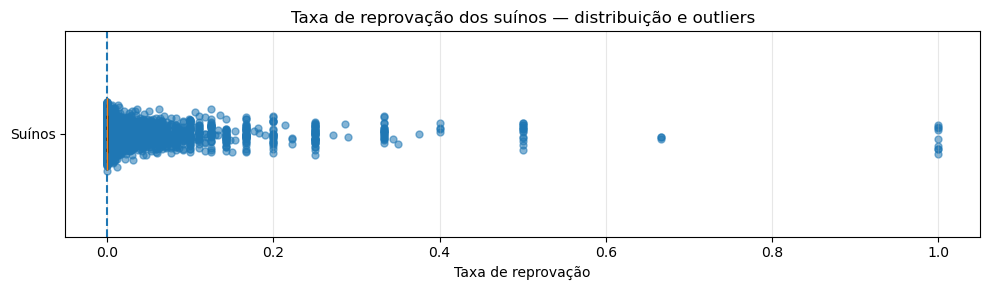

In [28]:
taxa_reprovacao = df_model_mensal["taxa_reprovacao"].dropna()

# Criar figura
plt.figure(figsize=(10, 3))

# Boxplot horizontal
plt.boxplot(
    taxa_reprovacao,
    vert=False,
    widths=0.35,
    showfliers=False,
    patch_artist=True
)

# Pontos individuais com jitter vertical
y_jitter = np.random.normal(1, 0.04, size=len(taxa_reprovacao))

plt.scatter(
    taxa_reprovacao,
    y_jitter,
    alpha=0.55,
    s=25
)

# Linha vertical no zero
plt.axvline(0, linestyle="--", linewidth=1.5)

# Títulos e labels
plt.title("Taxa de reprovação dos suínos — distribuição e outliers")
plt.xlabel("Taxa de reprovação")
plt.yticks([1], ["Suínos"])
plt.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

<p style="font-size:17px; line-height:1.6em; color: #333;">
A variável taxa_reprovacao apresenta uma forte concentração de observações próximas de zero e uma cauda longa à direita, com alguns valores extremos. No entanto, optamos por não remover estes valores, uma vez que representam taxas de reprovação reais e potencialmente relevantes para a análise, não havendo evidência de que resultem de erro de registo ou processamento

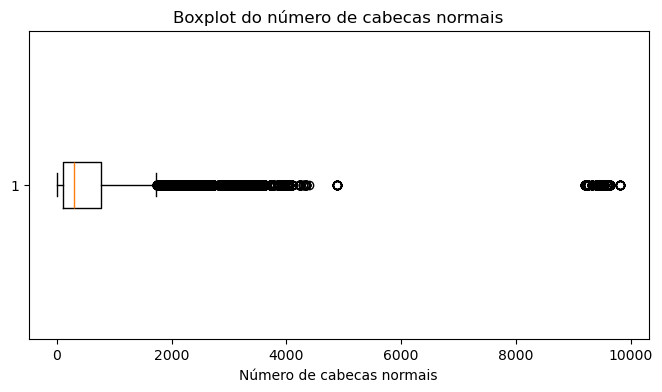

In [29]:
plt.figure(figsize=(8, 4))
plt.boxplot(df_model_mensal["cabecas_normais"].dropna(), vert=False)
plt.title("Boxplot do número de cabecas normais")
plt.xlabel("Número de cabecas normais")
plt.show()

<p style="font-size:17px; line-height:1.6em; color: #333;">
Não há evidência que estes valores, da variável cabecas normais, sejam erros, portanto os outliers não serão removidos dos dados em estudo

### 7. Análise de correlação entre features

<p style="font-size:17px; line-height:1.6em; color: #333;">
Com o intuito de avaliar a existência de <b>multicolinearidade</b> entre as features, foram construídos 2 <b>heatmaps</b>: um para as <b>variáveis categóricas</b> e outro para as <b>variáveis numéricas</b>. Esta abordagem permitiu analisar de forma clara as correlações entre as variáveis, facilitando a identificação de possíveis relações fortes que poderiam impactar o desempenho do modelo.
</p>

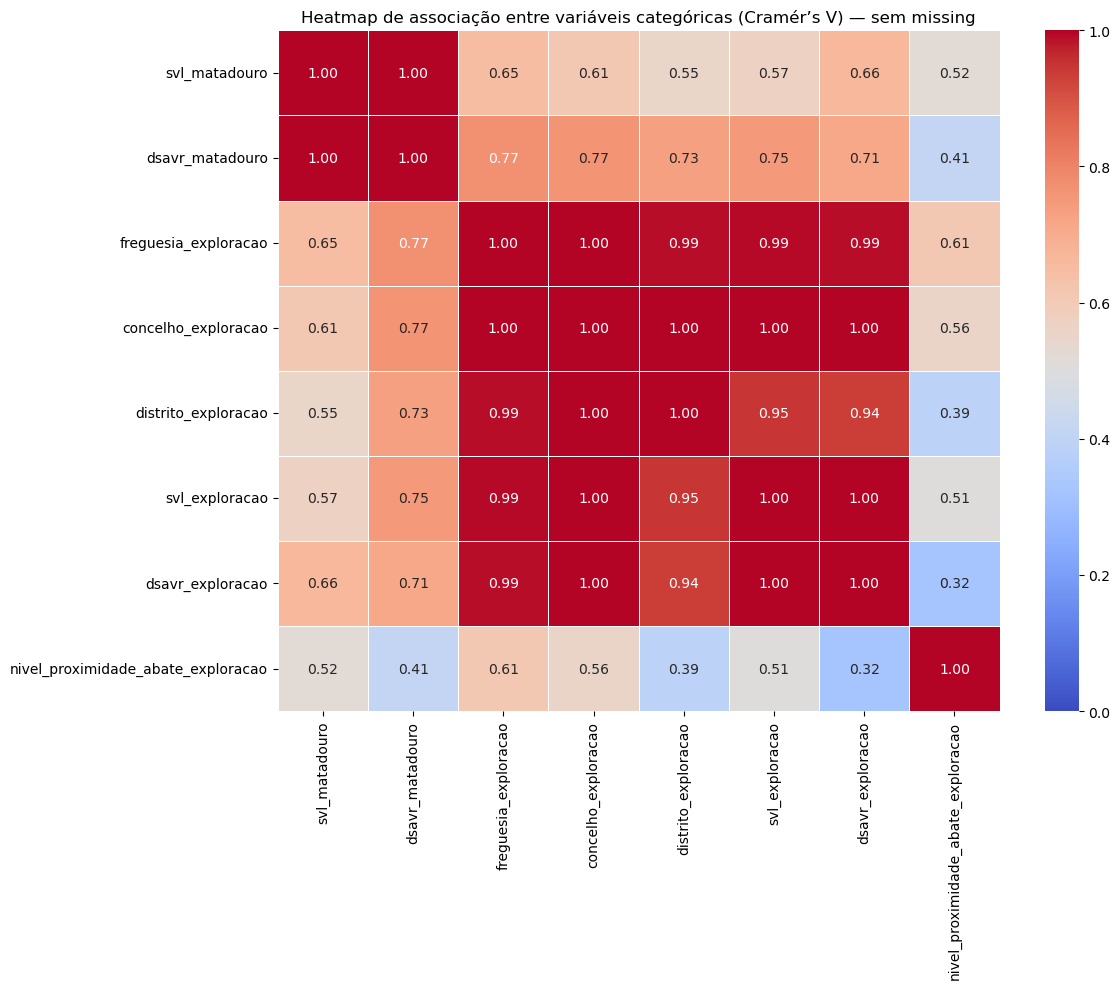

In [30]:
#Heatmap de variáveis categóricas sobre regiões geográficas da exploração animal e do matadouro onde o animal foi abatido e o tipo de matadouro


# Função para calcular Cramér's V sem usar fillna("missing")
def cramers_v_sem_missing(x, y):
    # Criar dataframe temporário só com o par de variáveis
    temp = pd.DataFrame({
        "x": x,
        "y": y
    }).dropna()

    # Se depois de remover missing houver poucos dados, devolve NaN
    if temp.empty:
        return np.nan

    # Tabela de contingência
    tabela = pd.crosstab(temp["x"], temp["y"])

    # Se uma das variáveis tiver apenas uma categoria, não há associação a calcular
    if tabela.shape[0] < 2 or tabela.shape[1] < 2:
        return np.nan

    # Qui-quadrado
    chi2 = chi2_contingency(tabela)[0]

    # Número total de observações válidas
    n = tabela.sum().sum()

    # Dimensões da tabela
    r, k = tabela.shape

    # Cramér's V
    return np.sqrt(chi2 / (n * (min(k - 1, r - 1))))


# Selecionar variáveis categóricas
cat_cols = [
    "svl_matadouro",
    "dsavr_matadouro",
    "freguesia_exploracao",
    "concelho_exploracao",
    "distrito_exploracao",
    "svl_exploracao",
    "dsavr_exploracao",
    "nivel_proximidade_abate_exploracao",
    "tipo_matadouro"
]

# Garantir que só usamos colunas que existem no dataframe
cat_cols = [col for col in cat_cols if col in df_model_mensal.columns]

# Criar matriz vazia
n = len(cat_cols)
matriz = pd.DataFrame(
    np.zeros((n, n)),
    index=cat_cols,
    columns=cat_cols
)

# Calcular matriz de associação
for i in range(n):
    for j in range(n):
        if i == j:
            matriz.iloc[i, j] = 1.0
        else:
            matriz.iloc[i, j] = cramers_v_sem_missing(
                df_model_mensal[cat_cols[i]],
                df_model_mensal[cat_cols[j]]
            )

# Plotar heatmap
plt.figure(figsize=(12, 10))

sns.heatmap(
    matriz,
    annot=True,
    cmap="coolwarm",
    vmin=0,
    vmax=1,
    fmt=".2f",
    linewidths=0.5
)

plt.title("Heatmap de associação entre variáveis categóricas (Cramér’s V) — sem missing")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

<p style="font-size:17px; line-height:1.6em; color: #333;">
Após o cálculo do Cramér’s V, excluindo os valores em falta, verificaram-se associações muito elevadas entre várias variáveis geográficas e administrativas. Este resultado sugere que as associações observadas refletem uma redundância estrutural entre variáveis que descrevem diferentes níveis de localização e organização territorial.
<p style="font-size:17px; line-height:1.6em; color: #333;">
Desta forma, para reduzir multicolinearidade e redundância informacional no modelo, foi considerada a remoção de algumas destas variáveis, mantendo apenas um subconjunto representativo da localização da exploração e do matadouro.
<p style="font-size:17px; line-height:1.6em; color: #333;">
Optou-se por manter as variáveis <b>svl_exploracao e svl_matadouro</b>, uma vez que estas apresentam maior granularidade do que a região <b>dsavr</b>, permitindo preservar informação geográfica mais detalhada. No caso da exploração, <b>decidiu-se remover freguesia_exploracao, concelho_exploracao e distrito_exploracao</b>, por representarem níveis territoriais mais específicos ou hierarquicamente relacionados com outras variáveis. A manutenção destas variáveis poderia aumentar substancialmente a dimensionalidade após o encoding e conduzir a maior risco de overfitting, sobretudo em categorias com poucos registos.
<p style="font-size:17px; line-height:1.6em; color: #333;">
Assim, a seleção das variáveis geográficas procurou equilibrar a preservação de informação espacial relevante com a redução de redundância e complexidade do modelo.


In [31]:
#Código para analisar correlação entre as variáveis dos atributos da exploração animal

cols_exploracao = [
    "tipo_entidade",
    "tipo_instalacao",
    "estrutura_producao",
    "sistema_exploracao",
    "tipo_exploracao_ciclo",
    "tipo_exploracao_dimensao"
]

df_cat = df_model_mensal[cols_exploracao].copy()

# Opcional: tratar NaN como categoria própria
df_cat = df_cat.fillna("Missing")


def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    
    if n == 0:
        return np.nan
    
    r, k = confusion_matrix.shape
    
    # Correção de bias para Cramér's V
    phi2 = chi2 / n
    phi2_corr = max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
    r_corr = r - ((r - 1) ** 2) / (n - 1)
    k_corr = k - ((k - 1) ** 2) / (n - 1)
    
    denominator = min((k_corr - 1), (r_corr - 1))
    
    if denominator == 0:
        return np.nan
    
    return np.sqrt(phi2_corr / denominator)


# Matriz de associação
cramers_matrix = pd.DataFrame(
    index=cols_exploracao,
    columns=cols_exploracao,
    dtype=float
)

for col1 in cols_exploracao:
    for col2 in cols_exploracao:
        cramers_matrix.loc[col1, col2] = cramers_v(df_cat[col1], df_cat[col2])

cramers_matrix

,tipo_entidade,tipo_instalacao,estrutura_producao,sistema_exploracao,tipo_exploracao_ciclo,tipo_exploracao_dimensao
tipo_entidade,1.000000,0.866145,0.846664,0.499305,0.410386,0.475923
tipo_instalacao,0.866145,1.000000,0.821762,0.503184,0.370068,0.475892
estrutura_producao,0.846664,0.821762,1.000000,0.487112,0.331083,0.468044
sistema_exploracao,0.499305,0.503184,0.487112,1.000000,0.490726,0.424774
tipo_exploracao_ciclo,0.410386,0.370068,0.331083,0.490726,1.000000,0.817962
tipo_exploracao_dimensao,0.475923,0.475892,0.468044,0.424774,0.817962,1.000000


<p style="font-size:17px; line-height:1.6em; color: #333;">
Após a análise da tabela, verifica-se que alguns atributos associados à exploração apresentam uma relação elevada entre si, em particular as variáveis <b>tipo_entidade, tipo_instalacao e estrutura_producao</b>. Apesar desta associação, optou-se por não remover estas variáveis numa fase inicial, uma vez que a sua relevância para a previsão da taxa de reprovação deverá ser avaliada posteriormente através do desempenho dos modelos e/ou da análise de importância das features.

<p style="font-size:17px; line-height:1.6em; color: #333;">
No entanto, é expectável que algumas destas features possam acrescentar pouco valor preditivo, dado o elevado desequilíbrio observado nas suas categorias. Como analisado no capítulo anterior, variáveis como tipo_entidade, tipo_instalacao e estrutura_producao apresentam uma forte concentração numa única categoria dominante, o que reduz a variabilidade disponível para o modelo aprender padrões diferenciadores. Assim, embora tenham sido inicialmente mantidas, estas variáveis deverão ser monitorizadas nas etapas seguintes de seleção e avaliação de features.


In [32]:
# ANÁLISE DE CORRELAÇÃO entre as features "Tipo Matadouro" e "Número de espécies"

def eta_squared(categorical, numeric):
    df_temp = pd.DataFrame({
        "cat": categorical,
        "num": numeric
    }).dropna()

    overall_mean = df_temp["num"].mean()

    ss_between = sum(
        len(group) * (group["num"].mean() - overall_mean) ** 2
        for _, group in df_temp.groupby("cat")
    )

    ss_total = sum((df_temp["num"] - overall_mean) ** 2)

    return ss_between / ss_total if ss_total != 0 else np.nan

eta = eta_squared(
    df_model_mensal["tipo_matadouro_mes"],
    df_model_mensal["num_species_mes"]
)

print("Eta squared:", eta)

Eta squared: 0.6566737425938456


<p style="font-size:17px; line-height:1.6em; color: #333;">
Existe uma correlação positiva moderada (0.68), o que é esperado, porque logicamente se o número de especies diferentes abatidas num matadouro for igual a 0, o tipo de matadouro é uniespecie, se for maior que 0, o tipo de matadouro é multiespécie.
Já que Tipo matadouro é derivado de num_species, embora correlação não seja 1, existe alguma redundância matemática mas não tão forte que se justifique a eliminação de uma das variáveis como feature. 
Devemos incluir as 2 variáveis no modelo.

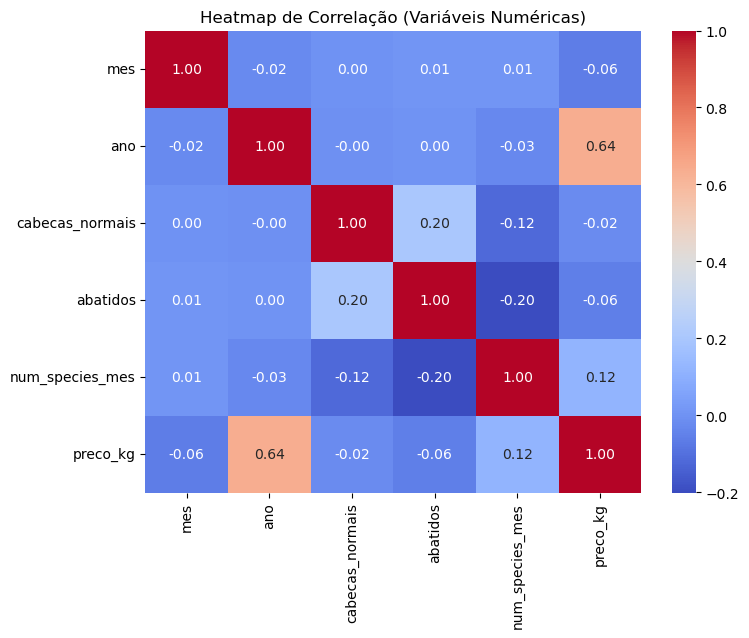

In [33]:
#Heatmap Variaveis Numericas


# Selecionar variáveis numéricas
num_cols = ['mes', 'ano', 'cabecas_normais', 'abatidos', 'num_species_mes', 'preco_kg']


# Criar matriz de correlação
corr_matrix = df_model_mensal[num_cols].corr()


# Plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Heatmap de Correlação (Variáveis Numéricas)")

plt.show()

<p style="font-size:17px; line-height:1.6em; color: #333;">
Observa-se uma correlação positiva entre ano e preco_kg, sugerindo uma tendência de aumento do preço por kg ao longo do tempo. Esta relação poderá estar associada a fatores macroeconómicos, como inflação, aumento dos custos de produção, energia, transporte ou variações no mercado da carne.

<p style="font-size:17px; line-height:1.6em; color: #333;">
De seguida, passou-se então à remoção de features redundantes e à remoção da feature reprovados, uma vez que já não é necessário recalcular-se a taxa reprovacao.

### 8. Eliminação de features redundantes

In [27]:
df_model_mensal_final = df_model_mensal.drop(
    columns=[
        "freguesia_exploracao",
        "concelho_exploracao",
        "distrito_exploracao",
        "dsavr_matadouro",
        "dsavr_exploracao",
        "reprovados"
    ],
    errors="ignore"
)

df_model_mensal_final.head(10)

,ano,mes,marca,ncv,data,abatidos,num_species_mes,tipo_matadouro_mes,svl_matadouro,svl_exploracao,tipo_entidade,tipo_instalacao,estrutura_producao,sistema_exploracao,tipo_exploracao_ciclo,tipo_exploracao_dimensao,nivel_proximidade_abate_exploracao,taxa_reprovacao,preco_kg,cabecas_normais
0,2020,1,PT90D1V,A88,2020-01-02,4.0,7.0,multiespecie,SDA S. Miguel,SDA S. Miguel,Produtor,Exploração,Exploração,Intensivo,Industrial,Ciclo Completo,mesmo_svl,0.000000,NaN,168.85
1,2020,1,PT9B26V,A92,2020-01-16,75.0,5.0,multiespecie,SDA Faial,SDA S. Miguel,Produtor,Exploração,Exploração,Intensivo,Industrial,Recria e Acabamento,mesma_dsavr,0.013333,NaN,360.35
2,2020,1,PT9B26V,A94,2020-01-10,25.0,3.0,multiespecie,SDA Pico,SDA S. Miguel,Produtor,Exploração,Exploração,Intensivo,Industrial,Recria e Acabamento,mesma_dsavr,0.000000,NaN,360.35
3,2020,1,PT9D01A,A88,2020-01-02,73.0,7.0,multiespecie,SDA S. Miguel,SDA S. Miguel,Produtor,Exploração,Exploração,Não Definido,Não Definido,Não Definido,mesmo_svl,0.000000,NaN,NaN
4,2020,1,PT9D16A,A88,2020-01-02,324.0,7.0,multiespecie,SDA S. Miguel,SDA S. Miguel,Produtor,Exploração,Exploração,Intensivo,Industrial,Ciclo Completo,mesmo_svl,0.009259,NaN,669.76
5,2020,1,PT9D16A,A93,2020-01-08,18.0,6.0,multiespecie,SDA Santa Maria,SDA S. Miguel,Produtor,Exploração,Exploração,Intensivo,Industrial,Ciclo Completo,mesma_dsavr,0.000000,NaN,669.76
6,2020,1,PT9F06A,A88,2020-01-02,458.0,7.0,multiespecie,SDA S. Miguel,SDA S. Miguel,Produtor,Exploração,Exploração,Intensivo,Industrial,Ciclo Completo,mesmo_svl,0.000000,NaN,3931.38
7,2020,1,PT9F06A,A89,2020-01-02,200.0,6.0,multiespecie,SDA Terceira,SDA S. Miguel,Produtor,Exploração,Exploração,Intensivo,Industrial,Ciclo Completo,mesma_dsavr,0.005000,NaN,3931.38
8,2020,1,PT9F06A,A94,2020-01-10,60.0,3.0,multiespecie,SDA Pico,SDA S. Miguel,Produtor,Exploração,Exploração,Intensivo,Industrial,Ciclo Completo,mesma_dsavr,0.000000,NaN,3931.38
9,2020,1,PT9F34V,A88,2020-01-09,15.0,7.0,multiespecie,SDA S. Miguel,SDA S. Miguel,Produtor,Exploração,Exploração,Extensivo,Familiar,Recria e Acabamento,mesmo_svl,0.000000,NaN,15.00


In [34]:
df_model_mensal_final.dtypes

ano                                     int32
mes                                     int32
marca                                  object
ncv                                    object
data                                    int64
abatidos                              float64
num_species_mes                       float64
tipo_matadouro_mes                     object
svl_matadouro                          object
svl_exploracao                         object
tipo_entidade                          object
tipo_instalacao                        object
estrutura_producao                     object
sistema_exploracao                     object
tipo_exploracao_ciclo                  object
tipo_exploracao_dimensao               object
nivel_proximidade_abate_exploracao     object
taxa_reprovacao                       float64
preco_kg                              float64
cabecas_normais                       float64
dtype: object

In [37]:
# Converter data type
df_model_mensal_final["data"] = pd.to_datetime(
    df_model_mensal_final["data"]
)
df_model_mensal_final["ano"] = df_model_mensal_final["data"].dt.year
df_model_mensal_final["mes"] = df_model_mensal_final["data"].dt.month

df_model_mensal_final["data"] = (
    df_model_mensal_final["data"].astype("int64")
)

In [38]:
df_model_mensal_final.dtypes

ano                                     int32
mes                                     int32
marca                                  object
ncv                                    object
data                                    int64
abatidos                              float64
num_species_mes                       float64
tipo_matadouro_mes                     object
svl_matadouro                          object
svl_exploracao                         object
tipo_entidade                          object
tipo_instalacao                        object
estrutura_producao                     object
sistema_exploracao                     object
tipo_exploracao_ciclo                  object
tipo_exploracao_dimensao               object
nivel_proximidade_abate_exploracao     object
taxa_reprovacao                       float64
preco_kg                              float64
cabecas_normais                       float64
dtype: object

# Parte 3 — Modelação Preditiva da Taxa de Reprovação de Suínos (problema regressão)


<p style="font-size:20px; line-height:1.6em; color: #333;">
O dataset deve ser inicialmente dividido em conjuntos de treino, validação e/ou teste. Neste trabalho, a divisão dos dados foi realizada com base no período temporal, e não de forma aleatória, de modo a respeitar a natureza cronológica dos dados e simular melhor um cenário real de previsão. Assim, os dados de treino correspondem aos anos de <b>2020 a 2023</b>, enquanto os dados de teste correspondem ao ano de <b>2024</b>.<br><br>
<p style="font-size:20px; line-height:1.6em; color: #333;">
Esta etapa é fundamental para evitar data leakage, isto é, a utilização indevida de informação futura durante o treino do modelo. Uma vez que se trata de um problema com estrutura temporal, uma divisão aleatória poderia misturar observações de anos posteriores no conjunto de treino, conduzindo a uma avaliação demasiado otimista do desempenho.<br><br>
<p style="font-size:20px; line-height:1.6em; color: #333;">
A <b>normalização das variáveis numéricas</b> através do StandardScaler, foi realizada apenas após a divisão dos dados. O scaler deve ser ajustado exclusivamente com os dados do conjunto de treino, utilizando fit_transform, e posteriormente aplicado aos conjuntos de validação e/ou teste através de transform. Isto é necessário porque estes métodos recorrem a estatísticas, como a média e o desvio padrão, que não devem ser calculadas com base em todo o dataset, sob pena de enviesar a avaliação do modelo.<br><br>
<p style="font-size:20px; line-height:1.6em; color: #333;">
O mesmo princípio aplica-se ao <b>tratamento de valores em falta</b>. O preenchimento dos valores nulos foi definido com base nas estatísticas do conjunto de treino, enquanto nos conjuntos de validação e/ou teste apenas se aplicou a transformação aprendida, sem novo ajuste.<br><br>
<p style="font-size:20px; line-height:1.6em; color: #333;">
De forma semelhante, o processo de <b>encoding das variáveis categóricas</b> deve ser ajustado apenas com os dados de treino e posteriormente aplicado aos restantes conjuntos. Esta abordagem garante consistência entre os conjuntos e preserva a integridade da avaliação do modelo.
<p style="font-size:20px; line-height:1.6em; color: #333;">
Devido à elevada concentração da variável-alvo em valores iguais a zero, antecipou-se que o modelo pudesse apresentar dificuldades na previsão dos eventos de reprovação, por estes ocorrerem com menor frequência. Assim, decidiu-se aplicar uma técnica de <b>oversampling</b> exclusivamente ao conjunto de treino, após a divisão dos dados em treino e teste, de forma a aumentar a representatividade dos casos com taxa de reprovação superior a zero e evitar a ocorrência de data leakage.

</p>


In [39]:

# DIVISÃO TEMPORAL DO DATASET
# Treino: 2020-2023
# Teste: 2024

mlflow.autolog(disable=True)

# Dataset final já preparado
data = df_model_mensal_final.copy()

# Variável-alvo
target = "taxa_reprovacao"

# Divisão temporal
train_data = data[data["ano"].between(2020, 2023)].copy()
test_data = data[data["ano"] == 2024].copy()

# Separar X e y
X_train = train_data.drop(columns=[target])
y_train = train_data[target]

X_test = test_data.drop(columns=[target])
y_test = test_data[target]

# Verificações
print("Treino:")
print("Linhas:", X_train.shape[0])
print("Anos:", sorted(train_data["ano"].unique()))

print("\nTeste:")
print("Linhas:", X_test.shape[0])
print("Anos:", sorted(test_data["ano"].unique()))

print("\nShapes:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

Treino:
Linhas: 58498
Anos: [2020, 2021, 2022, 2023]

Teste:
Linhas: 12874
Anos: [2024]

Shapes:
X_train: (58498, 19)
y_train: (58498,)
X_test: (12874, 19)
y_test: (12874,)


In [40]:
# Contagem e percentagem de nulls por coluna no dataframe mensal

total_rows = len(df_model_mensal_final)

nulls_mensal = pd.DataFrame({
    "n_nulls": df_model_mensal_final.isna().sum(),
    "pct_nulls": (df_model_mensal_final.isna().sum() / total_rows * 100).round(2)
})

nulls_mensal = (
    nulls_mensal
    .sort_values("pct_nulls", ascending=False)
)

print("Número total de linhas do dataframe mensal:", total_rows)
print("Percentagem de nulls do dataframe mensal:", nulls_mensal)

Número total de linhas do dataframe mensal: 71372
Percentagem de nulls do dataframe mensal:                                     n_nulls  pct_nulls
preco_kg                               2181       3.06
cabecas_normais                        1026       1.44
mes                                       0       0.00
taxa_reprovacao                           0       0.00
nivel_proximidade_abate_exploracao        0       0.00
tipo_exploracao_dimensao                  0       0.00
tipo_exploracao_ciclo                     0       0.00
sistema_exploracao                        0       0.00
estrutura_producao                        0       0.00
tipo_instalacao                           0       0.00
ano                                       0       0.00
svl_exploracao                            0       0.00
svl_matadouro                             0       0.00
tipo_matadouro_mes                        1       0.00
num_species_mes                           1       0.00
abatidos                    

In [41]:

# TRATAMENTO DE NULLS APÓS SPLIT TEMPORAL
# Estatísticas calculadas apenas no treino

# Garantir tipos numéricos
for df_tmp in [train_data, test_data]:
    df_tmp["preco_kg"] = pd.to_numeric(df_tmp["preco_kg"], errors="coerce")
    df_tmp["cabecas_normais"] = pd.to_numeric(df_tmp["cabecas_normais"], errors="coerce")



# 1. Remover nulls residuais em num_species_mes / tipo_matadouro_mes

cols_null_residuais = ["num_species_mes", "tipo_matadouro_mes"]

print("Antes de remover nulls residuais:")
print("Treino:")
print(train_data[cols_null_residuais].isna().sum())
print("\nTeste:")
print(test_data[cols_null_residuais].isna().sum())

train_data = train_data.dropna(subset=cols_null_residuais).copy()
test_data = test_data.dropna(subset=cols_null_residuais).copy()

print("\nDepois de remover nulls residuais:")
print("Treino:")
print(train_data[cols_null_residuais].isna().sum())
print("\nTeste:")
print(test_data[cols_null_residuais].isna().sum())



# 2. Imputar preco_kg
# Mediana global móvel dos últimos 6 meses do treino

def criar_chave_mes(df):
    return pd.to_datetime(
        df["ano"].astype(str) + "-" + df["mes"].astype(str).str.zfill(2) + "-01"
    )

train_data["ano_mes"] = criar_chave_mes(train_data)
test_data["ano_mes"] = criar_chave_mes(test_data)

# Mediana mensal global calculada apenas no treino
preco_mensal_treino = (
    train_data
    .dropna(subset=["preco_kg"])
    .groupby("ano_mes")["preco_kg"]
    .median()
    .sort_index()
)

# Mediana móvel dos últimos 6 meses anteriores
# shift(1) evita usar o próprio mês para imputar esse mês
preco_movel_6m = (
    preco_mensal_treino
    .rolling(window=6, min_periods=1)
    .median()
    .shift(1)
)

preco_global_treino = train_data["preco_kg"].median()
preco_movel_6m = preco_movel_6m.fillna(preco_global_treino)

# Para meses de teste que não existem no mapa do treino,
# usar o último valor conhecido aprendido no treino
ultimo_preco_6m_treino = preco_movel_6m.dropna().iloc[-1]


def imputar_preco_6m(df, mapa_preco_6m, fallback):
    df = df.copy()

    mask_null = df["preco_kg"].isna()
    valores_imputacao = df["ano_mes"].map(mapa_preco_6m)

    df.loc[mask_null, "preco_kg"] = valores_imputacao[mask_null]
    df["preco_kg"] = df["preco_kg"].fillna(fallback)

    return df


train_data = imputar_preco_6m(
    train_data,
    preco_movel_6m,
    preco_global_treino
)

test_data = imputar_preco_6m(
    test_data,
    preco_movel_6m,
    ultimo_preco_6m_treino
)



# 3. Imputar cabecas_normais
# 1. mediana por marca + mes
# 2. mediana por marca
# 3. mediana global do treino

def criar_mapa_mediana(df, group_cols, target_col):
    return (
        df
        .dropna(subset=[target_col])
        .groupby(group_cols)[target_col]
        .median()
    )


def aplicar_mapa_mediana(df, mapa, group_cols, target_col):
    df = df.copy()

    keys = list(zip(*[df[col] for col in group_cols]))
    valores = pd.Series(keys, index=df.index).map(mapa)

    mask = df[target_col].isna()
    df.loc[mask, target_col] = valores[mask]

    return df


med_cabecas_marca_mes = criar_mapa_mediana(
    train_data,
    ["marca", "mes"],
    "cabecas_normais"
)

med_cabecas_marca = criar_mapa_mediana(
    train_data,
    ["marca"],
    "cabecas_normais"
)

med_cabecas_global = train_data["cabecas_normais"].median()

train_data = aplicar_mapa_mediana(
    train_data,
    med_cabecas_marca_mes,
    ["marca", "mes"],
    "cabecas_normais"
)

test_data = aplicar_mapa_mediana(
    test_data,
    med_cabecas_marca_mes,
    ["marca", "mes"],
    "cabecas_normais"
)

train_data = aplicar_mapa_mediana(
    train_data,
    med_cabecas_marca,
    ["marca"],
    "cabecas_normais"
)

test_data = aplicar_mapa_mediana(
    test_data,
    med_cabecas_marca,
    ["marca"],
    "cabecas_normais"
)

train_data["cabecas_normais"] = train_data["cabecas_normais"].fillna(med_cabecas_global)
test_data["cabecas_normais"] = test_data["cabecas_normais"].fillna(med_cabecas_global)



# 4. Remover coluna auxiliar e recriar X/y

train_data = train_data.drop(columns=["ano_mes"], errors="ignore")
test_data = test_data.drop(columns=["ano_mes"], errors="ignore")

X_train = train_data.drop(columns=[target])
y_train = train_data[target]

X_test = test_data.drop(columns=[target])
y_test = test_data[target]



# 5. Check final

cols_check = [
    "preco_kg",
    "cabecas_normais",
    "num_species_mes",
    "tipo_matadouro_mes"
]

print("\nNulls finais no treino:")
print(train_data[cols_check].isna().sum())

print("\nNulls finais no teste:")
print(test_data[cols_check].isna().sum())

print("\nShapes finais:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)
 

Antes de remover nulls residuais:
Treino:
num_species_mes       1
tipo_matadouro_mes    1
dtype: int64

Teste:
num_species_mes       0
tipo_matadouro_mes    0
dtype: int64

Depois de remover nulls residuais:
Treino:
num_species_mes       0
tipo_matadouro_mes    0
dtype: int64

Teste:
num_species_mes       0
tipo_matadouro_mes    0
dtype: int64

Nulls finais no treino:
preco_kg              0
cabecas_normais       0
num_species_mes       0
tipo_matadouro_mes    0
dtype: int64

Nulls finais no teste:
preco_kg              0
cabecas_normais       0
num_species_mes       0
tipo_matadouro_mes    0
dtype: int64

Shapes finais:
X_train: (58497, 19)
y_train: (58497,)
X_test: (12874, 19)
y_test: (12874,)


<p style="font-size:20px; line-height:1.6em; color: #333;">
Após a divisão temporal dos dados em treino e teste, foram tratados os valores nulos de forma a evitar data leakage. Inicialmente, removeram-se os registos com valores residuais em <b>num_species_mes e tipo_matadouro_mes</b>. Para a variável <b>preco_kg </b>, os valores em falta — associados sobretudo à ausência de informação de preços nas regiões insulares da Madeira e dos Açores — foram imputados com base na mediana móvel dos seis meses anteriores, calculada exclusivamente a partir do conjunto de treino. Relativamente a <b>cabecas_normais</b>, adotou-se uma estratégia hierárquica: mediana por marca e mês, seguida da mediana por marca e, quando ainda necessário, da mediana global do treino. Desta forma, procurou-se preservar a coerência temporal e a especificidade de cada exploração, sem utilizar informação proveniente do conjunto de teste.

In [42]:
#codigo para oversampling smooth

def smooth_oversample_regression(
    X,
    y,
    positive_threshold=0,
    target_positive_ratio=0.3,  #definiu-se a taxa dos 30% mas podemos por 40% 
    noise_std=0.01,
    random_state=42
):
    rng = np.random.default_rng(random_state)

    X = X.copy()
    y = y.copy()

    mask_pos = y > positive_threshold
    X_pos = X[mask_pos].copy()
    y_pos = y[mask_pos].copy()

    X_neg = X[~mask_pos].copy()
    y_neg = y[~mask_pos].copy()

    n_pos = len(X_pos)
    n_neg = len(X_neg)

    if n_pos == 0:
        raise ValueError("Não existem casos positivos para oversampling.")

    # número necessário de positivos para atingir target ratio:
    # n_pos_final / (n_pos_final + n_neg) = target_positive_ratio
    n_pos_target = int((target_positive_ratio * n_neg) / (1 - target_positive_ratio))

    n_to_add = max(0, n_pos_target - n_pos)

    if n_to_add == 0:
        return X, y

    sampled_idx = rng.choice(X_pos.index, size=n_to_add, replace=True)

    X_new = X_pos.loc[sampled_idx].copy()
    y_new = y_pos.loc[sampled_idx].copy()

    # Adicionar ruído pequeno só nas colunas numéricas
    numeric_cols = X_new.select_dtypes(include=["int64", "float64"]).columns

    for col in numeric_cols:
        std = X_pos[col].std()
        if pd.notna(std) and std > 0:
            X_new[col] = X_new[col] + rng.normal(
                loc=0,
                scale=noise_std * std,
                size=len(X_new)
            )

    X_over = pd.concat([X, X_new], axis=0).reset_index(drop=True)
    y_over = pd.concat([y, y_new], axis=0).reset_index(drop=True)

    return X_over, y_over

marca                                 0.338534
abatidos                              0.155339
data                                  0.127695
preco_kg                              0.118129
cabecas_normais                       0.093355
mes                                   0.073800
ncv                                   0.027573
num_species_mes                       0.024489
ano                                   0.012492
svl_exploracao                        0.008599
svl_matadouro                         0.008510
tipo_exploracao_ciclo                 0.007655
nivel_proximidade_abate_exploracao    0.001558
sistema_exploracao                    0.001380
tipo_exploracao_dimensao              0.000869
tipo_matadouro_mes                    0.000015
tipo_entidade                         0.000009
tipo_instalacao                       0.000000
estrutura_producao                    0.000000
dtype: float64


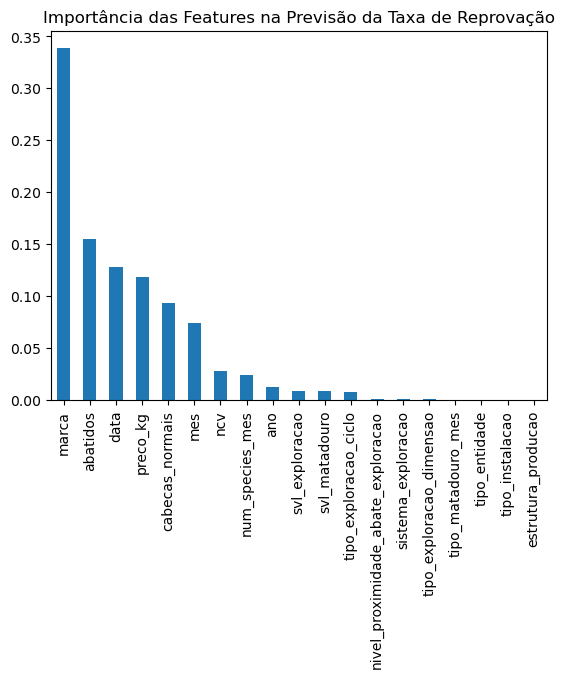

In [43]:
# Modelação e Análise de Importância das Features na Taxa de Reprovação

# 1. Seleção inicial de features

features = X_train.columns.tolist()

df_taxa_model = X_train.copy()
df_taxa_model["taxa_reprovacao"] = y_train


# 2. Definir grupos de colunas

numeric_cols = df_taxa_model[features].select_dtypes(
    include=["int64", "float64", "int32", "float32"]
).columns.tolist()

onehot_cols = df_taxa_model[features].select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()


# 3. Pipelines

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

onehot_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", drop="first"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_cols),
    ("oh", onehot_pipeline, onehot_cols)
])


# 4. Separar X e y

X = df_taxa_model.drop(columns=["taxa_reprovacao"])
y = df_taxa_model["taxa_reprovacao"]


# 5. Remover linhas sem taxa_reprovacao

mask = y.notna()
X = X[mask]
y = y[mask]


# 6. Pipeline final

model_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=50,
        max_depth=10,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1
    ))
])


# 7. Treinar

model_pipeline.fit(X, y)


# 8. Importâncias detalhadas

feature_names = model_pipeline.named_steps["preprocessor"].get_feature_names_out()
importances = model_pipeline.named_steps["model"].feature_importances_

importance_series = pd.Series(importances, index=feature_names)


# 9. Mapear cada coluna transformada para a variável original

aggregated_importances = {}

for feature, importance in importance_series.items():
    if feature.startswith("num__"):
        original_name = feature.replace("num__", "")

    elif feature.startswith("oh__"):
        transformed_name = feature.replace("oh__", "")

        original_name = transformed_name

        for col in onehot_cols:
            if transformed_name.startswith(col + "_"):
                original_name = col
                break

    else:
        original_name = feature

    aggregated_importances[original_name] = aggregated_importances.get(original_name, 0) + importance


# 10. Resultado final

aggregated_importance_series = pd.Series(aggregated_importances).sort_values(ascending=False)

print(aggregated_importance_series)

aggregated_importance_series.plot(
    kind="bar",
    title="Importância das Features na Previsão da Taxa de Reprovação"
)

plt.show()

<p style="font-size:20px; line-height:1.6em; color: #333;">
A análise de importância das variáveis revelou que a <b>marca da exploração, o número de animais abatidos, a componente temporal e o preço por quilograma</b> constituem os principais fatores explicativos da taxa de reprovação observada. Em contraste, as restantes variáveis apresentaram uma influência significativamente inferior na capacidade preditiva do modelo.


=== Random Forest Regression Summary ===
MAE Global        : 0.006842
MSE Global        : 0.001104
RMSE Global       : 0.033232
R² Global         : -1.446356
MAE Taxa > 0      : 0.011739
RMSE Taxa > 0     : 0.051736


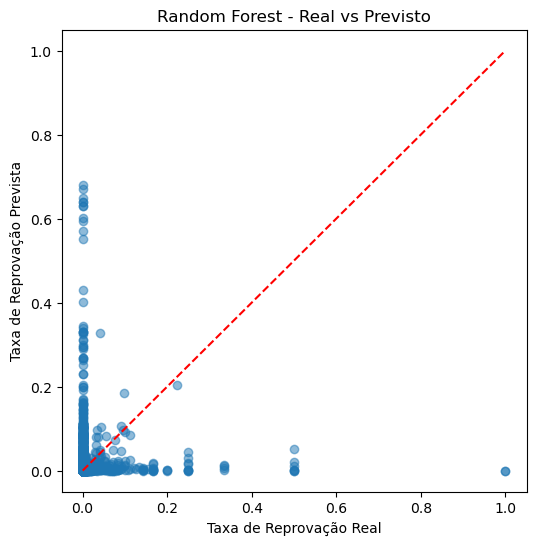

In [46]:
# RANDOM FOREST REGRESSOR

# 1. Aplicar oversampling ao treino

X_train_over, y_train_over = smooth_oversample_regression(
    X_train,
    y_train,
    positive_threshold=0,
    target_positive_ratio=0.3,
    noise_std=0.01,
    random_state=42
)


# 2. Definir features

selected_features = X_train_over.columns.tolist()

X_train_sel = X_train_over[selected_features].copy()
X_test_sel = X_test[selected_features].copy()

y_train_aligned = y_train_over.copy()
y_test_aligned = y_test.copy()


# 3. Definir tipos de colunas

numeric_cols = X_train_sel.select_dtypes(
    include=["int64", "float64", "int32", "float32"]
).columns.tolist()

onehot_cols = X_train_sel.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()


# 4. Pipelines por tipo de variável

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

onehot_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", drop="first"))
])


# 5. Preprocessor

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_cols),
    ("oh", onehot_pipeline, onehot_cols)
])


# 6. Pipeline final com Random Forest

model_rf = Pipeline([
    ("prep", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ))
])


# 7. Treinar modelo

model_rf.fit(X_train_sel, y_train_aligned)


# 8. Previsões

y_pred_rf = model_rf.predict(X_test_sel)

# Evitar previsões negativas
y_pred_rf = np.maximum(y_pred_rf, 0)


# 9. Métricas globais e para casos com taxa > 0

mae = mean_absolute_error(y_test_aligned, y_pred_rf)
mse = mean_squared_error(y_test_aligned, y_pred_rf)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_aligned, y_pred_rf)

# Métrica específica para os casos relevantes: taxa de reprovação > 0
mask_pos = y_test_aligned > 0

mae_pos = mean_absolute_error(
    y_test_aligned[mask_pos],
    y_pred_rf[mask_pos]
)

rmse_pos = np.sqrt(mean_squared_error(
    y_test_aligned[mask_pos],
    y_pred_rf[mask_pos]
))

print("\n=== Random Forest Regression Summary ===")
print(f"MAE Global        : {mae:.6f}")
print(f"MSE Global        : {mse:.6f}")
print(f"RMSE Global       : {rmse:.6f}")
print(f"R² Global         : {r2:.6f}")
print(f"MAE Taxa > 0      : {mae_pos:.6f}")
print(f"RMSE Taxa > 0     : {rmse_pos:.6f}")


# 10. Predicted vs Actual

plt.figure(figsize=(6,6))

plt.scatter(
    y_test_aligned,
    y_pred_rf,
    alpha=0.5
)

plt.plot(
    [y_test_aligned.min(), y_test_aligned.max()],
    [y_test_aligned.min(), y_test_aligned.max()],
    'r--'
)

plt.xlabel("Taxa de Reprovação Real")
plt.ylabel("Taxa de Reprovação Prevista")
plt.title("Random Forest - Real vs Previsto")

plt.show()



=== Extra Trees Regression Summary ===
MAE Global        : 0.004908
MSE Global        : 0.000889
RMSE Global       : 0.029817
R² Global         : -0.969344
MAE Taxa > 0      : 0.012025
RMSE Taxa > 0     : 0.052050


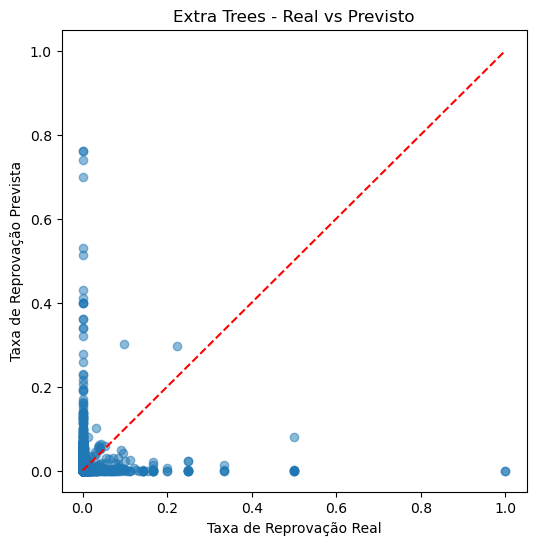

In [47]:
# EXTRA TREES REGRESSOR

from sklearn.ensemble import ExtraTreesRegressor

# 1. Aplicar oversampling ao treino

X_train_over, y_train_over = smooth_oversample_regression(
    X_train,
    y_train,
    positive_threshold=0,
    target_positive_ratio=0.3,
    noise_std=0.01,
    random_state=42
)


# 2. Definir features

selected_features = X_train_over.columns.tolist()

X_train_sel = X_train_over[selected_features].copy()
X_test_sel = X_test[selected_features].copy()

y_train_aligned = y_train_over.copy()
y_test_aligned = y_test.copy()


# 3. Definir tipos de colunas

numeric_cols = X_train_sel.select_dtypes(
    include=["int64", "float64", "int32", "float32"]
).columns.tolist()

onehot_cols = X_train_sel.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()


# 4. Pipelines por tipo de variável

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

onehot_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", drop="first"))
])


# 5. Preprocessor

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_cols),
    ("oh", onehot_pipeline, onehot_cols)
])


# 6. Pipeline final com Extra Trees

model_et = Pipeline([
    ("prep", preprocessor),
    ("model", ExtraTreesRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ))
])


# 7. Treinar modelo

model_et.fit(X_train_sel, y_train_aligned)


# 8. Previsões

y_pred_et = model_et.predict(X_test_sel)

# Evitar previsões negativas
y_pred_et = np.maximum(y_pred_et, 0)


# 9. Métricas

mae = mean_absolute_error(y_test_aligned, y_pred_et)
mse = mean_squared_error(y_test_aligned, y_pred_et)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_aligned, y_pred_et)

mask_pos = y_test_aligned > 0

mae_pos = mean_absolute_error(
    y_test_aligned[mask_pos],
    y_pred_et[mask_pos]
)

rmse_pos = np.sqrt(mean_squared_error(
    y_test_aligned[mask_pos],
    y_pred_et[mask_pos]
))

print("\n=== Extra Trees Regression Summary ===")
print(f"MAE Global        : {mae:.6f}")
print(f"MSE Global        : {mse:.6f}")
print(f"RMSE Global       : {rmse:.6f}")
print(f"R² Global         : {r2:.6f}")
print(f"MAE Taxa > 0      : {mae_pos:.6f}")
print(f"RMSE Taxa > 0     : {rmse_pos:.6f}")


# 10. Predicted vs Actual

plt.figure(figsize=(6,6))

plt.scatter(
    y_test_aligned,
    y_pred_et,
    alpha=0.5
)

plt.plot(
    [y_test_aligned.min(), y_test_aligned.max()],
    [y_test_aligned.min(), y_test_aligned.max()],
    'r--'
)

plt.xlabel("Taxa de Reprovação Real")
plt.ylabel("Taxa de Reprovação Prevista")
plt.title("Extra Trees - Real vs Previsto")

plt.show()


=== XGBoost Regression Summary ===
MAE Global        : 0.005814
MSE Global        : 0.000880
RMSE Global       : 0.029662
R² Global         : -0.948985
MAE Taxa > 0      : 0.011512
RMSE Taxa > 0     : 0.051782


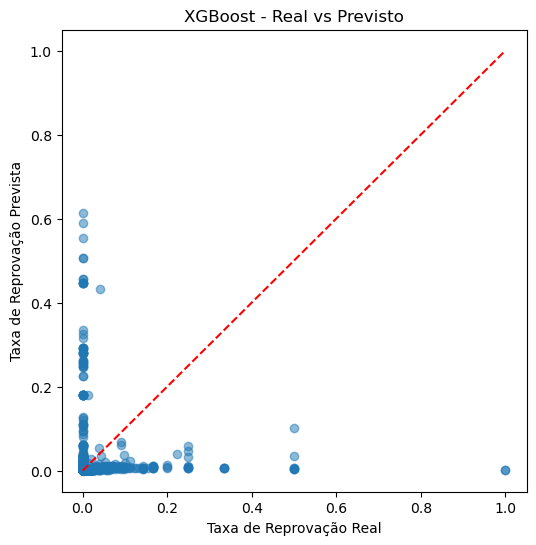

In [48]:
# XGBOOST REGRESSOR

import warnings
warnings.filterwarnings("ignore")

# 1. Aplicar oversampling ao treino

X_train_over, y_train_over = smooth_oversample_regression(
    X_train,
    y_train,
    positive_threshold=0,
    target_positive_ratio=0.3,
    noise_std=0.01,
    random_state=42
)


# 2. Definir features

selected_features = X_train_over.columns.tolist()

X_train_sel = X_train_over[selected_features].copy()
X_test_sel = X_test[selected_features].copy()

y_train_aligned = y_train_over.copy()
y_test_aligned = y_test.copy()


# 3. Definir tipos de colunas

numeric_cols = X_train_sel.select_dtypes(
    include=["int64", "float64", "int32", "float32"]
).columns.tolist()

onehot_cols = X_train_sel.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()


# 4. Pipelines por tipo de variável

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

onehot_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", drop="first"))
])


# 5. Preprocessor

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_cols),
    ("oh", onehot_pipeline, onehot_cols)
])


# 6. Pipeline final com XGBoost

model_xgb = Pipeline([
    ("prep", preprocessor),
    ("model", XGBRegressor(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    ))
])


# 7. Treinar modelo

model_xgb.fit(X_train_sel, y_train_aligned)


# 8. Previsões

y_pred_xgb = model_xgb.predict(X_test_sel)

y_pred_xgb = np.maximum(y_pred_xgb, 0)


# 9. Métricas

mae = mean_absolute_error(y_test_aligned, y_pred_xgb)
mse = mean_squared_error(y_test_aligned, y_pred_xgb)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_aligned, y_pred_xgb)

mask_pos = y_test_aligned > 0

mae_pos = mean_absolute_error(
    y_test_aligned[mask_pos],
    y_pred_xgb[mask_pos]
)

rmse_pos = np.sqrt(mean_squared_error(
    y_test_aligned[mask_pos],
    y_pred_xgb[mask_pos]
))

print("\n=== XGBoost Regression Summary ===")
print(f"MAE Global        : {mae:.6f}")
print(f"MSE Global        : {mse:.6f}")
print(f"RMSE Global       : {rmse:.6f}")
print(f"R² Global         : {r2:.6f}")
print(f"MAE Taxa > 0      : {mae_pos:.6f}")
print(f"RMSE Taxa > 0     : {rmse_pos:.6f}")


# 10. Predicted vs Actual

plt.figure(figsize=(6,6))

plt.scatter(
    y_test_aligned,
    y_pred_xgb,
    alpha=0.5
)

plt.plot(
    [y_test_aligned.min(), y_test_aligned.max()],
    [y_test_aligned.min(), y_test_aligned.max()],
    'r--'
)

plt.xlabel("Taxa de Reprovação Real")
plt.ylabel("Taxa de Reprovação Prevista")
plt.title("XGBoost - Real vs Previsto")

plt.show()


=== MLP Regression Summary ===
MAE Global        : 0.015443
MSE Global        : 0.002468
RMSE Global       : 0.049677
R² Global         : -4.466488
MAE Taxa > 0      : 0.014559
RMSE Taxa > 0     : 0.052833


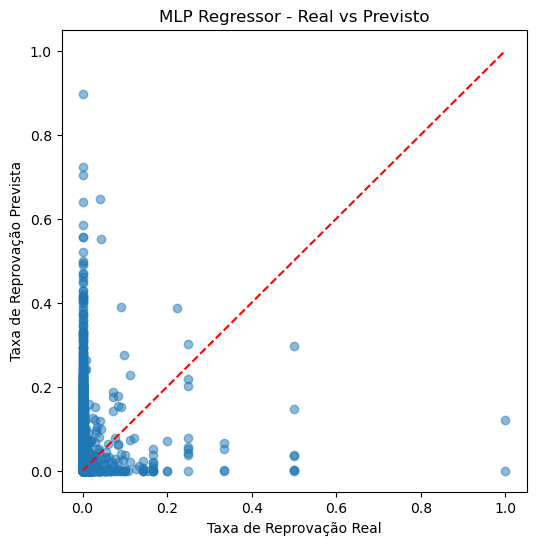

In [49]:
# MLP REGRESSOR

from sklearn.neural_network import MLPRegressor
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

# 1. Aplicar oversampling ao treino

X_train_over, y_train_over = smooth_oversample_regression(
    X_train,
    y_train,
    positive_threshold=0,
    target_positive_ratio=0.3,
    noise_std=0.01,
    random_state=42
)


# 2. Definir features

selected_features = X_train_over.columns.tolist()

X_train_sel = X_train_over[selected_features].copy()
X_test_sel = X_test[selected_features].copy()

y_train_aligned = y_train_over.copy()
y_test_aligned = y_test.copy()


# 3. Definir tipos de colunas

numeric_cols = X_train_sel.select_dtypes(
    include=["int64", "float64", "int32", "float32"]
).columns.tolist()

onehot_cols = X_train_sel.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()


# 4. Pipelines por tipo de variável

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

onehot_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", drop="first"))
])


# 5. Preprocessor

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_cols),
    ("oh", onehot_pipeline, onehot_cols)
])


# 6. Pipeline final com MLP Regressor

model_mlp = Pipeline([
    ("prep", preprocessor),
    ("model", MLPRegressor(
        hidden_layer_sizes=(64, 32),
        activation="relu",
        solver="adam",
        alpha=0.0001,
        learning_rate_init=0.001,
        max_iter=300,
        early_stopping=True,
        random_state=42
    ))
])


# 7. Treinar modelo

model_mlp.fit(X_train_sel, y_train_aligned)


# 8. Previsões

y_pred_mlp = model_mlp.predict(X_test_sel)

y_pred_mlp = np.maximum(y_pred_mlp, 0)


# 9. Métricas

mae = mean_absolute_error(y_test_aligned, y_pred_mlp)
mse = mean_squared_error(y_test_aligned, y_pred_mlp)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_aligned, y_pred_mlp)

mask_pos = y_test_aligned > 0

mae_pos = mean_absolute_error(
    y_test_aligned[mask_pos],
    y_pred_mlp[mask_pos]
)

rmse_pos = np.sqrt(mean_squared_error(
    y_test_aligned[mask_pos],
    y_pred_mlp[mask_pos]
))

print("\n=== MLP Regression Summary ===")
print(f"MAE Global        : {mae:.6f}")
print(f"MSE Global        : {mse:.6f}")
print(f"RMSE Global       : {rmse:.6f}")
print(f"R² Global         : {r2:.6f}")
print(f"MAE Taxa > 0      : {mae_pos:.6f}")
print(f"RMSE Taxa > 0     : {rmse_pos:.6f}")


# 10. Predicted vs Actual

plt.figure(figsize=(6,6))

plt.scatter(
    y_test_aligned,
    y_pred_mlp,
    alpha=0.5
)

plt.plot(
    [y_test_aligned.min(), y_test_aligned.max()],
    [y_test_aligned.min(), y_test_aligned.max()],
    'r--'
)

plt.xlabel("Taxa de Reprovação Real")
plt.ylabel("Taxa de Reprovação Prevista")
plt.title("MLP Regressor - Real vs Previsto")

plt.show()

In [50]:
# Tabela comparativa metricas dos modelos


comparison_df = pd.DataFrame({
    "Modelo": ["Random Forest", "Extra Trees", "XGBoost", "MLP"],

    "MAE Global": [
        0.006042,
        0.004908,
        0.005814,
        0.015443
    ],

    "MSE Global": [
        0.001104,
        0.000889,
        0.000880,
        0.002468
    ],

    "RMSE Global": [
        0.033232,
        0.029817,
        0.029662,
        0.049677
    ],

    "R2": [
        -1.446356,
        -0.969344,
        -0.948985,
        -4.466488
    ],

    "MAE Taxa > 0": [
        0.011739,
        0.012025,
        0.011512,
        0.014559
    ],

    "RMSE Taxa > 0": [
        0.051736,
        0.052050,
        0.051782,
        0.052833
    ]
})

display(
    comparison_df.sort_values(
        by="MAE Taxa > 0",
        ascending=True
    ).round(6)
)

<p style="font-size:20px; line-height:1.6em; color: #333;">
Foram avaliados quatro algoritmos de regressão: <b>Random Forest, Extra Trees, XGBoost e MLP Regressor</b>. A comparação foi efetuada com base em métricas globais (MAE, RMSE e R²) e em métricas específicas para os casos com taxa de reprovação superior a zero, dado que estes representam o principal foco do problema de negócio.
<p style="font-size:20px; line-height:1.6em; color: #333;">
O XGBoost apresentou o melhor compromisso entre as métricas avaliadas, obtendo o menor erro médio absoluto nos casos com taxa de reprovação positiva (MAE Taxa > 0) e o melhor coeficiente de determinação (R²), tendo sido selecionado como modelo final.


=== Final Model Ranking ===
Model
XGBoost          0.978678
Extra Trees      0.921034
Random Forest    0.892839
MLP              0.000000
Name: Final Score, dtype: float64


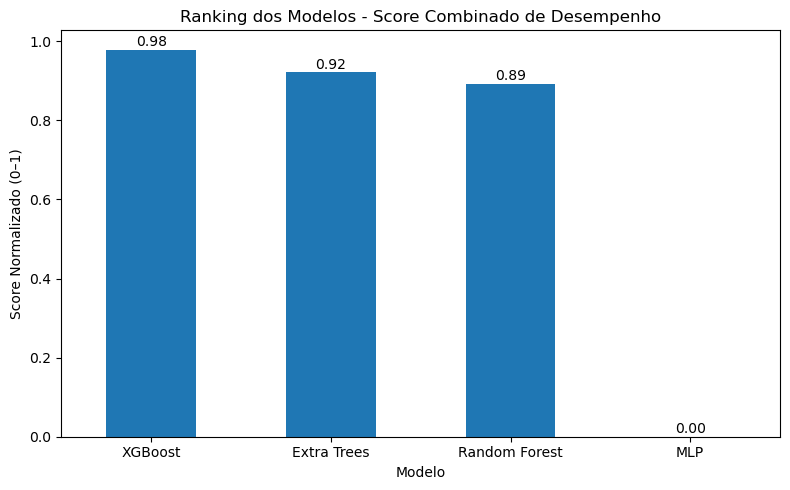

In [51]:
# Ranking global dos modelos



results = pd.DataFrame({
    "Model": ["Random Forest", "Extra Trees", "XGBoost", "MLP"],
    "MAE Global": [0.006042, 0.004908, 0.005814, 0.015443],
    "MSE Global": [0.001104, 0.000889, 0.000880, 0.002468],
    "RMSE Global": [0.033232, 0.029817, 0.029662, 0.049677],
    "R2": [-1.446356, -0.969344, -0.948985, -4.466488],
    "MAE Taxa > 0": [0.011739, 0.012025, 0.011512, 0.014559],
    "RMSE Taxa > 0": [0.051736, 0.052050, 0.051782, 0.052833]
})

results.set_index("Model", inplace=True)

norm = results.copy()

error_cols = [
    "MAE Global",
    "MSE Global",
    "RMSE Global",
    "MAE Taxa > 0",
    "RMSE Taxa > 0"
]

for col in error_cols:
    norm[col] = (results[col].max() - results[col]) / (
        results[col].max() - results[col].min()
    )

norm["R2"] = (results["R2"] - results["R2"].min()) / (
    results["R2"].max() - results["R2"].min()
)

norm["Final Score"] = norm.mean(axis=1)

norm = norm.sort_values(by="Final Score", ascending=False)

print("\n=== Final Model Ranking ===")
print(norm["Final Score"])

plt.figure(figsize=(8, 5))
norm["Final Score"].plot(kind="bar")

plt.title("Ranking dos Modelos - Score Combinado de Desempenho")
plt.ylabel("Score Normalizado (0–1)")
plt.xlabel("Modelo")
plt.xticks(rotation=0)

for i, v in enumerate(norm["Final Score"]):
    plt.text(i, v + 0.01, f"{v:.2f}", ha="center")

plt.tight_layout()
plt.show()

<p style="font-size:20px; line-height:1.6em; color: #333;">
De forma a comparar globalmente os modelos desenvolvidos, foi calculado um score agregado com base na normalização das métricas de avaliação: MAE, MSE, RMSE, R², MAE para os casos com taxa de reprovação positiva e RMSE para os casos com taxa de reprovação positiva. Após a normalização, foi calculada a média simples das métricas para cada modelo, obtendo-se um score final entre 0 e 1.
<p style="font-size:20px; line-height:1.6em; color: #333;">
Os resultados demonstram que o XGBoost apresentou o melhor desempenho global, com um score de <b>0,98</b>, seguido pelo Extra Trees, com <b>0,92</b>, e pelo Random Forest, com <b>0,89</b>. Embora os três modelos baseados em árvores tenham apresentado desempenhos relativamente próximos, o XGBoost revelou o melhor equilíbrio entre as métricas globais e o desempenho nos casos com taxa de reprovação positiva. Assim, este modelo foi selecionado para a fase seguinte de otimização.


=== Random Forest Regression Summary - Sem Oversampling ===
MAE Global        : 0.005836
MSE Global        : 0.000724
RMSE Global       : 0.026912
R² Global         : -0.604262
MAE Taxa > 0      : 0.011844
RMSE Taxa > 0     : 0.051887


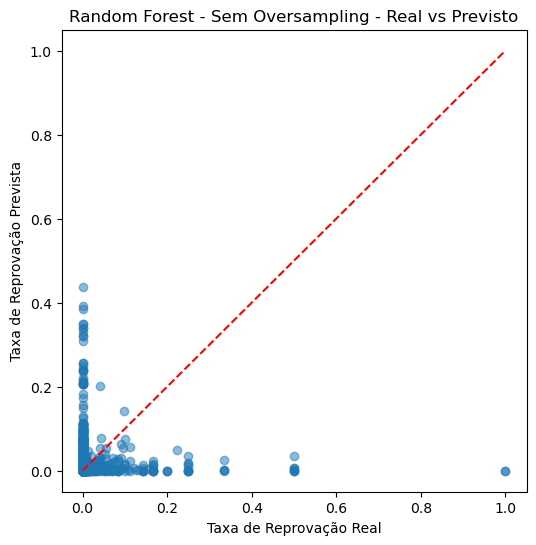

In [52]:
# RANDOM FOREST REGRESSOR - SEM OVERSAMPLING

# 1. Definir features

selected_features = X_train.columns.tolist()

X_train_sel = X_train[selected_features].copy()
X_test_sel = X_test[selected_features].copy()

y_train_aligned = y_train.copy()
y_test_aligned = y_test.copy()


# 2. Definir tipos de colunas

numeric_cols = X_train_sel.select_dtypes(
    include=["int64", "float64", "int32", "float32"]
).columns.tolist()

onehot_cols = X_train_sel.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()


# 3. Pipelines por tipo de variável

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

onehot_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", drop="first"))
])


# 4. Preprocessor

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_cols),
    ("oh", onehot_pipeline, onehot_cols)
])


# 5. Pipeline final com Random Forest

model_rf_no_over = Pipeline([
    ("prep", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ))
])


# 6. Treinar modelo

model_rf_no_over.fit(X_train_sel, y_train_aligned)


# 7. Previsões

y_pred_rf_no_over = model_rf_no_over.predict(X_test_sel)

# Evitar previsões negativas
y_pred_rf_no_over = np.maximum(y_pred_rf_no_over, 0)


# 8. Métricas globais e para casos com taxa > 0

mae = mean_absolute_error(y_test_aligned, y_pred_rf_no_over)
mse = mean_squared_error(y_test_aligned, y_pred_rf_no_over)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_aligned, y_pred_rf_no_over)

mask_pos = y_test_aligned > 0

mae_pos = mean_absolute_error(
    y_test_aligned[mask_pos],
    y_pred_rf_no_over[mask_pos]
)

rmse_pos = np.sqrt(mean_squared_error(
    y_test_aligned[mask_pos],
    y_pred_rf_no_over[mask_pos]
))

print("\n=== Random Forest Regression Summary - Sem Oversampling ===")
print(f"MAE Global        : {mae:.6f}")
print(f"MSE Global        : {mse:.6f}")
print(f"RMSE Global       : {rmse:.6f}")
print(f"R² Global         : {r2:.6f}")
print(f"MAE Taxa > 0      : {mae_pos:.6f}")
print(f"RMSE Taxa > 0     : {rmse_pos:.6f}")


# 9. Predicted vs Actual

plt.figure(figsize=(6,6))

plt.scatter(
    y_test_aligned,
    y_pred_rf_no_over,
    alpha=0.5
)

plt.plot(
    [y_test_aligned.min(), y_test_aligned.max()],
    [y_test_aligned.min(), y_test_aligned.max()],
    'r--'
)

plt.xlabel("Taxa de Reprovação Real")
plt.ylabel("Taxa de Reprovação Prevista")
plt.title("Random Forest - Sem Oversampling - Real vs Previsto")

plt.show()


=== Extra Trees Regression Summary - Sem Oversampling ===
MAE Global        : 0.004629
MSE Global        : 0.000848
RMSE Global       : 0.029116
R² Global         : -0.877832
MAE Taxa > 0      : 0.012134
RMSE Taxa > 0     : 0.052370


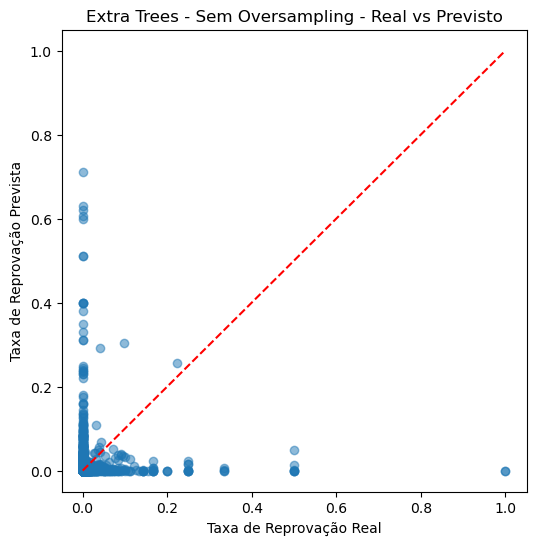

In [53]:
# EXTRA TREES REGRESSOR - SEM OVERSAMPLING

from sklearn.ensemble import ExtraTreesRegressor


# 1. Definir features

selected_features = X_train.columns.tolist()

X_train_sel = X_train[selected_features].copy()
X_test_sel = X_test[selected_features].copy()

y_train_aligned = y_train.copy()
y_test_aligned = y_test.copy()


# 2. Definir tipos de colunas

numeric_cols = X_train_sel.select_dtypes(
    include=["int64", "float64", "int32", "float32"]
).columns.tolist()

onehot_cols = X_train_sel.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()


# 3. Pipelines por tipo de variável

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

onehot_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", drop="first"))
])


# 4. Preprocessor

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_cols),
    ("oh", onehot_pipeline, onehot_cols)
])


# 5. Pipeline final com Extra Trees

model_et_no_over = Pipeline([
    ("prep", preprocessor),
    ("model", ExtraTreesRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ))
])


# 6. Treinar modelo

model_et_no_over.fit(X_train_sel, y_train_aligned)


# 7. Previsões

y_pred_et_no_over = model_et_no_over.predict(X_test_sel)

# Evitar previsões negativas
y_pred_et_no_over = np.maximum(y_pred_et_no_over, 0)


# 8. Métricas

mae = mean_absolute_error(y_test_aligned, y_pred_et_no_over)
mse = mean_squared_error(y_test_aligned, y_pred_et_no_over)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_aligned, y_pred_et_no_over)

mask_pos = y_test_aligned > 0

mae_pos = mean_absolute_error(
    y_test_aligned[mask_pos],
    y_pred_et_no_over[mask_pos]
)

rmse_pos = np.sqrt(mean_squared_error(
    y_test_aligned[mask_pos],
    y_pred_et_no_over[mask_pos]
))

print("\n=== Extra Trees Regression Summary - Sem Oversampling ===")
print(f"MAE Global        : {mae:.6f}")
print(f"MSE Global        : {mse:.6f}")
print(f"RMSE Global       : {rmse:.6f}")
print(f"R² Global         : {r2:.6f}")
print(f"MAE Taxa > 0      : {mae_pos:.6f}")
print(f"RMSE Taxa > 0     : {rmse_pos:.6f}")


# 9. Predicted vs Actual

plt.figure(figsize=(6,6))

plt.scatter(
    y_test_aligned,
    y_pred_et_no_over,
    alpha=0.5
)

plt.plot(
    [y_test_aligned.min(), y_test_aligned.max()],
    [y_test_aligned.min(), y_test_aligned.max()],
    'r--'
)

plt.xlabel("Taxa de Reprovação Real")
plt.ylabel("Taxa de Reprovação Prevista")
plt.title("Extra Trees - Sem Oversampling - Real vs Previsto")

plt.show()


=== XGBoost Regression Summary - Sem Oversampling ===
MAE Global        : 0.004536
MSE Global        : 0.000670
RMSE Global       : 0.025876
R² Global         : -0.483211
MAE Taxa > 0      : 0.011889
RMSE Taxa > 0     : 0.051583


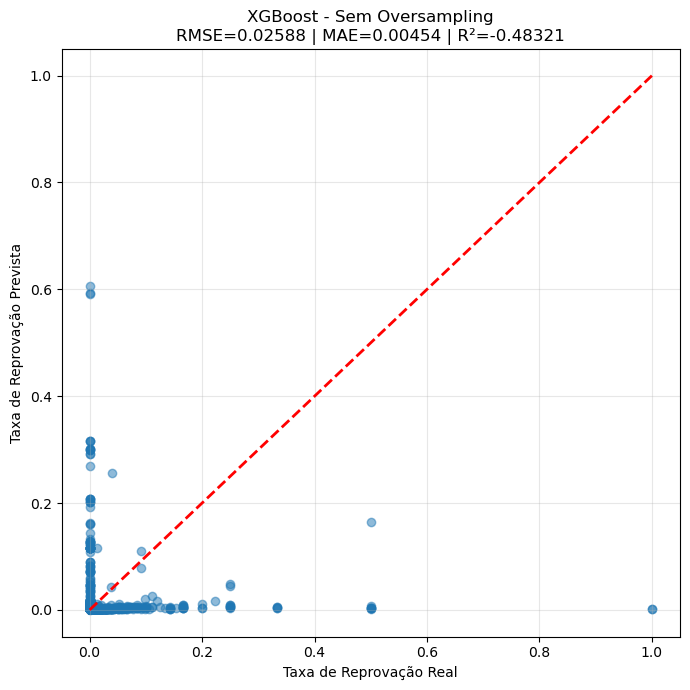

In [54]:
# XGBOOST REGRESSOR - SEM OVERSAMPLING

from xgboost import XGBRegressor


# 1. Definir features

selected_features = X_train.columns.tolist()

X_train_sel = X_train[selected_features].copy()
X_test_sel = X_test[selected_features].copy()

y_train_aligned = y_train.copy()
y_test_aligned = y_test.copy()


# 2. Definir tipos de colunas

numeric_cols = X_train_sel.select_dtypes(
    include=["int64", "float64", "int32", "float32"]
).columns.tolist()

onehot_cols = X_train_sel.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()


# 3. Pipelines por tipo de variável

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

onehot_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", drop="first"))
])


# 4. Preprocessor

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_cols),
    ("oh", onehot_pipeline, onehot_cols)
])


# 5. Pipeline final com XGBoost

model_xgb_no_over = Pipeline([
    ("prep", preprocessor),
    ("model", XGBRegressor(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    ))
])


# 6. Treinar modelo

model_xgb_no_over.fit(X_train_sel, y_train_aligned)


# 7. Previsões

y_pred_xgb_no_over = model_xgb_no_over.predict(X_test_sel)

# Evitar previsões negativas
y_pred_xgb_no_over = np.maximum(y_pred_xgb_no_over, 0)


# 8. Métricas

mae = mean_absolute_error(y_test_aligned, y_pred_xgb_no_over)
mse = mean_squared_error(y_test_aligned, y_pred_xgb_no_over)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_aligned, y_pred_xgb_no_over)

mask_pos = y_test_aligned > 0

mae_pos = mean_absolute_error(
    y_test_aligned[mask_pos],
    y_pred_xgb_no_over[mask_pos]
)

rmse_pos = np.sqrt(
    mean_squared_error(
        y_test_aligned[mask_pos],
        y_pred_xgb_no_over[mask_pos]
    )
)


# Mostrar métricas

print("\n=== XGBoost Regression Summary - Sem Oversampling ===")
print(f"MAE Global        : {mae:.6f}")
print(f"MSE Global        : {mse:.6f}")
print(f"RMSE Global       : {rmse:.6f}")
print(f"R² Global         : {r2:.6f}")
print(f"MAE Taxa > 0      : {mae_pos:.6f}")
print(f"RMSE Taxa > 0     : {rmse_pos:.6f}")


# 9. Predicted vs Actual

plt.close("all")

plt.figure(figsize=(7,7))

plt.scatter(
    y_test_aligned,
    y_pred_xgb_no_over,
    alpha=0.5
)

plt.plot(
    [y_test_aligned.min(), y_test_aligned.max()],
    [y_test_aligned.min(), y_test_aligned.max()],
    "r--",
    linewidth=2
)

plt.xlabel("Taxa de Reprovação Real")
plt.ylabel("Taxa de Reprovação Prevista")

plt.title(
    "XGBoost - Sem Oversampling\n"
    f"RMSE={rmse:.5f} | MAE={mae:.5f} | R²={r2:.5f}"
)

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


=== MLP Regression Summary - Sem Oversampling ===
MAE Global        : 0.008735
MSE Global        : 0.000584
RMSE Global       : 0.024176
R² Global         : -0.294669
MAE Taxa > 0      : 0.012903
RMSE Taxa > 0     : 0.050440


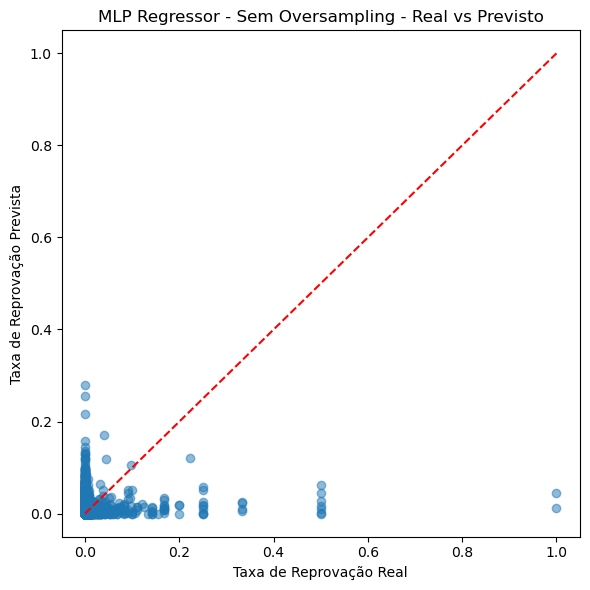

In [55]:
# MLP REGRESSOR - SEM OVERSAMPLING

from sklearn.neural_network import MLPRegressor
import warnings
warnings.filterwarnings("ignore", category=UserWarning)


# 1. Definir features

selected_features = X_train.columns.tolist()

X_train_sel = X_train[selected_features].copy()
X_test_sel = X_test[selected_features].copy()

y_train_aligned = y_train.copy()
y_test_aligned = y_test.copy()


# 2. Definir tipos de colunas

numeric_cols = X_train_sel.select_dtypes(
    include=["int64", "float64", "int32", "float32"]
).columns.tolist()

onehot_cols = X_train_sel.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()


# 3. Pipelines por tipo de variável

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

onehot_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", drop="first"))
])


# 4. Preprocessor

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_cols),
    ("oh", onehot_pipeline, onehot_cols)
])


# 5. Pipeline final com MLP Regressor

model_mlp_no_over = Pipeline([
    ("prep", preprocessor),
    ("model", MLPRegressor(
        hidden_layer_sizes=(64, 32),
        activation="relu",
        solver="adam",
        alpha=0.0001,
        learning_rate_init=0.001,
        max_iter=300,
        early_stopping=True,
        random_state=42
    ))
])


# 6. Treinar modelo

model_mlp_no_over.fit(X_train_sel, y_train_aligned)


# 7. Previsões

y_pred_mlp_no_over = model_mlp_no_over.predict(X_test_sel)

# Evitar previsões negativas
y_pred_mlp_no_over = np.maximum(y_pred_mlp_no_over, 0)


# 8. Métricas

mae = mean_absolute_error(y_test_aligned, y_pred_mlp_no_over)
mse = mean_squared_error(y_test_aligned, y_pred_mlp_no_over)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_aligned, y_pred_mlp_no_over)

mask_pos = y_test_aligned > 0

mae_pos = mean_absolute_error(
    y_test_aligned[mask_pos],
    y_pred_mlp_no_over[mask_pos]
)

rmse_pos = np.sqrt(mean_squared_error(
    y_test_aligned[mask_pos],
    y_pred_mlp_no_over[mask_pos]
))

print("\n=== MLP Regression Summary - Sem Oversampling ===")
print(f"MAE Global        : {mae:.6f}")
print(f"MSE Global        : {mse:.6f}")
print(f"RMSE Global       : {rmse:.6f}")
print(f"R² Global         : {r2:.6f}")
print(f"MAE Taxa > 0      : {mae_pos:.6f}")
print(f"RMSE Taxa > 0     : {rmse_pos:.6f}")


# 9. Predicted vs Actual

plt.close("all")

plt.figure(figsize=(6,6))

plt.scatter(
    y_test_aligned,
    y_pred_mlp_no_over,
    alpha=0.5
)

plt.plot(
    [y_test_aligned.min(), y_test_aligned.max()],
    [y_test_aligned.min(), y_test_aligned.max()],
    'r--'
)

plt.xlabel("Taxa de Reprovação Real")
plt.ylabel("Taxa de Reprovação Prevista")
plt.title("MLP Regressor - Sem Oversampling - Real vs Previsto")

plt.tight_layout()
plt.show()

In [57]:
# Comparação dos modelos com e sem oversampling - métricas atualizadas

comparison_over = pd.DataFrame({
    "Modelo": [
        "Random Forest", "Random Forest",
        "Extra Trees", "Extra Trees",
        "XGBoost", "XGBoost",
        "MLP", "MLP"
    ],
    "Oversampling": [
        "Com", "Sem",
        "Com", "Sem",
        "Com", "Sem",
        "Com", "Sem"
    ],
    "MAE Global": [
        0.006042, 0.005836,
        0.004908, 0.004629,
        0.005814, 0.004536,
        0.015443, 0.008735
    ],
    "MSE Global": [
        0.001104, 0.000724,
        0.000889, 0.000848,
        0.000880, 0.000670,
        0.002468, 0.000584
    ],
    "RMSE Global": [
        0.033232, 0.026912,
        0.029817, 0.029116,
        0.029662, 0.025876,
        0.049677, 0.024176
    ],
    "R2": [
        -1.446356, -0.604216,
        -0.969344, -0.877832,
        -0.948985, -0.483211,
        -4.466488, -0.294669
    ],
    "MAE Taxa > 0": [
        0.011739, 0.011844,
        0.012025, 0.012134,
        0.011512, 0.011889,
        0.014559, 0.012903
    ],
    "RMSE Taxa > 0": [
        0.051736, 0.051887,
        0.052050, 0.052370,
        0.051782, 0.051583,
        0.052833, 0.050440
    ]
})

# Critério de decisão:
# Como queremos avaliar o compromisso entre desempenho global e desempenho nos casos positivos,
# selecionamos a melhor configuração por modelo com base no menor RMSE Global.
# Se quiseres priorizar apenas casos positivos, troca para "MAE Taxa > 0".

best_by_model = (
    comparison_over
    .sort_values(by=["Modelo", "RMSE Global"], ascending=[True, True])
    .groupby("Modelo")
    .first()
    .reset_index()
)

best_by_model = best_by_model[[
    "Modelo",
    "Oversampling",
    "MAE Global",
    "MSE Global",
    "RMSE Global",
    "R2",
    "MAE Taxa > 0",
    "RMSE Taxa > 0"
]]

print("=== Comparação Completa: Com vs Sem Oversampling ===")
display(comparison_over.round(6))

print("=== Melhor Configuração por Modelo ===")
display(best_by_model.round(6))

=== Comparação Completa: Com vs Sem Oversampling ===


=== Melhor Configuração por Modelo ===



=== XGBoost (Top Features) Summary ===
MAE Global        : 0.005735
MSE Global        : 0.000809
RMSE Global       : 0.028444
R² Global         : -0.792230
MAE Taxa > 0      : 0.011507
RMSE Taxa > 0     : 0.051999


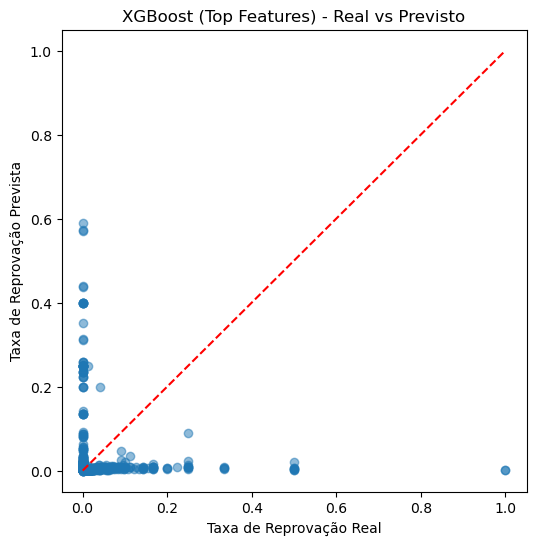

In [59]:
# XGBOOST REGRESSOR - TOP Feature Importance

from xgboost import XGBRegressor


   

# 2. Definir features mais importantes

selected_features = [
    "marca",
    "abatidos",
    "data",
    "preco_kg",
    "cabecas_normais",
    "mes",
    "num_species_mes"
]

X_train_sel = X_train_over[selected_features].copy()
X_test_sel = X_test[selected_features].copy()

y_train_aligned = y_train_over.copy()
y_test_aligned = y_test.copy()


# 3. Definir tipos de colunas

numeric_cols = X_train_sel.select_dtypes(
    include=["int64", "float64", "int32", "float32"]
).columns.tolist()

onehot_cols = X_train_sel.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()


# 4. Pipelines

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

onehot_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(
        handle_unknown="ignore",
        drop="first"
    ))
])


# 5. Preprocessor

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_cols),
    ("oh", onehot_pipeline, onehot_cols)
])


# 6. Modelo

model_xgb_top = Pipeline([
    ("prep", preprocessor),
    ("model", XGBRegressor(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    ))
])


# 7. Treinar

model_xgb_top.fit(
    X_train_sel,
    y_train_aligned
)


# 8. Previsões

y_pred_xgb_top = model_xgb_top.predict(
    X_test_sel
)

y_pred_xgb_top = np.maximum(
    y_pred_xgb_top,
    0
)


# 9. Métricas

mae = mean_absolute_error(
    y_test_aligned,
    y_pred_xgb_top
)

mse = mean_squared_error(
    y_test_aligned,
    y_pred_xgb_top
)

rmse = np.sqrt(mse)

r2 = r2_score(
    y_test_aligned,
    y_pred_xgb_top
)

mask_pos = y_test_aligned > 0

mae_pos = mean_absolute_error(
    y_test_aligned[mask_pos],
    y_pred_xgb_top[mask_pos]
)

rmse_pos = np.sqrt(
    mean_squared_error(
        y_test_aligned[mask_pos],
        y_pred_xgb_top[mask_pos]
    )
)


print("\n=== XGBoost (Top Features) Summary ===")
print(f"MAE Global        : {mae:.6f}")
print(f"MSE Global        : {mse:.6f}")
print(f"RMSE Global       : {rmse:.6f}")
print(f"R² Global         : {r2:.6f}")
print(f"MAE Taxa > 0      : {mae_pos:.6f}")
print(f"RMSE Taxa > 0     : {rmse_pos:.6f}")


# 10. Gráfico

plt.figure(figsize=(6,6))

plt.scatter(
    y_test_aligned,
    y_pred_xgb_top,
    alpha=0.5
)

plt.plot(
    [y_test_aligned.min(), y_test_aligned.max()],
    [y_test_aligned.min(), y_test_aligned.max()],
    'r--'
)

plt.xlabel("Taxa de Reprovação Real")
plt.ylabel("Taxa de Reprovação Prevista")
plt.title("XGBoost (Top Features) - Real vs Previsto")

plt.show()

In [60]:
# Comparação XGBoost Completo vs XGBoost Top Features

comparison_xgb = pd.DataFrame({
    "Modelo": [
        "XGBoost Completo",
        "XGBoost Top Features"
    ],
    "MAE Global": [
        0.004536,
        0.005735
    ],
    "MSE Global": [
        0.000670,
        0.000809
    ],
    "RMSE Global": [
        0.025876,
        0.028444
    ],
    "R²": [
        -0.483211,
        -0.792230
    ],
    "MAE Taxa > 0": [
        0.011889,
        0.011507
    ],
    "RMSE Taxa > 0": [
        0.051583,
        0.051999
    ]
})

display(comparison_xgb.round(6))

<p style="font-size:20px; line-height:1.6em; color: #333;">
Com o objetivo de avaliar o impacto da seleção de variáveis no desempenho preditivo, foi realizada uma comparação entre o modelo XGBoost treinado com o conjunto completo de features e uma versão alternativa treinada apenas com as variáveis identificadas como mais relevantes através da análise de Feature Importance.
<p style="font-size:20px; line-height:1.6em; color: #333;">
Os resultados demonstram que o modelo completo apresentou melhor desempenho na maioria das métricas avaliadas, nomeadamente MAE Global, MSE Global, RMSE Global, coeficiente de determinação (R²) e RMSE para os casos com taxa de reprovação superior a zero. Embora o modelo com Top Features tenha obtido um MAE ligeiramente inferior nos casos positivos, verificou-se uma degradação das restantes métricas, indicando uma menor capacidade de generalização.
<p style="font-size:20px; line-height:1.6em; color: #333;">
Ainda assim, concluiu-se que a utilização do conjunto completo de variáveis proporciona um melhor equilíbrio entre desempenho global e capacidade preditiva, tendo o modelo XGBoost com o conjunto completo de features sido selecionado para a fase final de análise e interpretação dos resultados.



# 4. Otimização do modelo

In [61]:
# Criação de Features Logarítmicas
# abatidos e cabecas_normais

X_train_log = X_train.copy()
X_test_log = X_test.copy()

X_train_log["abatidos_log"] = np.log1p(X_train_log["abatidos"])
X_test_log["abatidos_log"] = np.log1p(X_test_log["abatidos"])

X_train_log["cabecas_normais_log"] = np.log1p(X_train_log["cabecas_normais"])
X_test_log["cabecas_normais_log"] = np.log1p(X_test_log["cabecas_normais"])

print("Colunas adicionadas:")
print("abatidos_log")
print("cabecas_normais_log")

print("\nShape antes:")
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

print("\nShape depois:")
print("X_train_log:", X_train_log.shape)
print("X_test_log:", X_test_log.shape)

Colunas adicionadas:
abatidos_log
cabecas_normais_log

Shape antes:
X_train: (58497, 19)
X_test: (12874, 19)

Shape depois:
X_train_log: (58497, 21)
X_test_log: (12874, 21)



=== XGBoost Regression Summary - Log Features ===
MAE Global        : 0.005814
MSE Global        : 0.000880
RMSE Global       : 0.029662
R² Global         : -0.948985
MAE Taxa > 0      : 0.011512
RMSE Taxa > 0     : 0.051782


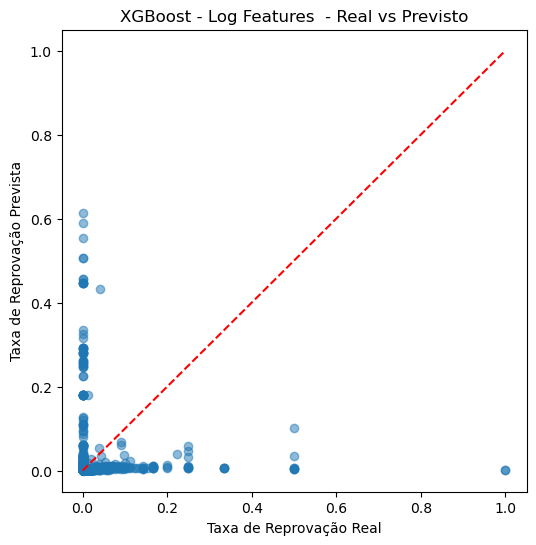

In [66]:
# XGBOOST REGRESSOR COM FEATURES LOGARÍTMICAS



# 1. Usar datasets com features logarítmicas

X_train_model = X_train_log.copy()
X_test_model = X_test_log.copy()



# 2. Definir features

selected_features = X_train_over.columns.tolist()

X_train_sel = X_train_over[selected_features].copy()
X_test_sel = X_test_model[selected_features].copy()

y_train_aligned = y_train_over.copy()
y_test_aligned = y_test.copy()


# 3. Definir tipos de colunas

numeric_cols = X_train_sel.select_dtypes(
    include=["int64", "float64", "int32", "float32"]
).columns.tolist()

onehot_cols = X_train_sel.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()


# 4. Pipelines por tipo de variável

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

onehot_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", drop="first"))
])


# 5. Preprocessor

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_cols),
    ("oh", onehot_pipeline, onehot_cols)
])


# 6. Pipeline final com XGBoost

model_xgb_log = Pipeline([
    ("prep", preprocessor),
    ("model", XGBRegressor(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    ))
])


# 7. Treinar modelo

model_xgb_log.fit(X_train_sel, y_train_aligned)


# 8. Previsões

y_pred_xgb_log = model_xgb_log.predict(X_test_sel)

# Evitar previsões negativas
y_pred_xgb_log = np.maximum(y_pred_xgb_log, 0)


# 9. Métricas

mae = mean_absolute_error(y_test_aligned, y_pred_xgb_log)
mse = mean_squared_error(y_test_aligned, y_pred_xgb_log)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_aligned, y_pred_xgb_log)

mask_pos = y_test_aligned > 0

mae_pos = mean_absolute_error(
    y_test_aligned[mask_pos],
    y_pred_xgb_log[mask_pos]
)

rmse_pos = np.sqrt(mean_squared_error(
    y_test_aligned[mask_pos],
    y_pred_xgb_log[mask_pos]
))

print("\n=== XGBoost Regression Summary - Log Features ===")
print(f"MAE Global        : {mae:.6f}")
print(f"MSE Global        : {mse:.6f}")
print(f"RMSE Global       : {rmse:.6f}")
print(f"R² Global         : {r2:.6f}")
print(f"MAE Taxa > 0      : {mae_pos:.6f}")
print(f"RMSE Taxa > 0     : {rmse_pos:.6f}")


# 10. Predicted vs Actual

plt.figure(figsize=(6,6))

plt.scatter(
    y_test_aligned,
    y_pred_xgb_log,
    alpha=0.5
)

plt.plot(
    [y_test_aligned.min(), y_test_aligned.max()],
    [y_test_aligned.min(), y_test_aligned.max()],
    'r--'
)

plt.xlabel("Taxa de Reprovação Real")
plt.ylabel("Taxa de Reprovação Prevista")
plt.title("XGBoost - Log Features  - Real vs Previsto")

plt.show()

In [67]:
# Comparação XGBoost original vs XGBoost com Features Logarítmicas


comparison_log = pd.DataFrame({
    "Modelo": [
        "XGBoost Original",
        "XGBoost + Log Features"
    ],
    "MAE Global": [
        0.004536,
        0.005814
    ],
    "MSE Global": [
        0.000670,
        0.000880
    ],
    "RMSE Global": [
        0.025876,
        0.029662
    ],
    "R²": [
        -0.483211,
        -0.948985
    ],
    "MAE Taxa > 0": [
        0.011889,
        0.011512
    ],
    "RMSE Taxa > 0": [
        0.051583,
        0.051782
    ]
})

display(comparison_log.round(6))

<p style="font-size:20px; line-height:1.6em; color: #333;">
Adicionalmente avaliada a introdução de transformações logarítmicas nas variáveis "abatidos" e "cabeças normais", devido à sua elevada assimetria observada na análise exploratória. Contudo, a comparação dos resultados demonstrou uma degradação das métricas globais e ausência de melhorias relevantes na previsão dos casos positivos. Assim, optou-se por manter as variáveis na sua escala original.

## Feature Selection


=== XGBoost Regression Summary - Top Features ===
MAE Global        : 0.004070
MSE Global        : 0.000567
RMSE Global       : 0.023815
R² Global         : -0.256280
MAE Taxa > 0      : 0.011926
RMSE Taxa > 0     : 0.051972


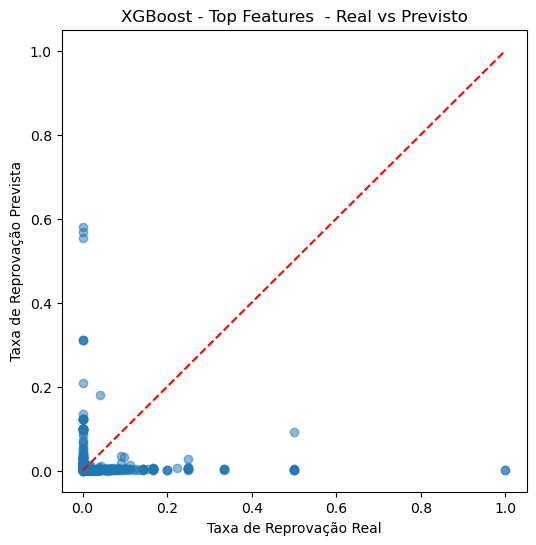

In [83]:
# XGBOOST REGRESSOR - TOP FEATURES


selected_features = [
    "marca",
    "abatidos",
    "data",
    "preco_kg",
    "cabecas_normais",
    "mes",
    "num_species_mes"
]



# 1. Definir dados de treino e teste

X_train_sel = X_train[selected_features].copy()
X_test_sel = X_test[selected_features].copy()

y_train_aligned = y_train.copy()
y_test_aligned = y_test.copy()

# 2. Definir tipos de colunas

numeric_cols = X_train_sel.select_dtypes(
    include=["int64", "float64", "int32", "float32"]
).columns.tolist()

onehot_cols = X_train_sel.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()


# 3. Pipelines por tipo de variável

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

onehot_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", drop="first"))
])


# 4. Preprocessor

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_cols),
    ("oh", onehot_pipeline, onehot_cols)
])


# 5. Pipeline final com XGBoost

model_xgb_top = Pipeline([
    ("prep", preprocessor),
    ("model", XGBRegressor(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    ))
])


# 6. Treinar modelo

model_xgb_top.fit(X_train_sel, y_train_aligned)


# 7. Previsões

y_pred_xgb_top = model_xgb_top.predict(X_test_sel)

y_pred_xgb_top = np.maximum(y_pred_xgb_top, 0)


# 8. Métricas

mae = mean_absolute_error(y_test_aligned, y_pred_xgb_top)
mse = mean_squared_error(y_test_aligned, y_pred_xgb_top)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_aligned, y_pred_xgb_top)

mask_pos = y_test_aligned > 0

mae_pos = mean_absolute_error(
    y_test_aligned[mask_pos],
    y_pred_xgb_top[mask_pos]
)

rmse_pos = np.sqrt(mean_squared_error(
    y_test_aligned[mask_pos],
    y_pred_xgb_top[mask_pos]
))

print("\n=== XGBoost Regression Summary - Top Features ===")
print(f"MAE Global        : {mae:.6f}")
print(f"MSE Global        : {mse:.6f}")
print(f"RMSE Global       : {rmse:.6f}")
print(f"R² Global         : {r2:.6f}")
print(f"MAE Taxa > 0      : {mae_pos:.6f}")
print(f"RMSE Taxa > 0     : {rmse_pos:.6f}")


# 9. Predicted vs Actual

plt.figure(figsize=(6,6))

plt.scatter(
    y_test_aligned,
    y_pred_xgb_top,
    alpha=0.5
)

plt.plot(
    [y_test_aligned.min(), y_test_aligned.max()],
    [y_test_aligned.min(), y_test_aligned.max()],
    "r--"
)

plt.xlabel("Taxa de Reprovação Real")
plt.ylabel("Taxa de Reprovação Prevista")
plt.title("XGBoost - Top Features  - Real vs Previsto")

plt.show()


=== XGBoost Regression Summary - Top Features:{selected_features}  ===
MAE Global        : 0.006472
MSE Global        : 0.000567
RMSE Global       : 0.023804
R² Global         : -0.255178
MAE Taxa > 0      : 0.012833
RMSE Taxa > 0     : 0.051649


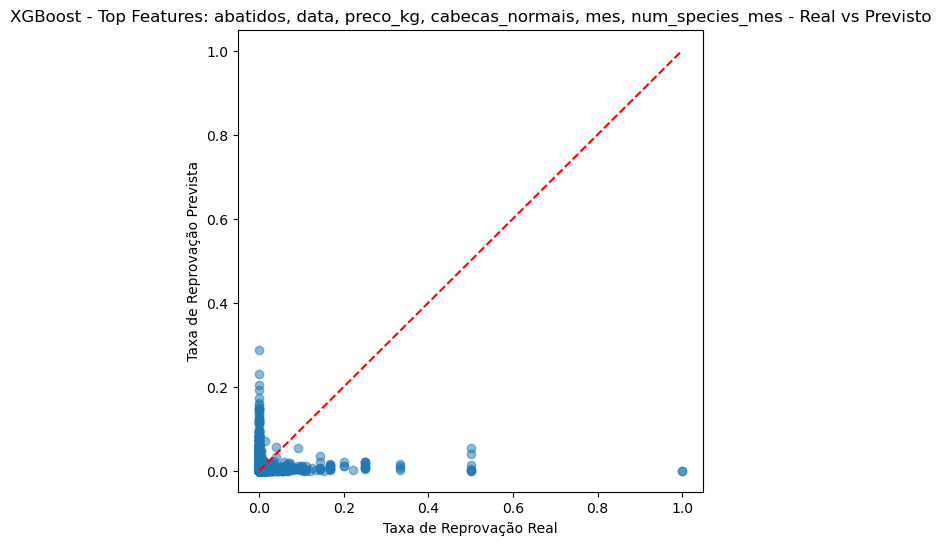

In [77]:
# XGBOOST REGRESSOR - TOP FEATURES: "abatidos","data","preco_kg","cabecas_normais","mes","num_species_mes"


selected_features = [
    "abatidos",
    "data",
    "preco_kg",
    "cabecas_normais",
    "mes",
    "num_species_mes"
]


# 1. Definir dados de treino e teste

X_train_sel = X_train[selected_features].copy()
X_test_sel = X_test[selected_features].copy()

y_train_aligned = y_train.copy()
y_test_aligned = y_test.copy()

# 2. Definir tipos de colunas

numeric_cols = X_train_sel.select_dtypes(
    include=["int64", "float64", "int32", "float32"]
).columns.tolist()

onehot_cols = X_train_sel.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()


# 3. Pipelines por tipo de variável

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

onehot_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", drop="first"))
])


# 4. Preprocessor

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_cols),
    ("oh", onehot_pipeline, onehot_cols)
])


# 5. Pipeline final com XGBoost

model_xgb_top = Pipeline([
    ("prep", preprocessor),
    ("model", XGBRegressor(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    ))
])


# 6. Treinar modelo

model_xgb_top.fit(X_train_sel, y_train_aligned)


# 7. Previsões

y_pred_xgb_top = model_xgb_top.predict(X_test_sel)

y_pred_xgb_top = np.maximum(y_pred_xgb_top, 0)


# 8. Métricas

mae = mean_absolute_error(y_test_aligned, y_pred_xgb_top)
mse = mean_squared_error(y_test_aligned, y_pred_xgb_top)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_aligned, y_pred_xgb_top)

mask_pos = y_test_aligned > 0

mae_pos = mean_absolute_error(
    y_test_aligned[mask_pos],
    y_pred_xgb_top[mask_pos]
)

rmse_pos = np.sqrt(mean_squared_error(
    y_test_aligned[mask_pos],
    y_pred_xgb_top[mask_pos]
))

print("\n=== XGBoost Regression Summary - Top Features:{selected_features}  ===")
print(f"MAE Global        : {mae:.6f}")
print(f"MSE Global        : {mse:.6f}")
print(f"RMSE Global       : {rmse:.6f}")
print(f"R² Global         : {r2:.6f}")
print(f"MAE Taxa > 0      : {mae_pos:.6f}")
print(f"RMSE Taxa > 0     : {rmse_pos:.6f}")


# 9. Predicted vs Actual

plt.figure(figsize=(6,6))

plt.scatter(
    y_test_aligned,
    y_pred_xgb_top,
    alpha=0.5
)

plt.plot(
    [y_test_aligned.min(), y_test_aligned.max()],
    [y_test_aligned.min(), y_test_aligned.max()],
    "r--"
)

plt.xlabel("Taxa de Reprovação Real")
plt.ylabel("Taxa de Reprovação Prevista")
plt.title("XGBoost - Top Features: abatidos, data, preco_kg, cabecas_normais, mes, num_species_mes - Real vs Previsto")

plt.show()


=== XGBoost Regression Summary - Top Features:{selected_features}  ===
MAE Global        : 0.009996
MSE Global        : 0.000748
RMSE Global       : 0.027357
R² Global         : -0.657794
MAE Taxa > 0      : 0.014775
RMSE Taxa > 0     : 0.051249


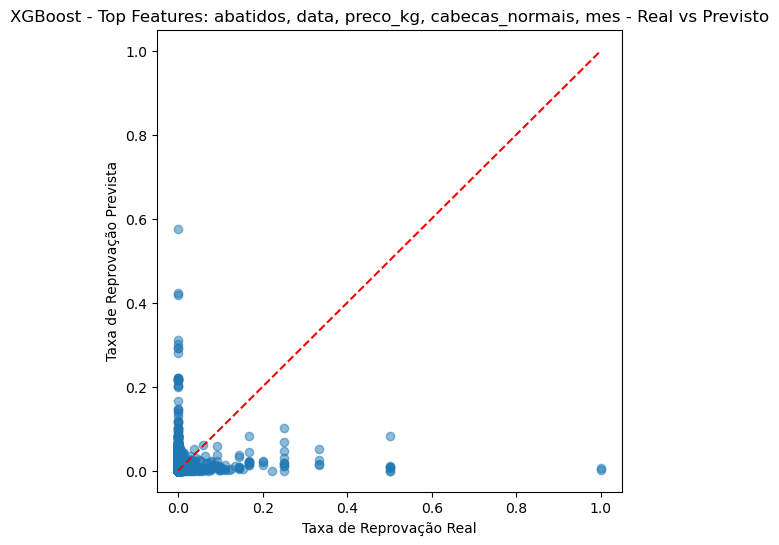

In [80]:
# XGBOOST REGRESSOR - TOP FEATURES: "abatidos","data","preco_kg","cabecas_normais","mes" 

selected_features = [
    "abatidos",
    "data",
    "preco_kg",
    "cabecas_normais",
    "mes",
]


# 1. Definir dados de treino e teste


X_train_sel = X_train[selected_features].copy()
X_test_sel = X_test[selected_features].copy()

y_train_aligned = y_train.copy()
y_test_aligned = y_test.copy()


# 2. Definir tipos de colunas

numeric_cols = X_train_sel.select_dtypes(
    include=["int64", "float64", "int32", "float32"]
).columns.tolist()

onehot_cols = X_train_sel.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()


# 3. Pipelines por tipo de variável

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

onehot_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", drop="first"))
])


# 4. Preprocessor

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_cols),
    ("oh", onehot_pipeline, onehot_cols)
])


# 5. Pipeline final com XGBoost

model_xgb_top = Pipeline([
    ("prep", preprocessor),
    ("model", XGBRegressor(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    ))
])


# 6. Treinar modelo

model_xgb_top.fit(X_train_sel, y_train_aligned)


# 7. Previsões

y_pred_xgb_top = model_xgb_top.predict(X_test_sel)

y_pred_xgb_top = np.maximum(y_pred_xgb_top, 0)


# 8. Métricas

mae = mean_absolute_error(y_test_aligned, y_pred_xgb_top)
mse = mean_squared_error(y_test_aligned, y_pred_xgb_top)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_aligned, y_pred_xgb_top)

mask_pos = y_test_aligned > 0

mae_pos = mean_absolute_error(
    y_test_aligned[mask_pos],
    y_pred_xgb_top[mask_pos]
)

rmse_pos = np.sqrt(mean_squared_error(
    y_test_aligned[mask_pos],
    y_pred_xgb_top[mask_pos]
))

print("\n=== XGBoost Regression Summary - Top Features:{selected_features}  ===")
print(f"MAE Global        : {mae:.6f}")
print(f"MSE Global        : {mse:.6f}")
print(f"RMSE Global       : {rmse:.6f}")
print(f"R² Global         : {r2:.6f}")
print(f"MAE Taxa > 0      : {mae_pos:.6f}")
print(f"RMSE Taxa > 0     : {rmse_pos:.6f}")


# 9. Predicted vs Actual

plt.figure(figsize=(6,6))

plt.scatter(
    y_test_aligned,
    y_pred_xgb_top,
    alpha=0.5
)

plt.plot(
    [y_test_aligned.min(), y_test_aligned.max()],
    [y_test_aligned.min(), y_test_aligned.max()],
    "r--"
)

plt.xlabel("Taxa de Reprovação Real")
plt.ylabel("Taxa de Reprovação Prevista")
plt.title("XGBoost - Top Features: abatidos, data, preco_kg, cabecas_normais, mes - Real vs Previsto")

plt.show()


=== XGBoost Regression Summary - Top Features:{selected_features}  ===
MAE Global        : 0.003982
MSE Global        : 0.000549
RMSE Global       : 0.023430
R² Global         : -0.216003
MAE Taxa > 0      : 0.012558
RMSE Taxa > 0     : 0.052150


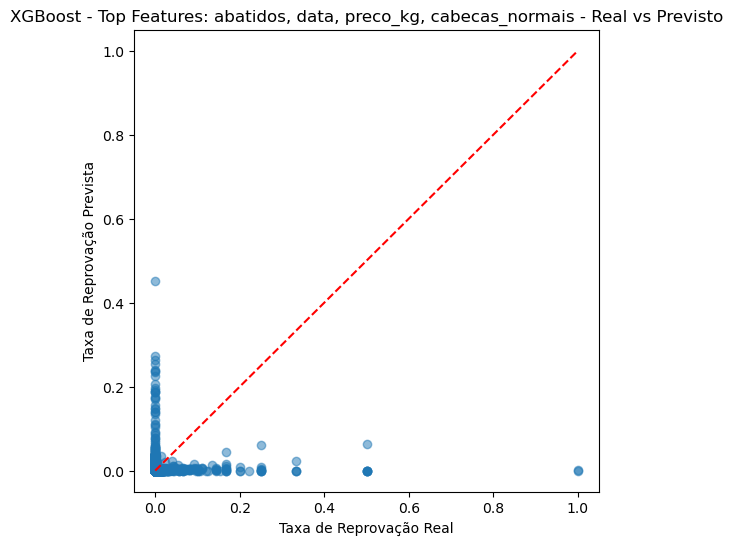

In [81]:
# XGBOOST REGRESSOR - TOP FEATURES: "abatidos","data","preco_kg","cabecas_normais" 


selected_features = [
    "abatidos",
    "data",
    "preco_kg",
    "cabecas_normais",
]



# 1. Definir dados de treino e teste

X_train_sel = X_train[selected_features].copy()
X_test_sel = X_test[selected_features].copy()

y_train_aligned = y_train.copy()
y_test_aligned = y_test.copy()



# 2. Definir tipos de colunas

numeric_cols = X_train_sel.select_dtypes(
    include=["int64", "float64", "int32", "float32"]
).columns.tolist()

onehot_cols = X_train_sel.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()


# 3. Pipelines por tipo de variável

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

onehot_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", drop="first"))
])


# 4. Preprocessor

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_cols),
    ("oh", onehot_pipeline, onehot_cols)
])


# 5. Pipeline final com XGBoost

model_xgb_top = Pipeline([
    ("prep", preprocessor),
    ("model", XGBRegressor(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    ))
])


# 6. Treinar modelo

model_xgb_top.fit(X_train_sel, y_train_aligned)


# 7. Previsões

y_pred_xgb_top = model_xgb_top.predict(X_test_sel)

y_pred_xgb_top = np.maximum(y_pred_xgb_top, 0)


# 8. Métricas

mae = mean_absolute_error(y_test_aligned, y_pred_xgb_top)
mse = mean_squared_error(y_test_aligned, y_pred_xgb_top)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_aligned, y_pred_xgb_top)

mask_pos = y_test_aligned > 0

mae_pos = mean_absolute_error(
    y_test_aligned[mask_pos],
    y_pred_xgb_top[mask_pos]
)

rmse_pos = np.sqrt(mean_squared_error(
    y_test_aligned[mask_pos],
    y_pred_xgb_top[mask_pos]
))

print("\n=== XGBoost Regression Summary - Top Features:{selected_features}  ===")
print(f"MAE Global        : {mae:.6f}")
print(f"MSE Global        : {mse:.6f}")
print(f"RMSE Global       : {rmse:.6f}")
print(f"R² Global         : {r2:.6f}")
print(f"MAE Taxa > 0      : {mae_pos:.6f}")
print(f"RMSE Taxa > 0     : {rmse_pos:.6f}")


# 9. Predicted vs Actual

plt.figure(figsize=(6,6))

plt.scatter(
    y_test_aligned,
    y_pred_xgb_top,
    alpha=0.5
)

plt.plot(
    [y_test_aligned.min(), y_test_aligned.max()],
    [y_test_aligned.min(), y_test_aligned.max()],
    "r--"
)

plt.xlabel("Taxa de Reprovação Real")
plt.ylabel("Taxa de Reprovação Prevista")
plt.title("XGBoost - Top Features: abatidos, data, preco_kg, cabecas_normais - Real vs Previsto")

plt.show()

In [82]:
# Comparação dos resultados da feature selection

feature_selection_results = pd.DataFrame({
    "Modelo": [
        "Todas as Features (19)",
        "Top 7",
        "Top 6 (Sem Marca)",
        "Top 5 (Sem Marca e Num_Species_Mes)",
        "Top 4 (Sem Marca, Num_Species_Mes e Mes)"
    ],

    "MAE Global": [
        0.004536,
        0.004070,
        0.006472,
        0.006996,
        0.003982
    ],

    "MSE Global": [
        0.000670,
        0.000567,
        0.000567,
        0.000748,
        0.000549
    ],

    "RMSE Global": [
        0.025876,
        0.023815,
        0.023804,
        0.027357,
        0.023430
    ],

    "R²": [
        -0.483211,
        -0.256208,
        -0.255178,
        -0.657794,
        -0.216003
    ],

    "MAE Taxa > 0": [
        0.011889,
        0.011926,
        0.012833,
        0.014775,
        0.012558
    ],

    "RMSE Taxa > 0": [
        0.051583,
        0.051972,
        0.051649,
        0.051249,
        0.052150
    ]
})

display(feature_selection_results.round(6))

<p style="font-size:20px; line-height:1.6em; color: #333;">
Foi realizada uma análise de feature selection com base na importância das variáveis obtida através do Random Forest. Nesta análise, foram testados diferentes subconjuntos de features, removendo progressivamente as variáveis menos relevantes. 
Os resultados demonstraram que a utilização de apenas quatro variáveis (abatidos, data, preco_kg e cabecas_normais) permitiu obter o melhor desempenho global, apresentando simultaneamente os menores erros (MAE, MSE e RMSE) e o melhor coeficiente de determinação (R²). Embora algumas configurações com mais variáveis tenham apresentado resultados ligeiramente superiores nas métricas específicas para os casos positivos, as diferenças observadas foram reduzidas. Assim, optou-se por selecionar o modelo com quatro variáveis, por apresentar o melhor equilíbrio entre desempenho preditivo e capacidade de generalização.
 Deste modo, este conjunto de features foi selecionado para a fase seguinte de otimização dos hiperparâmetros do modelo XGBoost.


## Hyperparameter Tunning

=== XGBoost - Best Params ===
{'model__subsample': 0.8, 'model__reg_lambda': 5, 'model__reg_alpha': 0.1, 'model__n_estimators': 300, 'model__min_child_weight': 10, 'model__max_depth': 2, 'model__learning_rate': 0.03, 'model__gamma': 0, 'model__colsample_bytree': 0.6}

Best CV RMSE: 0.0184

=== XGBoost - Test Metrics ===
MAE  : 0.0041
MSE  : 0.0004
RMSE : 0.0212
R²   : 0.0051
MAE Taxa > 0  : 0.0120
RMSE Taxa > 0 : 0.0520


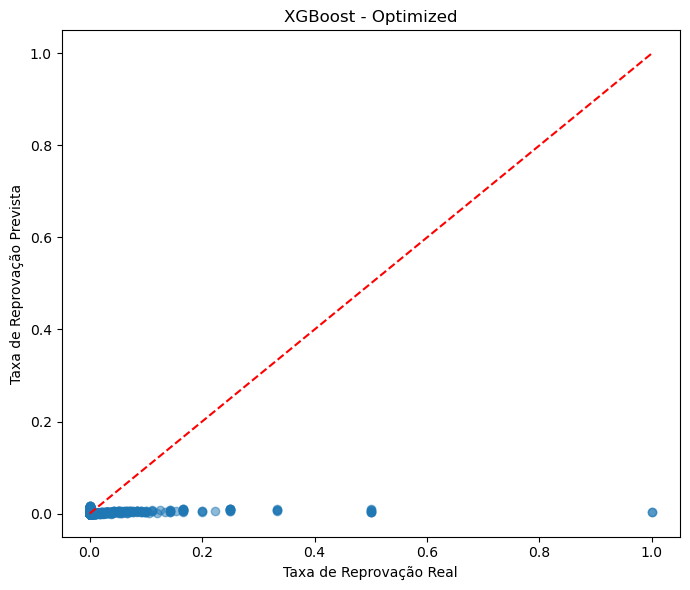

In [86]:

# XGBOOST TUNED - TOP 4 FEATURES 

import warnings
warnings.filterwarnings(
    "ignore",
    message="Found unknown categories in columns"
)



# 1. Definir features finais

selected_features = [
    "abatidos",
    "data",
    "preco_kg",
    "cabecas_normais"
]


# 2. Definir dados de treino e teste 

X_train_sel = X_train[selected_features].copy()
X_test_sel = X_test[selected_features].copy()

y_train_aligned = y_train.copy()
y_test_aligned = y_test.copy()

# 3. Definir colunas numéricas e categóricas

numeric_cols = X_train_sel.select_dtypes(
    include=["int64", "float64", "int32", "float32"]
).columns.tolist()

onehot_cols = X_train_sel.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()


# 4. Pipelines

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

onehot_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", drop="first"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_cols),
    ("oh", onehot_pipeline, onehot_cols)
])


# 5. Pipeline base XGBoost

xgb_pipeline = Pipeline([
    ("prep", preprocessor),
    ("model", XGBRegressor(
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    ))
])


# 6. Hiperparâmetros

param_dist = {
    "model__n_estimators": [100, 200, 300, 500],
    "model__max_depth": [2, 3, 4, 5, 6, 8],
    "model__learning_rate": [0.01, 0.03, 0.05, 0.1],
    "model__subsample": [0.6, 0.8, 1.0],
    "model__colsample_bytree": [0.6, 0.8, 1.0],
    "model__min_child_weight": [1, 3, 5, 10],
    "model__gamma": [0, 0.01, 0.05, 0.1],
    "model__reg_alpha": [0, 0.01, 0.1, 1],
    "model__reg_lambda": [1, 2, 5, 10]
}


# 7. Randomized Search

random_search = RandomizedSearchCV(
    estimator=xgb_pipeline,
    param_distributions=param_dist,
    n_iter=30,
    scoring="neg_root_mean_squared_error",
    cv=3,
    verbose=0,
    random_state=42,
    n_jobs=1
)
random_search.fit(X_train_sel, y_train_aligned)


# 8. Melhor modelo

best_xgb_model = random_search.best_estimator_


# 9. Previsões

y_pred_xgb_tuned = best_xgb_model.predict(X_test_sel)
y_pred_xgb_tuned = np.maximum(y_pred_xgb_tuned, 0)


# 10. Métricas

mae = mean_absolute_error(y_test_aligned, y_pred_xgb_tuned)
mse = mean_squared_error(y_test_aligned, y_pred_xgb_tuned)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_aligned, y_pred_xgb_tuned)

mask_pos = y_test_aligned > 0

mae_pos = mean_absolute_error(
    y_test_aligned[mask_pos],
    y_pred_xgb_tuned[mask_pos]
)

rmse_pos = np.sqrt(mean_squared_error(
    y_test_aligned[mask_pos],
    y_pred_xgb_tuned[mask_pos]
))


# 11. Output final

print("=== XGBoost - Best Params ===")
print(random_search.best_params_)

print(f"\nBest CV RMSE: {-random_search.best_score_:.4f}")

print("\n=== XGBoost - Test Metrics ===")
print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")
print(f"MAE Taxa > 0  : {mae_pos:.4f}")
print(f"RMSE Taxa > 0 : {rmse_pos:.4f}")


# 12. Gráfico

plt.figure(figsize=(7,6))

plt.scatter(
    y_test_aligned,
    y_pred_xgb_tuned,
    alpha=0.5
)

plt.plot(
    [y_test_aligned.min(), y_test_aligned.max()],
    [y_test_aligned.min(), y_test_aligned.max()],
    "r--"
)

plt.xlabel("Taxa de Reprovação Real")
plt.ylabel("Taxa de Reprovação Prevista")
plt.title("XGBoost - Optimized")

plt.tight_layout()
plt.show()

In [87]:
# Comparação XGBoost TOP 4 Features vs XGBoost TOP 4 Features Tuned

comparison_tuning = pd.DataFrame({
    "Configuração": [
        "XGBoost Base",
        "XGBoost Tuned"
    ],
    "MAE Global": [
        0.003982,
        0.004100
    ],
    "MSE Global": [
        0.000549,
        0.000400
    ],
    "RMSE Global": [
        0.023430,
        0.021200
    ],
    "R²": [
        -0.216003,
        -0.005100
    ],
    "MAE Taxa > 0": [
        0.012558,
        0.012000
    ],
    "RMSE Taxa > 0": [
        0.052150,
        0.052000
    ]
})

display(comparison_tuning.round(6))

<p style="font-size:20px; line-height:1.6em; color: #333;">
Foi realizada uma fase de otimização de hiperparâmetros através de Randomized SearchCV aplicada ao modelo XGBoost selecionado após a fase de feature selection. Os resultados demonstraram uma melhoria global do desempenho do modelo, verificando-se uma redução do RMSE Global, uma melhoria significativa do coeficiente de determinação (R²) e uma ligeira redução dos erros nos casos com taxa de reprovação positiva. Desta forma, a versão otimizada do XGBoost foi selecionada para continuar o processo de otimização

## Sample Weight


=== XGBoost Tuned - Top 4 Features + Sample Weight (10) ===
MAE Global        : 0.014998
MSE Global        : 0.000939
RMSE Global       : 0.030643
R² Global         : -1.080036
MAE Taxa > 0      : 0.009004
RMSE Taxa > 0     : 0.045945


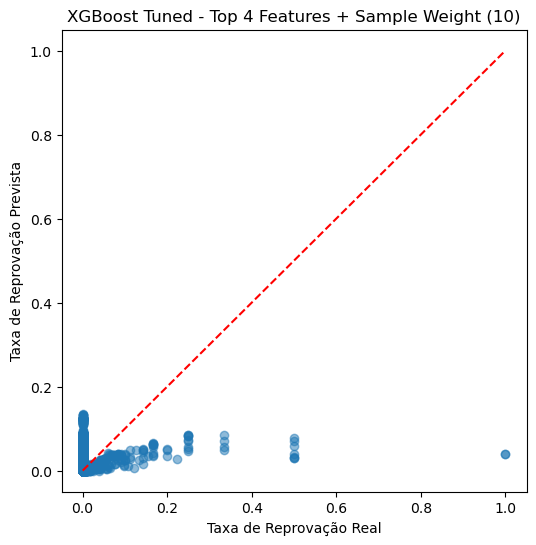

In [88]:
# XGBOOST TUNED - TOP 4 FEATURES + SAMPLE WEIGHT (10)

# 1. Definir features finais

selected_features = [
    "abatidos",
    "data",
    "preco_kg",
    "cabecas_normais"
]


# 2. Preparar dados de treino e teste

X_train_sel = X_train[selected_features].copy()
X_test_sel = X_test[selected_features].copy()

y_train_aligned = y_train.copy()
y_test_aligned = y_test.copy()


# 3. Criar sample weights
# Taxa = 0  -> peso 1
# Taxa > 0  -> peso 10

sample_weights = np.where(
    y_train_aligned > 0,
    10,
    1
)


# 4. Definir tipos de colunas

numeric_cols = X_train_sel.select_dtypes(
    include=["int64", "float64", "int32", "float32"]
).columns.tolist()

onehot_cols = X_train_sel.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()


# 5. Pipelines por tipo de variável

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

onehot_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", drop="first"))
])


# 6. Preprocessor

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_cols),
    ("oh", onehot_pipeline, onehot_cols)
])


# 7. Pipeline final com XGBoost Tuned
# Usar os melhores hiperparâmetros encontrados no RandomizedSearchCV

model_xgb_sw = Pipeline([
    ("prep", preprocessor),
    ("model", XGBRegressor(
        subsample=0.8,
        reg_lambda=5,
        reg_alpha=0.1,
        n_estimators=300,
        min_child_weight=10,
        max_depth=2,
        learning_rate=0.03,
        gamma=0,
        colsample_bytree=0.6,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    ))
])


# 8. Treinar modelo com sample weights

model_xgb_sw.fit(
    X_train_sel,
    y_train_aligned,
    model__sample_weight=sample_weights
)


# 9. Previsões

y_pred_xgb_sw = model_xgb_sw.predict(X_test_sel)

# Evitar previsões negativas
y_pred_xgb_sw = np.maximum(y_pred_xgb_sw, 0)


# 10. Métricas

mae = mean_absolute_error(y_test_aligned, y_pred_xgb_sw)
mse = mean_squared_error(y_test_aligned, y_pred_xgb_sw)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_aligned, y_pred_xgb_sw)

mask_pos = y_test_aligned > 0

mae_pos = mean_absolute_error(
    y_test_aligned[mask_pos],
    y_pred_xgb_sw[mask_pos]
)

rmse_pos = np.sqrt(mean_squared_error(
    y_test_aligned[mask_pos],
    y_pred_xgb_sw[mask_pos]
))


# 11. Output

print("\n=== XGBoost Tuned - Top 4 Features + Sample Weight (10) ===")
print(f"MAE Global        : {mae:.6f}")
print(f"MSE Global        : {mse:.6f}")
print(f"RMSE Global       : {rmse:.6f}")
print(f"R² Global         : {r2:.6f}")
print(f"MAE Taxa > 0      : {mae_pos:.6f}")
print(f"RMSE Taxa > 0     : {rmse_pos:.6f}")


# 12. Gráfico Real vs Previsto

plt.figure(figsize=(6, 6))

plt.scatter(
    y_test_aligned,
    y_pred_xgb_sw,
    alpha=0.5
)

plt.plot(
    [y_test_aligned.min(), y_test_aligned.max()],
    [y_test_aligned.min(), y_test_aligned.max()],
    "r--"
)

plt.xlabel("Taxa de Reprovação Real")
plt.ylabel("Taxa de Reprovação Prevista")
plt.title("XGBoost Tuned - Top 4 Features + Sample Weight (10)")

plt.show()


=== XGBoost Tuned - Top 4 Features + Sample Weight (5) ===
MAE Global        : 0.010266
MSE Global        : 0.000588
RMSE Global       : 0.024246
R² Global         : -0.302245
MAE Taxa > 0      : 0.010064
RMSE Taxa > 0     : 0.048728


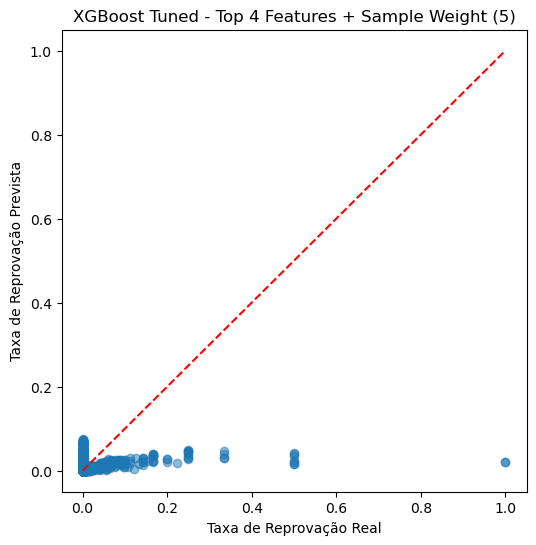

In [89]:
# XGBOOST TUNED - TOP 4 FEATURES + SAMPLE WEIGHT (5)

# 1. Definir features finais

selected_features = [
    "abatidos",
    "data",
    "preco_kg",
    "cabecas_normais"
]


# 2. Preparar dados de treino e teste

X_train_sel = X_train[selected_features].copy()
X_test_sel = X_test[selected_features].copy()

y_train_aligned = y_train.copy()
y_test_aligned = y_test.copy()


# 3. Criar sample weights
# Taxa = 0  -> peso 1
# Taxa > 0  -> peso 5

sample_weights = np.where(
    y_train_aligned > 0,
    5,
    1
)


# 4. Definir tipos de colunas

numeric_cols = X_train_sel.select_dtypes(
    include=["int64", "float64", "int32", "float32"]
).columns.tolist()

onehot_cols = X_train_sel.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()


# 5. Pipelines por tipo de variável

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

onehot_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", drop="first"))
])


# 6. Preprocessor

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_cols),
    ("oh", onehot_pipeline, onehot_cols)
])


# 7. Pipeline final com XGBoost Tuned
# Usar os melhores hiperparâmetros encontrados no RandomizedSearchCV

model_xgb_sw = Pipeline([
    ("prep", preprocessor),
    ("model", XGBRegressor(
        subsample=0.8,
        reg_lambda=5,
        reg_alpha=0.1,
        n_estimators=300,
        min_child_weight=10,
        max_depth=2,
        learning_rate=0.03,
        gamma=0,
        colsample_bytree=0.6,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    ))
])


# 8. Treinar modelo com sample weights

model_xgb_sw.fit(
    X_train_sel,
    y_train_aligned,
    model__sample_weight=sample_weights
)


# 9. Previsões

y_pred_xgb_sw = model_xgb_sw.predict(X_test_sel)

# Evitar previsões negativas
y_pred_xgb_sw = np.maximum(y_pred_xgb_sw, 0)


# 10. Métricas

mae = mean_absolute_error(y_test_aligned, y_pred_xgb_sw)
mse = mean_squared_error(y_test_aligned, y_pred_xgb_sw)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_aligned, y_pred_xgb_sw)

mask_pos = y_test_aligned > 0

mae_pos = mean_absolute_error(
    y_test_aligned[mask_pos],
    y_pred_xgb_sw[mask_pos]
)

rmse_pos = np.sqrt(mean_squared_error(
    y_test_aligned[mask_pos],
    y_pred_xgb_sw[mask_pos]
))


# 11. Output

print("\n=== XGBoost Tuned - Top 4 Features + Sample Weight (5) ===")
print(f"MAE Global        : {mae:.6f}")
print(f"MSE Global        : {mse:.6f}")
print(f"RMSE Global       : {rmse:.6f}")
print(f"R² Global         : {r2:.6f}")
print(f"MAE Taxa > 0      : {mae_pos:.6f}")
print(f"RMSE Taxa > 0     : {rmse_pos:.6f}")


# 12. Gráfico Real vs Previsto

plt.figure(figsize=(6, 6))

plt.scatter(
    y_test_aligned,
    y_pred_xgb_sw,
    alpha=0.5
)

plt.plot(
    [y_test_aligned.min(), y_test_aligned.max()],
    [y_test_aligned.min(), y_test_aligned.max()],
    "r--"
)

plt.xlabel("Taxa de Reprovação Real")
plt.ylabel("Taxa de Reprovação Prevista")
plt.title("XGBoost Tuned - Top 4 Features + Sample Weight (5)")

plt.show()


=== XGBoost Tuned - Top 4 Features + Sample Weight (3) ===
MAE Global        : 0.007380
MSE Global        : 0.000491
RMSE Global       : 0.022153
R² Global         : -0.087044
MAE Taxa > 0      : 0.010720
RMSE Taxa > 0     : 0.050271


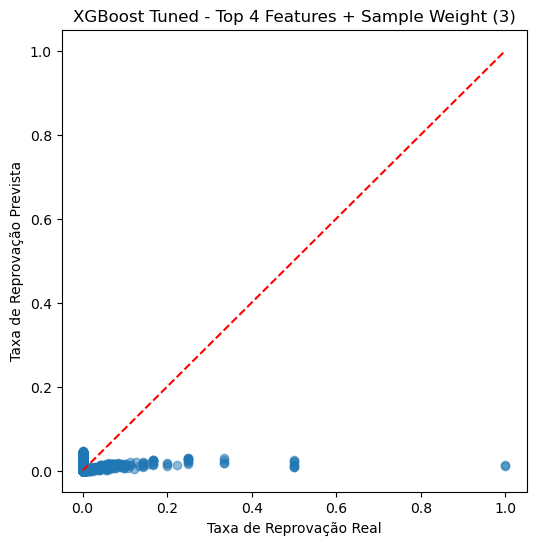

In [90]:
# XGBOOST TUNED - TOP 4 FEATURES + SAMPLE WEIGHT (3)

# 1. Definir features finais

selected_features = [
    "abatidos",
    "data",
    "preco_kg",
    "cabecas_normais"
]


# 2. Preparar dados de treino e teste

X_train_sel = X_train[selected_features].copy()
X_test_sel = X_test[selected_features].copy()

y_train_aligned = y_train.copy()
y_test_aligned = y_test.copy()


# 3. Criar sample weights
# Taxa = 0  -> peso 1
# Taxa > 0  -> peso 3

sample_weights = np.where(
    y_train_aligned > 0,
    3,
    1
)


# 4. Definir tipos de colunas

numeric_cols = X_train_sel.select_dtypes(
    include=["int64", "float64", "int32", "float32"]
).columns.tolist()

onehot_cols = X_train_sel.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()


# 5. Pipelines por tipo de variável

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

onehot_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", drop="first"))
])


# 6. Preprocessor

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_cols),
    ("oh", onehot_pipeline, onehot_cols)
])


# 7. Pipeline final com XGBoost Tuned
# Usar os melhores hiperparâmetros encontrados no RandomizedSearchCV

model_xgb_sw = Pipeline([
    ("prep", preprocessor),
    ("model", XGBRegressor(
        subsample=0.8,
        reg_lambda=5,
        reg_alpha=0.1,
        n_estimators=300,
        min_child_weight=10,
        max_depth=2,
        learning_rate=0.03,
        gamma=0,
        colsample_bytree=0.6,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    ))
])


# 8. Treinar modelo com sample weights

model_xgb_sw.fit(
    X_train_sel,
    y_train_aligned,
    model__sample_weight=sample_weights
)


# 9. Previsões

y_pred_xgb_sw = model_xgb_sw.predict(X_test_sel)

# Evitar previsões negativas
y_pred_xgb_sw = np.maximum(y_pred_xgb_sw, 0)


# 10. Métricas

mae = mean_absolute_error(y_test_aligned, y_pred_xgb_sw)
mse = mean_squared_error(y_test_aligned, y_pred_xgb_sw)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_aligned, y_pred_xgb_sw)

mask_pos = y_test_aligned > 0

mae_pos = mean_absolute_error(
    y_test_aligned[mask_pos],
    y_pred_xgb_sw[mask_pos]
)

rmse_pos = np.sqrt(mean_squared_error(
    y_test_aligned[mask_pos],
    y_pred_xgb_sw[mask_pos]
))


# 11. Output

print("\n=== XGBoost Tuned - Top 4 Features + Sample Weight (3) ===")
print(f"MAE Global        : {mae:.6f}")
print(f"MSE Global        : {mse:.6f}")
print(f"RMSE Global       : {rmse:.6f}")
print(f"R² Global         : {r2:.6f}")
print(f"MAE Taxa > 0      : {mae_pos:.6f}")
print(f"RMSE Taxa > 0     : {rmse_pos:.6f}")


# 12. Gráfico Real vs Previsto

plt.figure(figsize=(6, 6))

plt.scatter(
    y_test_aligned,
    y_pred_xgb_sw,
    alpha=0.5
)

plt.plot(
    [y_test_aligned.min(), y_test_aligned.max()],
    [y_test_aligned.min(), y_test_aligned.max()],
    "r--"
)

plt.xlabel("Taxa de Reprovação Real")
plt.ylabel("Taxa de Reprovação Prevista")
plt.title("XGBoost Tuned - Top 4 Features + Sample Weight (3)")

plt.show()

In [91]:
# Comparação XGBoost Tuned Top 4 Features vs Sample Weight (3, 5 e 10)

comparison_weights = pd.DataFrame({
    "Estratégia": [
        "XGBoost Tuned - Top 4 Features",
        "Sample Weight = 3",
        "Sample Weight = 5",
        "Sample Weight = 10"
    ],
    "MAE Global": [
        0.004100,
        0.007380,
        0.010266,
        0.014998
    ],
    "MSE Global": [
        0.000400,
        0.000491,
        0.000588,
        0.000939
    ],
    "RMSE Global": [
        0.021200,
        0.022153,
        0.024246,
        0.030643
    ],
    "R²": [
        -0.005100,
        -0.087044,
        -0.302245,
        -1.080036
    ],
    "MAE Taxa > 0": [
        0.012000,
        0.010720,
        0.010064,
        0.009004
    ],
    "RMSE Taxa > 0": [
        0.052000,
        0.050271,
        0.048728,
        0.045945
    ]
})

display(comparison_weights.round(6))

<p style="font-size:20px; line-height:1.6em; color: #333;">
Foi realizada uma análise comparativa entre o modelo XGBoost Tuned com Top 4 Features, sem ponderação adicional, e diferentes configurações de sample weights atribuídas aos casos com taxa de reprovação positiva. Os resultados demonstraram que o aumento do peso atribuído aos casos positivos conduziu a melhorias progressivas nas métricas específicas destes casos, nomeadamente no MAE e RMSE para taxas de reprovação superiores a zero. No entanto, estas melhorias foram acompanhadas por uma degradação gradual das métricas globais do modelo, em particular do MAE Global, RMSE Global e coeficiente de determinação (R²).
<p style="font-size:20px; line-height:1.6em; color: #333;">
Embora o peso 3 tenha apresentado o melhor compromisso entre desempenho global e melhoria nos casos positivos, o modelo XGBoost Tuned sem sample weights manteve o melhor desempenho global e a melhor capacidade de generalização. Assim, concluiu-se que a utilização de sample weights não compensava a perda de desempenho global, tendo sido mantida a versão otimizada do XGBoost sem ponderação adicional como configuração final.


## Oversampling


=== XGBoost Tuned - Top 4 Features + Oversampling 20% ===
MAE Global        : 0.004786
MSE Global        : 0.000461
RMSE Global       : 0.021481
R² Global         : -0.022136
MAE Taxa > 0      : 0.011438
RMSE Taxa > 0     : 0.051882


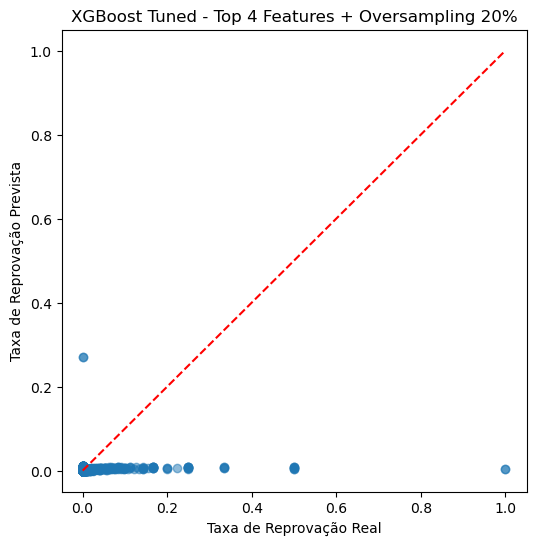

In [93]:
# XGBOOST TUNED - TOP 4 FEATURES + OVERSAMPLING 20%

from xgboost import XGBRegressor

# 1. Definir features finais

selected_features = [
    "abatidos",
    "data",
    "preco_kg",
    "cabecas_normais"
]


# 2. Aplicar oversampling apenas ao treino

X_train_over, y_train_over = smooth_oversample_regression(
    X_train[selected_features],
    y_train,
    positive_threshold=0,
    target_positive_ratio=0.2,
    noise_std=0.01,
    random_state=42
)


# 3. Definir dados de treino e teste

X_train_sel = X_train_over.copy()
X_test_sel = X_test[selected_features].copy()

y_train_aligned = y_train_over.copy()
y_test_aligned = y_test.copy()


# 4. Definir tipos de colunas

numeric_cols = X_train_sel.select_dtypes(
    include=["int64", "float64", "int32", "float32"]
).columns.tolist()

onehot_cols = X_train_sel.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()


# 5. Pipelines

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

onehot_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", drop="first"))
])


# 6. Preprocessor

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_cols),
    ("oh", onehot_pipeline, onehot_cols)
])


# 7. Pipeline final com XGBoost Tuned

model_xgb_tuned_over = Pipeline([
    ("prep", preprocessor),
    ("model", XGBRegressor(
        subsample=0.8,
        reg_lambda=5,
        reg_alpha=0.1,
        n_estimators=300,
        min_child_weight=10,
        max_depth=2,
        learning_rate=0.03,
        gamma=0,
        colsample_bytree=0.6,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    ))
])


# 8. Treinar modelo

model_xgb_tuned_over.fit(
    X_train_sel,
    y_train_aligned
)


# 9. Previsões

y_pred_xgb_tuned_over = model_xgb_tuned_over.predict(X_test_sel)

# Evitar previsões negativas
y_pred_xgb_tuned_over = np.maximum(y_pred_xgb_tuned_over, 0)


# 10. Métricas

mae = mean_absolute_error(y_test_aligned, y_pred_xgb_tuned_over)
mse = mean_squared_error(y_test_aligned, y_pred_xgb_tuned_over)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_aligned, y_pred_xgb_tuned_over)

mask_pos = y_test_aligned > 0

mae_pos = mean_absolute_error(
    y_test_aligned[mask_pos],
    y_pred_xgb_tuned_over[mask_pos]
)

rmse_pos = np.sqrt(mean_squared_error(
    y_test_aligned[mask_pos],
    y_pred_xgb_tuned_over[mask_pos]
))


# 11. Output

print("\n=== XGBoost Tuned - Top 4 Features + Oversampling 20% ===")
print(f"MAE Global        : {mae:.6f}")
print(f"MSE Global        : {mse:.6f}")
print(f"RMSE Global       : {rmse:.6f}")
print(f"R² Global         : {r2:.6f}")
print(f"MAE Taxa > 0      : {mae_pos:.6f}")
print(f"RMSE Taxa > 0     : {rmse_pos:.6f}")


# 12. Gráfico Real vs Previsto

plt.figure(figsize=(6, 6))

plt.scatter(
    y_test_aligned,
    y_pred_xgb_tuned_over,
    alpha=0.5
)

plt.plot(
    [y_test_aligned.min(), y_test_aligned.max()],
    [y_test_aligned.min(), y_test_aligned.max()],
    "r--"
)

plt.xlabel("Taxa de Reprovação Real")
plt.ylabel("Taxa de Reprovação Prevista")
plt.title("XGBoost Tuned - Top 4 Features + Oversampling 20%")

plt.show()


=== XGBoost Tuned - Top 4 Features + Oversampling 30% ===
MAE Global        : 0.006117
MSE Global        : 0.000471
RMSE Global       : 0.021701
R² Global         : -0.043128
MAE Taxa > 0      : 0.010923
RMSE Taxa > 0     : 0.051388


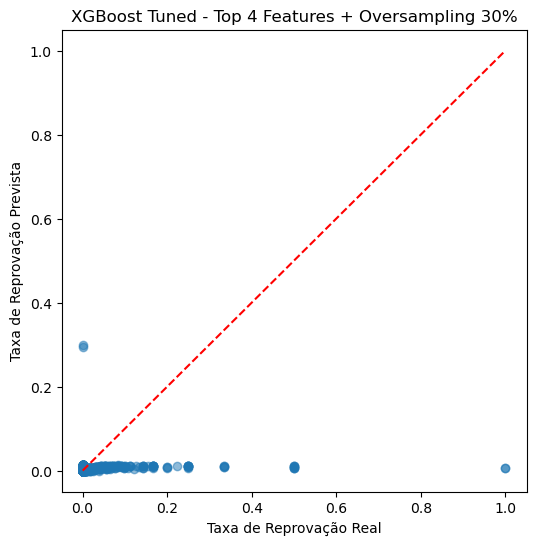

In [92]:
# XGBOOST TUNED - TOP 4 FEATURES + OVERSAMPLING 30%

from xgboost import XGBRegressor

# 1. Definir features finais

selected_features = [
    "abatidos",
    "data",
    "preco_kg",
    "cabecas_normais"
]


# 2. Aplicar oversampling apenas ao treino

X_train_over, y_train_over = smooth_oversample_regression(
    X_train[selected_features],
    y_train,
    positive_threshold=0,
    target_positive_ratio=0.3,
    noise_std=0.01,
    random_state=42
)


# 3. Definir dados de treino e teste

X_train_sel = X_train_over.copy()
X_test_sel = X_test[selected_features].copy()

y_train_aligned = y_train_over.copy()
y_test_aligned = y_test.copy()


# 4. Definir tipos de colunas

numeric_cols = X_train_sel.select_dtypes(
    include=["int64", "float64", "int32", "float32"]
).columns.tolist()

onehot_cols = X_train_sel.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()


# 5. Pipelines

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

onehot_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", drop="first"))
])


# 6. Preprocessor

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_cols),
    ("oh", onehot_pipeline, onehot_cols)
])


# 7. Pipeline final com XGBoost Tuned

model_xgb_tuned_over = Pipeline([
    ("prep", preprocessor),
    ("model", XGBRegressor(
        subsample=0.8,
        reg_lambda=5,
        reg_alpha=0.1,
        n_estimators=300,
        min_child_weight=10,
        max_depth=2,
        learning_rate=0.03,
        gamma=0,
        colsample_bytree=0.6,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    ))
])


# 8. Treinar modelo

model_xgb_tuned_over.fit(
    X_train_sel,
    y_train_aligned
)


# 9. Previsões

y_pred_xgb_tuned_over = model_xgb_tuned_over.predict(X_test_sel)

# Evitar previsões negativas
y_pred_xgb_tuned_over = np.maximum(y_pred_xgb_tuned_over, 0)


# 10. Métricas

mae = mean_absolute_error(y_test_aligned, y_pred_xgb_tuned_over)
mse = mean_squared_error(y_test_aligned, y_pred_xgb_tuned_over)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_aligned, y_pred_xgb_tuned_over)

mask_pos = y_test_aligned > 0

mae_pos = mean_absolute_error(
    y_test_aligned[mask_pos],
    y_pred_xgb_tuned_over[mask_pos]
)

rmse_pos = np.sqrt(mean_squared_error(
    y_test_aligned[mask_pos],
    y_pred_xgb_tuned_over[mask_pos]
))


# 11. Output

print("\n=== XGBoost Tuned - Top 4 Features + Oversampling 30% ===")
print(f"MAE Global        : {mae:.6f}")
print(f"MSE Global        : {mse:.6f}")
print(f"RMSE Global       : {rmse:.6f}")
print(f"R² Global         : {r2:.6f}")
print(f"MAE Taxa > 0      : {mae_pos:.6f}")
print(f"RMSE Taxa > 0     : {rmse_pos:.6f}")


# 12. Gráfico Real vs Previsto

plt.figure(figsize=(6, 6))

plt.scatter(
    y_test_aligned,
    y_pred_xgb_tuned_over,
    alpha=0.5
)

plt.plot(
    [y_test_aligned.min(), y_test_aligned.max()],
    [y_test_aligned.min(), y_test_aligned.max()],
    "r--"
)

plt.xlabel("Taxa de Reprovação Real")
plt.ylabel("Taxa de Reprovação Prevista")
plt.title("XGBoost Tuned - Top 4 Features + Oversampling 30%")

plt.show()


=== XGBoost Tuned - Top 4 Features + Oversampling 40% ===
MAE Global        : 0.008036
MSE Global        : 0.000494
RMSE Global       : 0.022231
R² Global         : -0.094705
MAE Taxa > 0      : 0.010686
RMSE Taxa > 0     : 0.050705


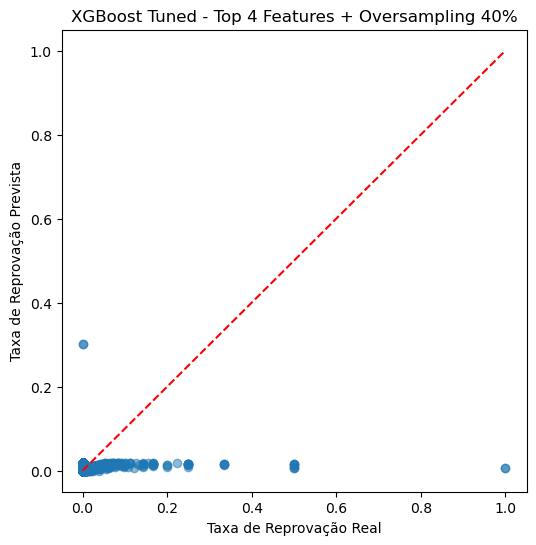

In [94]:
# XGBOOST TUNED - TOP 4 FEATURES + OVERSAMPLING 40%

from xgboost import XGBRegressor

# 1. Definir features finais

selected_features = [
    "abatidos",
    "data",
    "preco_kg",
    "cabecas_normais"
]


# 2. Aplicar oversampling apenas ao treino

X_train_over, y_train_over = smooth_oversample_regression(
    X_train[selected_features],
    y_train,
    positive_threshold=0,
    target_positive_ratio=0.4,
    noise_std=0.01,
    random_state=42
)


# 3. Definir dados de treino e teste

X_train_sel = X_train_over.copy()
X_test_sel = X_test[selected_features].copy()

y_train_aligned = y_train_over.copy()
y_test_aligned = y_test.copy()


# 4. Definir tipos de colunas

numeric_cols = X_train_sel.select_dtypes(
    include=["int64", "float64", "int32", "float32"]
).columns.tolist()

onehot_cols = X_train_sel.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()


# 5. Pipelines

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

onehot_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", drop="first"))
])


# 6. Preprocessor

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_cols),
    ("oh", onehot_pipeline, onehot_cols)
])


# 7. Pipeline final com XGBoost Tuned

model_xgb_tuned_over = Pipeline([
    ("prep", preprocessor),
    ("model", XGBRegressor(
        subsample=0.8,
        reg_lambda=5,
        reg_alpha=0.1,
        n_estimators=300,
        min_child_weight=10,
        max_depth=2,
        learning_rate=0.03,
        gamma=0,
        colsample_bytree=0.6,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    ))
])


# 8. Treinar modelo

model_xgb_tuned_over.fit(
    X_train_sel,
    y_train_aligned
)


# 9. Previsões

y_pred_xgb_tuned_over = model_xgb_tuned_over.predict(X_test_sel)

# Evitar previsões negativas
y_pred_xgb_tuned_over = np.maximum(y_pred_xgb_tuned_over, 0)


# 10. Métricas

mae = mean_absolute_error(y_test_aligned, y_pred_xgb_tuned_over)
mse = mean_squared_error(y_test_aligned, y_pred_xgb_tuned_over)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_aligned, y_pred_xgb_tuned_over)

mask_pos = y_test_aligned > 0

mae_pos = mean_absolute_error(
    y_test_aligned[mask_pos],
    y_pred_xgb_tuned_over[mask_pos]
)

rmse_pos = np.sqrt(mean_squared_error(
    y_test_aligned[mask_pos],
    y_pred_xgb_tuned_over[mask_pos]
))


# 11. Output

print("\n=== XGBoost Tuned - Top 4 Features + Oversampling 40% ===")
print(f"MAE Global        : {mae:.6f}")
print(f"MSE Global        : {mse:.6f}")
print(f"RMSE Global       : {rmse:.6f}")
print(f"R² Global         : {r2:.6f}")
print(f"MAE Taxa > 0      : {mae_pos:.6f}")
print(f"RMSE Taxa > 0     : {rmse_pos:.6f}")


# 12. Gráfico Real vs Previsto

plt.figure(figsize=(6, 6))

plt.scatter(
    y_test_aligned,
    y_pred_xgb_tuned_over,
    alpha=0.5
)

plt.plot(
    [y_test_aligned.min(), y_test_aligned.max()],
    [y_test_aligned.min(), y_test_aligned.max()],
    "r--"
)

plt.xlabel("Taxa de Reprovação Real")
plt.ylabel("Taxa de Reprovação Prevista")
plt.title("XGBoost Tuned - Top 4 Features + Oversampling 40%")

plt.show()

In [95]:
# Comparação do modelo XGBoost Tuned Top 4 Features sem oversampling vs diferentes taxas de oversampling

comparison_oversampling = pd.DataFrame({
    "Estratégia": [
        "Sem Oversampling",
        "Oversampling 20%",
        "Oversampling 30%",
        "Oversampling 40%"
    ],
    "MAE Global": [
        0.004100,
        0.004786,
        0.006117,
        0.008036
    ],
    "MSE Global": [
        0.000400,
        0.000461,
        0.000471,
        0.000494
    ],
    "RMSE Global": [
        0.021200,
        0.021481,
        0.021701,
        0.022231
    ],
    "R²": [
        -0.005100,
        -0.021360,
        -0.043128,
        -0.094705
    ],
    "MAE Taxa > 0": [
        0.012000,
        0.011438,
        0.010923,
        0.010686
    ],
    "RMSE Taxa > 0": [
        0.052000,
        0.051882,
        0.051388,
        0.050705
    ]
})

display(comparison_oversampling.round(6))

<p style="font-size:20px; line-height:1.6em; color: #333;">
Foram avaliadas diferentes taxas de oversampling (20%, 30% e 40%) aplicadas ao modelo XGBoost Tuned com Top 4 Features, com o objetivo de melhorar a representação dos casos com taxa de reprovação positiva. Os resultados demonstraram que o aumento da taxa de oversampling conduziu a melhorias progressivas nas métricas específicas dos casos positivos, nomeadamente no MAE e RMSE para taxas de reprovação superiores a zero. No entanto, esta melhoria foi acompanhada por uma degradação gradual das métricas globais, incluindo o MAE Global, RMSE Global e coeficiente de determinação (R²).
A configuração sem oversampling manteve o melhor desempenho global e o melhor valor de R², enquanto as configurações com oversampling apresentaram melhor desempenho apenas nos casos positivos. Assim, concluiu-se que o oversampling não proporcionava um melhor compromisso global entre capacidade preditiva e generalização, tendo sido mantido o modelo XGBoost Tuned com Top 4 Features sem oversampling como configuração final.


## Shap visual

X_processed_df shape: (1000, 4)
SHAP shape: (1000, 4)


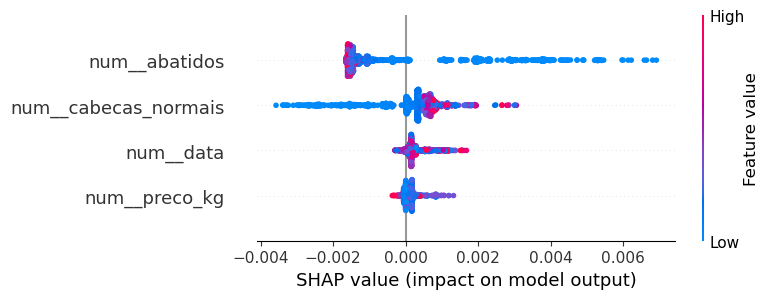

In [96]:
# SHAP - XGBOOST FINAL MODEL
# XGBoost Tuned - Top 4 Features - Sem Oversampling


# 1. Garantir que estamos a usar apenas as Top 4 Features

selected_features = [
    "abatidos",
    "data",
    "preco_kg",
    "cabecas_normais"
]

X_test_sel = X_test[selected_features].copy()


# 2. Usar uma amostra para o SHAP não ficar pesado

X_shap = X_test_sel.sample(
    n=min(1000, len(X_test_sel)),
    random_state=42
)


# 3. Aplicar o pré-processamento do pipeline final

preprocessor_fitted = best_xgb_model.named_steps["prep"]
xgb_model_fitted = best_xgb_model.named_steps["model"]

X_shap_processed = preprocessor_fitted.transform(X_shap)


# 4. Obter nomes das features após o pré-processamento

feature_names = preprocessor_fitted.get_feature_names_out()


# 5. Garantir formato DataFrame

X_shap_processed_df = pd.DataFrame(
    X_shap_processed.toarray() if hasattr(X_shap_processed, "toarray") else X_shap_processed,
    columns=feature_names
)


print("X_processed_df shape:", X_shap_processed_df.shape)


# 6. Calcular SHAP values

explainer = shap.TreeExplainer(xgb_model_fitted)
shap_values = explainer.shap_values(X_shap_processed_df)

print("SHAP shape:", shap_values.shape)


# 7. SHAP Summary Plot

shap.summary_plot(
    shap_values,
    X_shap_processed_df,
    feature_names=feature_names,
    show=True
)

<p style="font-size:20px; line-height:1.6em; color: #333;">
A análise de interpretabilidade foi realizada através da metodologia SHAP (SHapley Additive exPlanations), com o objetivo de compreender o contributo das variáveis utilizadas pelo modelo final XGBoost otimizado. Nesta fase, a interpretação incidiu sobre o modelo selecionado após o processo de feature selection e otimização de hiperparâmetros, composto pelas quatro variáveis finais: número de animais abatidos, data, preço por quilograma e número de cabeças normais.
<p style="font-size:20px; line-height:1.6em; color: #333;">
Os resultados demonstram que a variável abatidos apresenta o maior impacto nas previsões da taxa de reprovação, evidenciando a importância da dimensão da atividade de abate na explicação dos resultados gerados pelo modelo. Em seguida, destaca-se a variável cabecas_normais, associada à dimensão da exploração, que também assume relevância na explicação das previsões. As variáveis data e preco_kg apresentaram um impacto mais reduzido, sugerindo que a componente temporal e o contexto económico contribuem para o modelo, embora com menor influência relativa face às variáveis associadas ao volume de abate e à dimensão produtiva.
